# **SUPERMARKET CUSTOMERS DATA DICTIONARY**
### **Oleh: Edward Hutapea**

### Overview :
Loyalitas pelanggan terhadap produk supermarket merupakan persoalan yang dihadapi supermarket dari waktu ke waktu. Dataset menunjukkan Churn Rate (dari keseluruhan pelanggan) sebesar 68%. Jika masalah ini tidak diselesaikan sekarang, laba supermarket bisa stagnan atau menurun. Kondisi ini diperburuk dengan kehadiran kompetitor beserta variasi produk yang ditawarkan, sehingga pelanggan memiliki banyak opsi untuk mendapatkan produk yang dibutuhkan.

### Business Problem :
1. Strategi marketing kurang tepat sasaran dan kurang atraktif.  
2. Prediksi nilai transaksi pelanggan kurang akurat

### Goals :

1. Menemukan “Most Valuable Customers”  yang bisa signifikan meningkatkan omset penjualan supermarket berdasarkan analisa data historis pelanggan. Berdasarkan return of investment, mengeluarkan uang untuk mengejar mereka jauh lebih efektif dibandingkan mengejar pelanggan lainnya. Jika jumlah "Most Valuable Customers" bisa bertambah, maka omset penjualan bisa melonjak signifikan. 
2. Memberikan rekomendasi ”Personalized Promotion" yang bisa digunakan supermarket kepada “Most Valuable Customers” sehingga strategi marketing bisa lebih kontekstual.
3. Membangun model machine learning yang membantu supermarket memprediksi total transaksi pelanggan seakurat mungkin sehingga penentuan target penjualan menjadi lebih realistis. Target penjualan perlu diprediksi sedari awal untuk menjadi referensi dalam menghitung budget promo yang reasonable sesuai target laba. 

Kombinasi Most Valuable Customers, Personalized Promotion dan model machine learing membuat kegiatan promosi bisa lebih optimal, dan berujung pada penurunan churn rate dan peningkatan laba supermarket.

### Analytic Approach :

- Melakukan analisa data historis pelanggan supermarket dalam menjawab business question di bawah ini:

1. Berapa churn rate dari keseluruhan pelanggan?
2. Bagaimana analisa transaksi pelanggan berdasarkan generasi pelanggan?
3. Bagaimana analisa transaksi pelanggan berdasarkan usia pelanggan?
4. Bagaimana analisa transaksi pelanggan berdasarkan status pernikahan pelanggan?
5. Bagaimana analisa transaksi pelanggan berdasarkan pendidikan pelanggan?
6. Bagaimana analisa transaksi pelanggan berdasarkan income pelanggan selama 2 tahun?
7. Siapa "Most Valuable Customers" yang memiliki dampak finansial terbesar terhadap omset penjualan supermarket?
8. Berapa churn rate dari "Most Valuable Customers"?
9. Bagaimana Spending/Income Rate (Rasio Pengeluaran terhadap Pendapatan) dari "Most Valuable Customers"?
10. Untuk mengoptimalkan marketing kepada "Most Valuable Customers", siapa segmen pelanggan yang menjadi prioritas tertinggi dan proritas terendah dalam kampanye marketing?
11. Bagaimana efektifitas discount terhadap "Most Valuable Customers" selama ini?
12. Bagaimana respon "Most Valuable Customers" terhadap kampanye promosi selama ini?
13. Apa produk yang diminati "Most Valuable Customers" selama ini?
14. Bagaimana cara "Most Valuable Customers" melakukan transaksi selama ini?
15. Berapa potensi tambahan nilai transaksi dari "Most Valuable Customers" dalam 2 tahun ke depan?

- Selanjutnya buat model regresi sebagai 'tool' prediksi total transaksi pelanggan, sehingga churn rate bisa menurun dan laba supermarket bisa meningkat.

### Contents :

1. Import Package
2. Import Data
3. Data Wrangling

*Analisa Data Historis Pelanggan Supermarket:*

4. Data Conversion (Untuk Improvement Data)
5. Cross Features
6. Analisa Data dan Insight untuk setiap Business Questions
7. Actionable Recommendation Berdasarkan Analisa Data Historis Supermarket

*Machine Learning Modelling:*

8. Feature Engineering (Data Conversion) untuk Machine Learning
9. Feature selection
10. Analisa Korelasi
11. Analisa Intercept dan Koefisien
12. Cross Validation
13. Machine Learning menggunakan Benchmark Model
14. Improvement Machine Learning
15. Implementasi Model Terbaik (Tuning Random Forest Regressor) Terhadap Prediksi Total Transaksi Pelanggan 
16. Feature Importances
17. Kesimpulan Machine Learning dan Rekomendasi

### Audience :
Board of Director (sebagai pengambilan keputusan bisnis)

## 1. Import Package

In [275]:
!pip install dateparser


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [276]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import missingno

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from scipy import stats
from scipy.stats import pointbiserialr

import warnings
warnings.filterwarnings('ignore')

import dateparser

# Set max columns
pd.set_option('display.max_columns', None)

## 2. Import Data

In [277]:
df = pd.read_csv('Supermarket Customers.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,4/9/2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,8/3/2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21/8/2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10/2/2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19/1/2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


- Untuk step selanjutnya, kita hanya menampilkan kolom yang dibutuhkan dalam analisa saja. Kolom yang tidak digunakan dalam analisa, akan kita drop.
- Berikut ini adalah kolom yang dibutuhkan dalam analisa:
 

**People**
- ID: ID masing-masing pelanggan
- Year_Birth: Tahun kelahiran pelanggan
- Education: Latar pendidikan pelanggan
- Marital_Status : Status pernikahan pelanggan
- Income: Pendapatan tahunan pelanggan
- Dt_Customer: Tanggal registrasi pelanggan
- Recency: Jumlah hari setelah transaksi terakhir yang dilakukan pelanggan

**Products**
- MntWines: Nilai transaksi pembelian produk WINE dalam 2 tahun terakhir
- MntFruits: Nilai transaksi pembelian produk FRUITS dalam 2 tahun terakhir
- MntMeatProducts: Nilai transaksi pembelian produk MEAT dalam 2 tahun terakhir
- MntFishProducts: Nilai transaksi pembelian produk FISH dalam 2 tahun terakhir
- MntSweetProducts: Nilai transaksi pembelian produk SWEET dalam 2 tahun terakhir
- MntGoldProds: Nilai transaksi pembelian produk GOLD dalam 2 tahun terakhir

**Place**
- NumWebPurchases: Jumlah transaksi online melalui webiste supermarket
- NumCatalogPurchases: Jumlah transaksi menggunakan katalog
- NumStorePurchases: Jumlah transaksi offline langsung di supermarket

**Promotion**
- NumDealsPurchases: Jumlah transaksi yang dibuat dengan harga diskon
- AcceptedCmp1: 1 jika pelanggan menerima promosi di kampanye ke-1, 0 jika tidak menerima.
- AcceptedCmp2: 1 jika pelanggan menerima promosi di kampanye ke-2, 0 jika tidak menerima.
- AcceptedCmp3: 1 jika pelanggan menerima promosi di kampanye ke-3, 0 jika tidak menerima.
- AcceptedCmp4: 1 jika pelanggan menerima promosi di kampanye ke-4, 0 jika tidak menerima.
- AcceptedCmp5: 1 jika pelanggan menerima promosi di kampanye ke-5, 0 jika tidak menerima.
- Response: 1 jika pelanggan menerima promosi di kampanye terakhir, 0 jika tidak menerima.

In [278]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [279]:
df = df[['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Dt_Customer', 'Recency',
        'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
        'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
        'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']]

In [280]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
0,5524,1957,Graduation,Single,58138.0,4/9/2012,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,8/3/2014,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,21/8/2013,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,10/2/2014,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,19/1/2014,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0


Membuat Index dari Kolom Primary Key (yaitu kolom ID)

In [281]:
df = df.set_index('ID')
df.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
ID,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,4/9/2012,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1
2174,1954,Graduation,Single,46344.0,8/3/2014,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0
4141,1965,Graduation,Together,71613.0,21/8/2013,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0
6182,1984,Graduation,Together,26646.0,10/2/2014,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0
5324,1981,PhD,Married,58293.0,19/1/2014,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0


In [282]:
df.columns

Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Dt_Customer',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'Response'],
      dtype='object')

## 3. Data Wrangling

### 3.1. Pengecekan Tipe Data

In [283]:
df.dtypes

Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
AcceptedCmp1             int64
AcceptedCmp2             int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
Response                 int64
dtype: object

In [284]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Dt_Customer          2240 non-null   object 
 5   Recency              2240 non-null   int64  
 6   MntWines             2240 non-null   int64  
 7   MntFruits            2240 non-null   int64  
 8   MntMeatProducts      2240 non-null   int64  
 9   MntFishProducts      2240 non-null   int64  
 10  MntSweetProducts     2240 non-null   int64  
 11  MntGoldProds         2240 non-null   int64  
 12  NumDealsPurchases    2240 non-null   int64  
 13  NumWebPurchases      2240 non-null   int64  
 14  NumCatalogPurchases  2240 non-null   int64  
 15  NumStorePurchases    2240 non-null   int

### 3.2. Pengecekan Anomali Data

#### 3.2.1. Pengecekan Missing Value

In [285]:
print(f"\nJumlah total data (missing values) di dalam DataFrame = {df.isnull().sum().sum()}")

dataDesc = []
for i in df.columns:
    dataDesc.append([
        i,
        df[i].dtypes,
        df[i].isna().sum(),
        round(df[i].isna().sum() / len(df) * 100, 2)
    ])

pd.DataFrame(dataDesc, columns=[
    "Data Features",
    "Data Types",
    "Null Val",
    "Null Percentage"
])


Jumlah total data (missing values) di dalam DataFrame = 24


,Data Features,Data Types,Null Val,Null Percentage
0,Year_Birth,int64,0,0.00
1,Education,object,0,0.00
2,Marital_Status,object,0,0.00
3,Income,float64,24,1.07
4,Dt_Customer,object,0,0.00
5,Recency,int64,0,0.00
6,MntWines,int64,0,0.00
7,MntFruits,int64,0,0.00
8,MntMeatProducts,int64,0,0.00
9,MntFishProducts,int64,0,0.00


Bar Plot

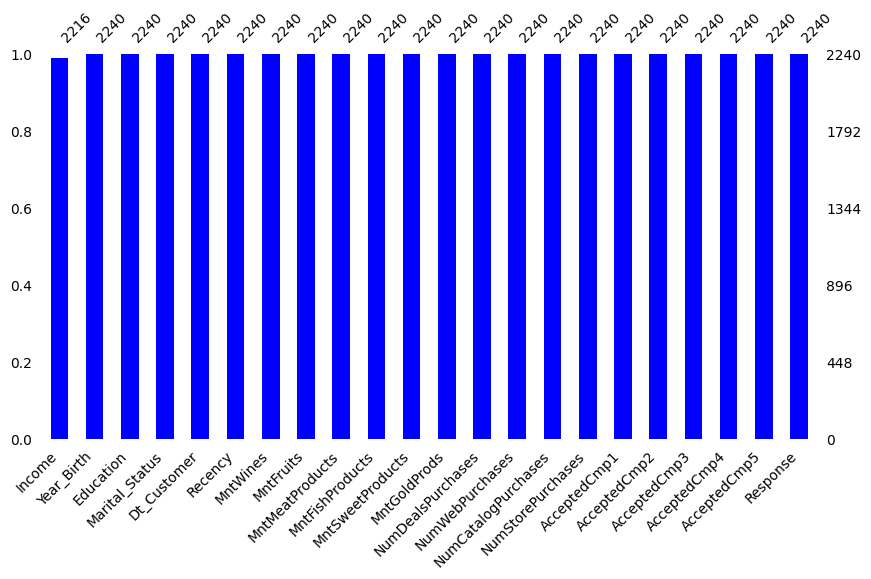

In [286]:
missingno.bar(df,color="blue", sort="ascending", figsize=(10,5), fontsize=10);

Matrix Plot

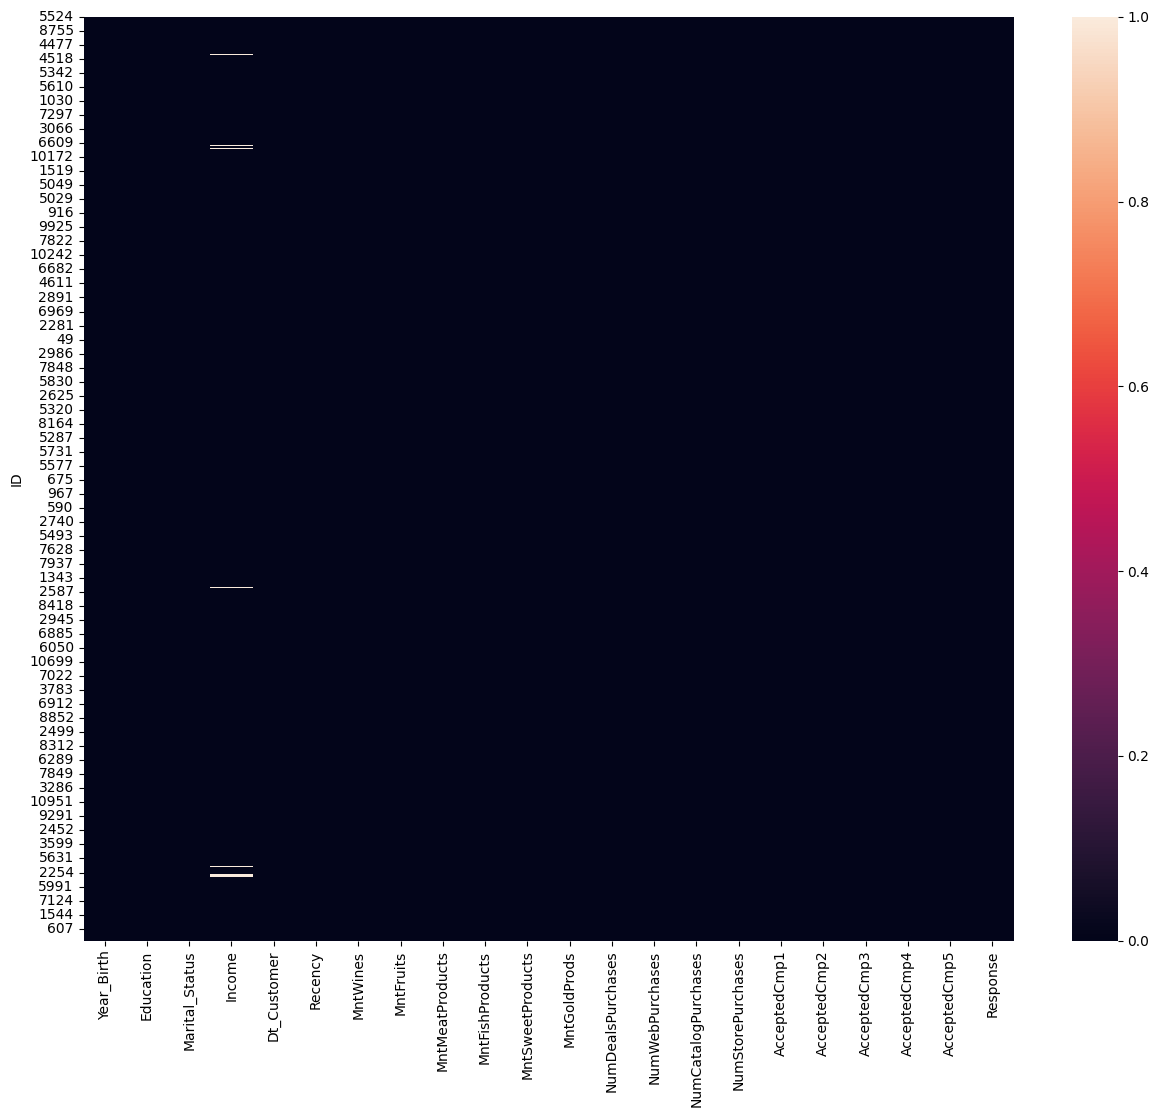

In [287]:
plt.figure(figsize=(15,12))
sns.heatmap(df.isnull())
plt.show()

**Hasil Pengecekan Missing Value :**
- Dari tabel di atas, hanya kolom income yang memiliki missing value, dengan persentase missing value sebesar 1.07%. Nilai persentase ini termasuk kecil (<3%) sehingga baris dengan missing value di kolom income bisa dihapus (drop).
- Step selanjutnya ==> Drop baris dengan missing value di kolom income

In [288]:
df.dropna(inplace=True) 

In [289]:
df.shape

(2216, 22)

In [290]:
df.isnull().sum()

Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
AcceptedCmp1           0
AcceptedCmp2           0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
Response               0
dtype: int64

**Penghapusan Missing Value sudah dilakukan. Sekarang tidak ada lagi Missing Value**

#### 3.2.2. Pengecekan Data Duplikat

In [291]:
print(df.duplicated().sum())

182


In [292]:
df[df.duplicated()]

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
ID,,,,,,,,,,,,,,,,,,,,,,
4119,1963,Master,Together,38620.0,11/5/2013,56,112,17,44,34,22,89,1,2,5,3,0,0,0,0,0,0
6935,1951,2n Cycle,Married,78497.0,1/12/2013,44,207,26,447,75,0,223,1,5,7,12,1,0,0,0,0,0
10144,1976,Graduation,Together,51369.0,25/10/2012,84,297,7,79,0,11,182,2,8,2,4,0,0,0,0,0,0
8652,1946,Graduation,Together,37760.0,31/8/2012,20,84,5,38,150,12,28,2,4,1,6,0,0,0,0,0,0
933,1978,PhD,Married,37717.0,23/11/2012,31,9,0,6,4,1,5,1,1,0,2,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4838,1978,Graduation,Together,22775.0,19/6/2013,40,5,1,8,0,0,1,1,1,0,2,0,0,0,0,0,0
7366,1982,Master,Single,75777.0,4/7/2013,12,712,26,538,69,13,80,1,3,6,11,0,0,0,1,1,1
4749,1968,Graduation,Together,58554.0,26/9/2012,55,368,24,68,38,0,88,6,8,2,6,0,0,0,0,0,0


**Hasil Pengecekan Data Duplikat :**
- Terdapat 186 baris yang memiliki data duplikat. Tabel di bawah ini menunjukkan data yang duplikat.
- Step selanjutnya ==> Menghapus semua data duplikat.

In [293]:
df.drop_duplicates(inplace=True) 

In [294]:
df.shape

(2034, 22)

In [295]:
print(df.duplicated().sum())

0


**Penghapusan Data Duplikat sudah dilakukan. Sekarang tidak ada lagi Data Duplikat**

#### 3.2.3. Pengecekan Outliers

In [296]:
df.dtypes

Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
AcceptedCmp1             int64
AcceptedCmp2             int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
Response                 int64
dtype: object

In [297]:
def Cek_Outliers(df, col):
    Q1 = df[col].describe()['25%']
    Q3 = df[col].describe()['75%']
    IQR = Q3 - Q1
    Upper_Fence = Q3 + (1.5 * IQR)
    Lower_Fence = Q1 - (1.5 * IQR)
    df_outliers = df[(df[col] < Lower_Fence) | (df[col] > Upper_Fence)]
    if len(df_outliers) == 0:
        return "No Outliers"
    else:
        return df_outliers

data_outliers = []
for col in df.columns:
    if df[col].dtypes != 'O':
        data_outliers.append([
            col,
            df[col].dtypes,
            len(Cek_Outliers(df, col)),
            round(len(Cek_Outliers(df, col)) / len(df) * 100, 2)
        ])

pd.DataFrame(data_outliers, columns=[
    "Data Features",
    "Data Types",
    "Outliers Val",
    "Outliers Percentage"
])

,Data Features,Data Types,Outliers Val,Outliers Percentage
0,Year_Birth,int64,3,0.15
1,Income,float64,8,0.39
2,Recency,int64,11,0.54
3,MntWines,int64,33,1.62
4,MntFruits,int64,222,10.91
5,MntMeatProducts,int64,172,8.46
6,MntFishProducts,int64,202,9.93
7,MntSweetProducts,int64,223,10.96
8,MntGoldProds,int64,185,9.10
9,NumDealsPurchases,int64,76,3.74


**Hasil Pengecekan Outliers :**
- Terdapat beberapa kolom yang memiliki outliers, tapi fokus kita kepada kolom-kolom yang berkaitan dengan analisa data.
- Untuk kolom AcceptedCmp1, AcceptedCmp2, AcceptedCmp3, AcceptedCmp4, AcceptedCmp5 dan Response ==> Hanya memiliki 2 data unik yaitu 0 dan 1, sehingga data outliers bisa diabaikan.	
- Step selanjutnya ==> Melakukan DROP outliers terhadap beberapa kolom dengan persentase outliers yang kecil (<3%) untuk menjaga kualitas data.

**DROP Outliers :**
- Jumlah maximum dari keseluruhan data outliers yang di DROP yaitu 3% dari keseluruhan dataset, supaya dataset tidak habis. Jumlah dataset (sebelum DROP outliers) = 2030 baris. Jumlah minimum dataset (sesudah DROP Outliers, maximum 3% data) = 1970 baris. 
- Drop outliers dilakukan pada kolom-kolom yang menjadi analisa.
- Proses Drop outliers dilakukan mulai dari persentase paling kecil yaitu:
    - Prioritas ke 1 : Data Kolom Year_Birth (0.15%),
    - Prioritas ke 2 : Data Kolom NumWebPurchases (0.15%),
    - Prioritas ke 3 : Data Kolom NumCatalogPurchases (1.08%),
    - Prioritas ke 4 : Data Kolom MntWines (1.58%).
- Scatter Plot di bawah ini memperlihatkan keberadaan data outliers di ke-4 kolom di atas    

In [298]:
## Menghitung jumlah minimum dataset (sesudah DROP Outliers) : 

(100 - 3) * len(df) / 100

1972.98

3.2.3.A. Berikut ini adalah **Scatter Plot** yang memperlihatkan keberadaan data outliers di kolom **Year_Birth**

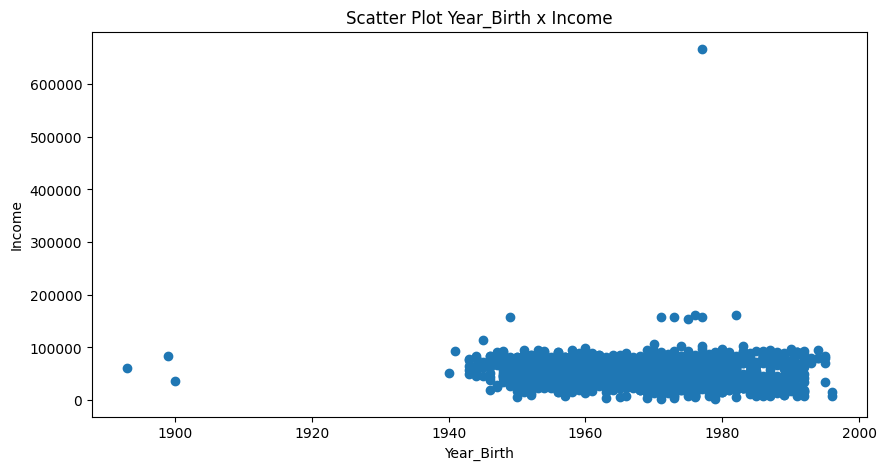

In [299]:
plt.figure(figsize=(10,5))
plt.scatter(df['Year_Birth'], df['Income'])
plt.title('Scatter Plot Year_Birth x Income')
plt.xlabel('Year_Birth')
plt.ylabel('Income')
plt.show()

3.2.3.B. Berikut ini adalah **Scatter Plot** yang memperlihatkan keberadaan data outliers di kolom **NumWebPurchases**

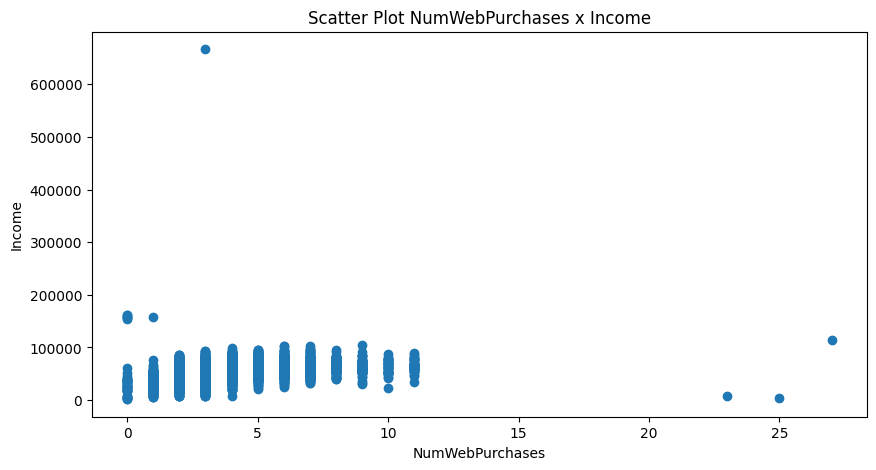

In [300]:
plt.figure(figsize=(10,5))
plt.scatter(df['NumWebPurchases'], df['Income'])
plt.title('Scatter Plot NumWebPurchases x Income')
plt.xlabel('NumWebPurchases')
plt.ylabel('Income')
plt.show()

3.2.3.C. Berikut ini adalah **Scatter Plot** yang memperlihatkan keberadaan data outliers di kolom **NumCatalogPurchases**

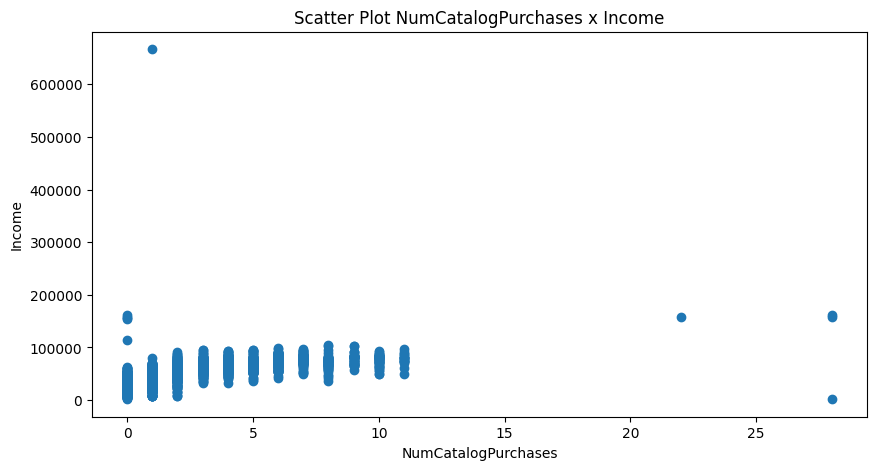

In [301]:
plt.figure(figsize=(10,5))
plt.scatter(df['NumCatalogPurchases'], df['Income'])
plt.title('Scatter Plot NumCatalogPurchases x Income')
plt.xlabel('NumCatalogPurchases')
plt.ylabel('Income')
plt.show()

3.2.3.D. Berikut ini adalah **Scatter Plot** yang memperlihatkan keberadaan data outliers di kolom **MntWines**

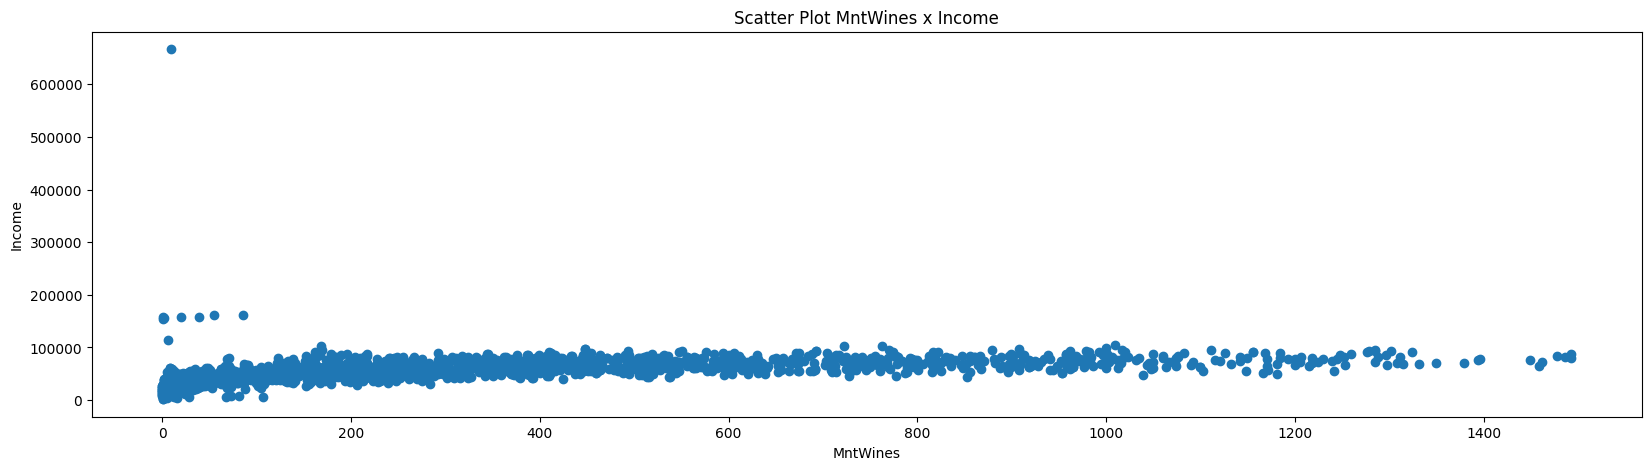

In [302]:
plt.figure(figsize=(20,5))
plt.scatter(df['MntWines'], df['Income'])
plt.title('Scatter Plot MntWines x Income')
plt.xlabel('MntWines')
plt.ylabel('Income')
plt.show()

3.2.3.E. **Scatter Plot** di atas memperlihatkan juga keberadaan data outliers di kolom **Income**

Melakukan DROP outliers di kolom Year_Birth, NumWebPurchases, NumCatalogPurchases, MntWines dan Income:

In [303]:
df = df[~df['Year_Birth'].isin(Cek_Outliers(df, 'Year_Birth')['Year_Birth'])] ## data Kolom Year_Birth yang bukan outliers.
df = df[~df['NumWebPurchases'].isin(Cek_Outliers(df, 'NumWebPurchases')['NumWebPurchases'])] ## data Kolom NumWebPurchases yang bukan outliers.
df = df[~df['NumCatalogPurchases'].isin(Cek_Outliers(df, 'NumCatalogPurchases')['NumCatalogPurchases'])] ## data Kolom NumCatalogPurchases yang bukan outliers.
df = df[~df['MntWines'].isin(Cek_Outliers(df, 'MntWines')['MntWines'])] ## data Kolom MntWines yang bukan outliers.
df = df[~df['Income'].isin(Cek_Outliers(df, 'Income')['Income'])] ## data Kolom Income yang bukan outliers.
df.shape

(1968, 22)

**Proses DROP Outliers di kolom Year_Birth, NumWebPurchases, NumCatalogPurchases, MntWines dan Income sudah dilakukan**

#### Pengecekan Hasil setelah DROP Outliers 

In [304]:
data_outliers = []
for col in df.columns:
    if df[col].dtypes != 'O':
        data_outliers.append([
            col,
            df[col].dtypes,
            len(Cek_Outliers(df, col)),
            round(len(Cek_Outliers(df, col)) / len(df) * 100, 2)
        ])

pd.DataFrame(data_outliers, columns=[
    "Data Features",
    "Data Types",
    "Outliers Val",
    "Outliers Percentage"
])

,Data Features,Data Types,Outliers Val,Outliers Percentage
0,Year_Birth,int64,11,0.56
1,Income,float64,11,0.56
2,Recency,int64,11,0.56
3,MntWines,int64,12,0.61
4,MntFruits,int64,213,10.82
5,MntMeatProducts,int64,177,8.99
6,MntFishProducts,int64,210,10.67
7,MntSweetProducts,int64,224,11.38
8,MntGoldProds,int64,181,9.20
9,NumDealsPurchases,int64,72,3.66


### 3.3. Pengecekan Kolom Bertipe Tanggal

In [305]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
ID,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,4/9/2012,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1
2174,1954,Graduation,Single,46344.0,8/3/2014,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0
4141,1965,Graduation,Together,71613.0,21/8/2013,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0
6182,1984,Graduation,Together,26646.0,10/2/2014,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0
5324,1981,PhD,Married,58293.0,19/1/2014,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0


In [306]:
df.dtypes

Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
AcceptedCmp1             int64
AcceptedCmp2             int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
Response                 int64
dtype: object

**Kolom bertipe tanggal yaitu Kolom Dt_Customer masih bertipe object, sehingga perlu dikonversi menjadi tipe datetime64[ns]**

#### Konversi Kolom Bertipe Tanggal

In [307]:
df['Dt_Customer'] = df['Dt_Customer'].apply(dateparser.parse)
df.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
ID,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0


In [308]:
df.dtypes

Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
Response                        int64
dtype: object

### 3.4. Deskriptif Data Statistik untuk data numerik dan object

In [309]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Year_Birth,1968.0,NaN,NaN,NaN,1969.027439,1940.0,1960.0,1970.0,1977.0,1996.0,11.597523
Education,1968,5,Graduation,992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,1968,8,Married,763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,1968.0,NaN,NaN,NaN,51026.23628,1730.0,34939.5,50640.0,66977.5,105471.0,20346.461599
Dt_Customer,1968,NaN,NaN,NaN,2013-07-13 11:14:38.048780544,2012-01-08 00:00:00,2013-01-20 00:00:00,2013-07-14 00:00:00,2014-01-03 00:00:00,2014-12-06 00:00:00,NaN
Recency,1968.0,NaN,NaN,NaN,48.825203,0.0,24.0,49.0,74.0,99.0,28.950511
MntWines,1968.0,NaN,NaN,NaN,286.662093,0.0,23.0,169.5,483.0,1218.0,311.354863
MntFruits,1968.0,NaN,NaN,NaN,25.930386,0.0,2.0,8.0,32.0,199.0,39.398744
MntMeatProducts,1968.0,NaN,NaN,NaN,158.594512,0.0,16.0,64.0,215.0,984.0,212.52007
MntFishProducts,1968.0,NaN,NaN,NaN,37.188008,0.0,3.0,12.0,49.0,259.0,54.964935


### 3.5. Data Summary ==> Setelah Drop Missing Value, Hapus Duplicate Data, Drop Outliers dan Konversi Kolom Bertipe Tanggal

In [310]:
df.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
ID,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0


#### 3.5.1. Tipe Data, Missing Value dan Data Unik

In [311]:
df['Income'].unique()[:10]

array([58138., 46344., 71613., 26646., 58293., 62513., 55635., 33454.,
       30351.,  5648.])

In [312]:
dataDesc = []
for i in df.columns:
    dataDesc.append([
        i,
        df[i].dtypes,
        df[i].isna().sum(),
        round(df[i].isna().sum() / len(df) * 100, 2),
        df[i].nunique(),
        df[i].drop_duplicates().sample(1).values
    ])

pd.DataFrame(dataDesc, columns=[
    "Data Features",
    "Data Types",
    "Null Val",
    "Null Percentage",
    "Jumlah Unique",
    "Unique Sample"
])

,Data Features,Data Types,Null Val,Null Percentage,Jumlah Unique,Unique Sample
0,Year_Birth,int64,0,0.0,55,[1964]
1,Education,object,0,0.0,5,[Graduation]
2,Marital_Status,object,0,0.0,8,[Widow]
3,Income,float64,0,0.0,1908,[78499.0]
4,Dt_Customer,datetime64[ns],0,0.0,659,[2013-09-18T00:00:00.000000000]
5,Recency,int64,0,0.0,100,[86]
6,MntWines,int64,0,0.0,740,[17]
7,MntFruits,int64,0,0.0,158,[92]
8,MntMeatProducts,int64,0,0.0,529,[408]
9,MntFishProducts,int64,0,0.0,179,[82]


#### 3.5.2. Data Outliers

In [313]:
data_outliers = []
for col in df.columns:
    if df[col].dtypes != 'O':
        data_outliers.append([
            col,
            df[col].dtypes,
            len(Cek_Outliers(df, col)),
            round(len(Cek_Outliers(df, col)) / len(df) * 100, 2)
        ])

pd.DataFrame(data_outliers, columns=[
    "Data Features",
    "Data Types",
    "Outliers Val",
    "Outliers Percentage"
])

,Data Features,Data Types,Outliers Val,Outliers Percentage
0,Year_Birth,int64,11,0.56
1,Income,float64,11,0.56
2,Dt_Customer,datetime64[ns],11,0.56
3,Recency,int64,11,0.56
4,MntWines,int64,12,0.61
5,MntFruits,int64,213,10.82
6,MntMeatProducts,int64,177,8.99
7,MntFishProducts,int64,210,10.67
8,MntSweetProducts,int64,224,11.38
9,MntGoldProds,int64,181,9.20


**Kita keep data outliers, maka untuk analisa kita menggunakan median (bukan mean)**

# **========== Analisa Data Historis Pelanggan Supermarket ==========**

## 4. Data Conversion (Untuk Improvement Data)

### 4.1 Binning

📌**A. Kategori Generasi Pelanggan**

 Data Year_Birth (Kolom Numerikal) dirubah menjadi data kelompok generasi (Kolom Kategorikal) berdasarkan tahun kelahiran pelanggan (sumber: [Pew Research Center](https://www.pewresearch.org/short-reads/2019/01/17/where-millennials-end-and-generation-z-begins/ft_19-01-17_generations_2019-png/)) seperti di bawah ini:

| Generasi         | Tahun Lahir   | Usia di 2015^     |
|-----------------|--------------|------------------|
| Silent         | 1928 - 1945   | 70 - 87 tahun   |
| Baby Boomer    | 1946 - 1964   | 51 - 69 tahun   |
| Gen X          | 1965 - 1980   | 35 - 50 tahun   |
| Milenial       | 1981 - 1996   | 19 - 34 tahun   |
| Gen Z          | 1997 - 2012   | 3 - 18 tahun   |

^ Dataset tidak menunjukkan kapan terjadinya transaksi. Tapi Kolom 'Dt_Customer' menunjukkan enrolment pelanggan mulai 8-Januari-2012 s/d 6-Desember-2014. Tahun 2015 adalah tahun terdekat dengan enrolment pelanggan terakhir. Untuk analisa data, kita gunakan tahun 2015 sebagai dasar penentuan usia pelanggan. Maka dalam analisa, usia pelanggan dihitung pada tahun 2015.

In [314]:
# Binning tahun kelahiran ke dalam kategori generasi
bins = [1927, 1945, 1964, 1980, 1996, 2012]  # Rentang tahun kelahiran sesuai kategori generasi
labels = ["Silent", "Baby Boomer", "Gen X", "Milenial", "Gen Z"]

df['Generation'] = pd.cut(df['Year_Birth'], bins=bins, labels=labels)
df['Age'] = 2015 - df['Year_Birth']

# Menampilkan hasil
df.head(5)

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age
ID,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0,Milenial,31
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0,Milenial,34


*Distribusi usia berdasarkan Generasi:*

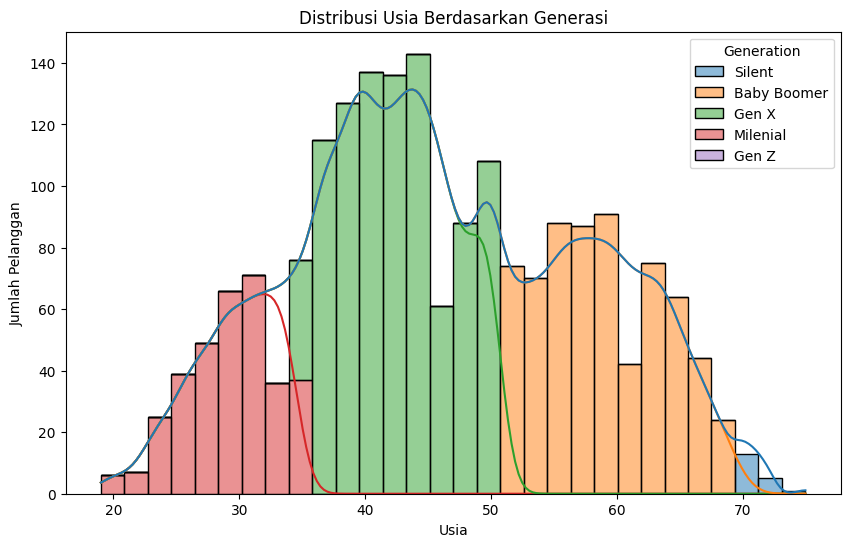

In [315]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Age", hue="Generation", kde=True, multiple="stack", bins=30)
plt.title('Distribusi Usia Berdasarkan Generasi')
plt.xlabel('Usia')
plt.ylabel('Jumlah Pelanggan')
plt.show()

📌**B. Kategori Usia Pelanggan**

Data Year_Birth (Kolom Numerikal) dirubah menjadi data kelompok usia (Kolom Kategorikal) berdasarkan usia pelanggan di tahun 2015.

Pelanggan dikelompokkan berdasarkan rentang usia kerja (sumber: [Kementerian Kesehatan Indonesia](https://ayosehat.kemkes.go.id/kategori-usia)) seperti di bawah ini. Menurut CIA, struktur kelompok usia kerja mempengaruhi sosial-ekonomi sebuah negara. 

| Kategori     | Rentang Usia      |
|-------------|-----------|
| Balita   | 0-4 tahun  |
| Anak-anak  | 5-9 tahun  |
| Remaja | 10-17 tahun  |
| Dewasa  | 18-59 tahun  |
| Lansia  | 60 tahun ke atas  |

In [316]:
# df['Age'] = 2015 - df['Year_Birth']

def Rentang_Usia(x):
    if x <= 4:
        return "Balita"
    if 4 < x <= 9:
        return "Anak-anak"
    if 9 < x <= 17:
        return "Remaja"
    if 17 < x <= 59:
        return "Dewasa"
    else:
        return "Lansia"

df['Age_Category'] = df['Age'].apply(Rentang_Usia)
df.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category
ID,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58,Dewasa
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61,Lansia
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0,Milenial,31,Dewasa
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0,Milenial,34,Dewasa


*Distribusi usia berdasarkan Kelompok Usia:*

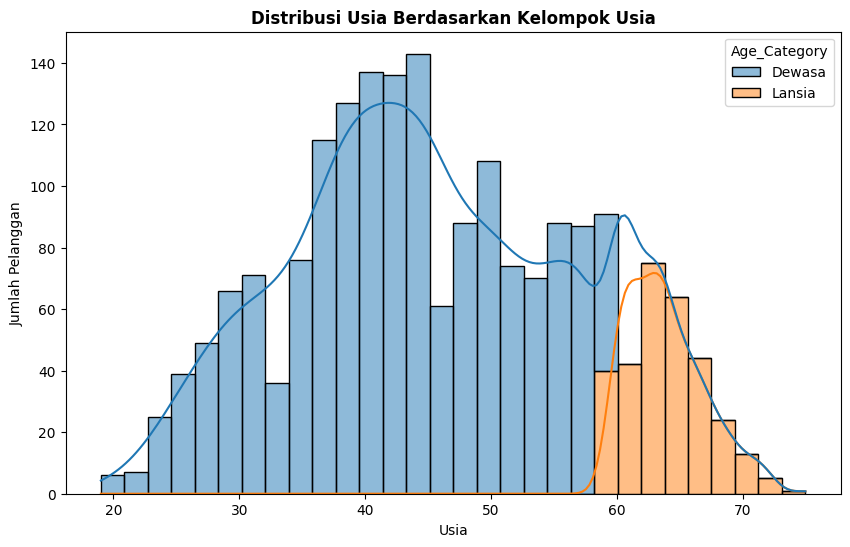

In [317]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Age", hue="Age_Category", kde=True, multiple="stack", bins=30)
plt.title('Distribusi Usia Berdasarkan Kelompok Usia', fontweight='bold')
plt.xlabel('Usia')
plt.ylabel('Jumlah Pelanggan')
plt.show()

📌**C. Kelompok Income Pelanggan**

Dataset menunjukkan jumlah transaksi dan nilai transaksi pelanggan selama 2 tahun. Namun, dataset hanya menampilkan income tahunan pelanggan. Untuk analisa data, kita mengubah income tahunan menjadi income selama 2 tahun (yaitu kolom 'Income 2 tahun'). Selanjutnya data income (Kolom Numerikal) dirubah menjadi data kelompok income pelanggan (Kolom Kategorikal) berdasarkan total income selama 2 tahun. Total income dibagi dengan kelipatan 20K.

| No. | Kelompok Income Selama 2 tahun |
|-------|------------------|
| 1 | <20k	 |
| 2 | 20k-40k |
| 3 | 40k-60k |
| 4 | 60k-80k |
| 5 | 80k-100k |
| 6 | 100k-120k |
| 7 | 120k-140k |
| 8 | 140k-160k |
| 9 | 160k-180k |
| 10 | 180k-200k |
| 11 | >200k |

In [318]:
# Kolom 'Income 2 tahun' = income pelanggan dalam 2 tahun. 

df['Income 2 tahun'] = df['Income'] * 2

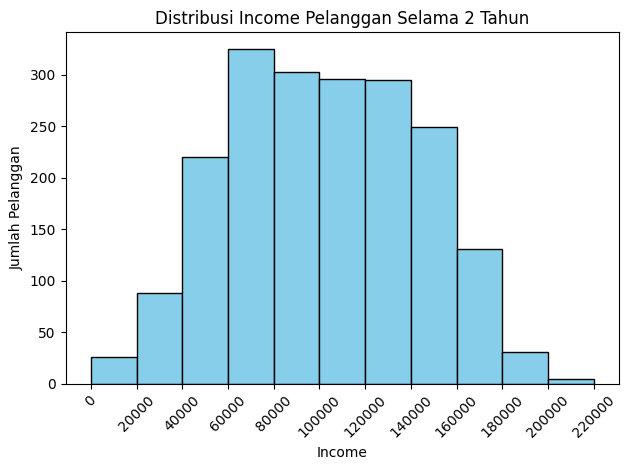

In [319]:
# Max income 2 tahun < 220K. Tampilkan distribusi dalam kelipatan 20K

# Buat interval bins = kelipatan 20K
bins_interval = np.arange(0, 240000, 20000)

# Buat interval sumbu x = kelipatan 20K
x_interval = np.arange(0, 240000, 20000)

# Plot Histogram
plt.hist(df['Income 2 tahun'], bins=bins_interval, color='skyblue', edgecolor='black')

# Terapkan ke sumbu X
plt.xticks(x_interval, rotation=45) # rotation=45 agar angka tidak saling bertumpuk

plt.title('Distribusi Income Pelanggan Selama 2 Tahun')
plt.xlabel('Income')
plt.ylabel('Jumlah Pelanggan')

plt.tight_layout() # Agar label yang miring tidak terpotong
plt.savefig('Distribusi Income Pelanggan Selama 2 Tahun.png')
plt.show()

In [320]:
def income_2_tahun_20k(x):
    if x < 20000:
        return "<20k"
    if 20000 <= x < 40000:
        return "20k-40k"
    if 40000 <= x < 60000:
        return "40k-60k"
    if 60000 <= x < 80000:
        return "60k-80k"
    if 80000 <= x < 100000:
        return "80k-100k"
    if 100000 <= x < 120000:
        return "100k-120k"
    if 120000 <= x < 140000:
        return "120k-140k"
    if 140000 <= x < 160000:
        return "140k-160k"
    if 160000 <= x < 180000:
        return "160k-180k"
    if 180000 <= x <= 200000:
        return "180k-200k"
    else:
        return ">200k"

df['Kelompok Income 2 tahun_20k'] = df['Income 2 tahun'].apply(income_2_tahun_20k)
df.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58,Dewasa,116276.0,100k-120k
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61,Lansia,92688.0,80k-100k
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0,Milenial,31,Dewasa,53292.0,40k-60k
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0,Milenial,34,Dewasa,116586.0,100k-120k


📌**D. Status Churn Pelanggan**

Kita tambahkan kolom baru yaitu 'Churn_Status' berdasarkan data kolom Recency. Kolom recency menunjukkan data "jumlah hari setelah transaksi terakhir yang dilakukan setiap pelanggan", dengan rentang 0-99 hari. Pada umumnya di bisnis supermarket, Churn dihitung ketika pelanggan tidak melakukan transaksi selama lebih dari 1 bulan (30 hari). Dengan menggunakan data recency, kita dapat menentukan status churn dari pelanggan. Kolom Recency (dalam hari) dikelompokkan sesuai kriteria churn, seperti di bawah ini:

| Recency  | Status Churn  |
|-------------|-----------------------|
| 30 hari | Non-churn (pelanggan loyal)   |
| >30 hari  | Churn (pelanggan tidak loyal) |

Kolom 'Churn_Status' = klasifikasi pelanggan antara pelanggan tidak loyal (churn) dan pelanggan loyal (non-churn)

In [321]:
def last_purchase(x):
    if x <= 30:
        return 'Non-Churn'
    else:
        return 'Churn'

df['Churn_Status'] = df['Recency'].apply(last_purchase)
df.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58,Dewasa,116276.0,100k-120k,Churn
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61,Lansia,92688.0,80k-100k,Churn
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0,Milenial,31,Dewasa,53292.0,40k-60k,Non-Churn
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0,Milenial,34,Dewasa,116586.0,100k-120k,Churn


In [322]:
print("Komposisi Pelanggan Churn dan Non-Churn yaitu:\n")
print(df['Churn_Status'].value_counts())

print(f"\nChurn Rate dari keseluruan pelanggan yaitu {round((len(df[df['Churn_Status'] == 'Churn'])/len(df) * 100), 2)}%.")

Komposisi Pelanggan Churn dan Non-Churn yaitu:

Churn_Status
Churn        1330
Non-Churn     638
Name: count, dtype: int64

Churn Rate dari keseluruan pelanggan yaitu 67.58%.


### 4.2 Re-Categorize

📌**Kolom Marital_Status**

Data Marital_Status (Kolom kategorikal) dirubah menjadi 2 kelompok status pernikahan seperti di bawah ini:

| **Status Pernikahan**          | **Deskripsi**                                             | **Status Pernikahan Dalam df**             | **Keterangan**             |
|---------------------------------|---------------------------------------------------------|-----------------------------------|-----------------------------------|
| **Single**  | Hidup sendiri tanpa pasangan/pendamping | Alone, Single, Divorced, Widow   | - |
| **Non-Single**  | Hidup bersama pasangan/pendamping | Married, Together, Absurd, YOLO | ✅Absurd: menunjukkan kustomer tidak sepenuhnya hidup sendiri, melainkan sedang memiliki kedekatan khusus (namun rumit) dengan orang lain. Oleh sebab itu, status 'absurd' dimasukkan dalam kategori 'Non-Single'. <br> ✅YOLO (You Only Live Once). Sesuai akronimnya, ini adalah pola pikir yang mendorong orang untuk memaksimalkan hidupnya. Pola pikir YOLO perlu diterapkan dalam hubungan dengan pasangan, sehingga hubungan menjadi lebih bermakna (sumber: [Coach Joanna Perez](https://10bestforwomen.com/why-the-yolo-philosophy-matters-to-your-relationship/)). Berdasarkan penjelasan ini, kustomer dengan data YOLO dapat masuk kategori 'Non-Single'. |

In [323]:
# Buat mapping kategori status pernikahan
marital_mapping = {
    "Alone": "Single",
    "Single": "Single",
    "Divorced": "Single",
    "Widow": "Single",
    "Married": "Non-Single",
    "Together": "Non-Single",
    "Absurd": "Non-Single",
    "YOLO": "Non-Single"
}

# Tambahkan kolom kategori pekerjaan ke df
df["Marital_Category"] = df["Marital_Status"].map(marital_mapping)
df.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58,Dewasa,116276.0,100k-120k,Churn,Single
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61,Lansia,92688.0,80k-100k,Churn,Single
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0,Milenial,31,Dewasa,53292.0,40k-60k,Non-Churn,Non-Single
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0,Milenial,34,Dewasa,116586.0,100k-120k,Churn,Non-Single


## 5. Cross Features

**Penambahan kolom baru untuk analisa data:**
1. Kolom 'Total_Amount' = total nilai transaksi untuk semua pembelian produk
2. Kolom 'Total_Quantity' = total jumlah transaksi untuk semua media/lokasi transaksi (online melalui website supermarket, menggunakan katalog dan offline langsung di supermarket)
3. Kolom 'Purchases_without_discount' = jumlah transaksi yang tanpa diskon
4. Kolom 'Amount_per_Quantity' = rata-rata nilai transaksi untuk setiap transaksi
5. Kolom 'Spending per Income (%)' = persentase nilai transaksi terhadap pendapatan pelanggan selama 2 tahun. Dari kolom ini, kita bisa melihat seberapa besar pendapatan yang dihabiskan untuk membeli produk toko.

In [324]:
df['Total_Amount'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
df['Total_Quantity'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']
df['Purchases_without_discount'] = df['Total_Quantity'] - df['NumDealsPurchases']
df['Amount_per_Quantity'] = (df['Total_Amount'] / df['Total_Quantity']).round(2)
df['Spending/Income Rate'] = (100 * df['Total_Amount'] / df['Income 2 tahun'])
df.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58,Dewasa,116276.0,100k-120k,Churn,Single,1617,22,19,73.50,1.390657
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61,Lansia,92688.0,80k-100k,Churn,Single,27,4,2,6.75,0.029130
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0,Milenial,31,Dewasa,53292.0,40k-60k,Non-Churn,Non-Single,53,6,4,8.83,0.099452
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0,Milenial,34,Dewasa,116586.0,100k-120k,Churn,Non-Single,422,14,9,30.14,0.361965


In [325]:
# Simpan df ke dalam file CSV
df.to_csv('df.csv', index=False)

## 6. Analisa Data dan Insight untuk setiap Business Questions

### 📊🎯✅ **Business Question 1 : Berapa churn rate dari keseluruhan pelanggan?**

Churn rate mencerminkan "kesehatan" jangka panjang sebuah bisnis. Churn rate menghitung berapa banyak pelanggan yang berhenti bertransaksi di supermarket dalam periode tertentu.

Churn rate penting dalam pengambilan keputusan marketing karena:
1.	**Indikator Kepuasan Pelanggan** – Churn rate berfungsi sebagai sistem peringatan dini. Churn rate yang melonjak adalah sinyal adanya masalah pada produk, layanan pelanggan, atau harga produk. Ini menunjukkan bahwa nilai produk yang ditawarkan supermarket tidak lagi sebanding dengan biaya yang dikeluarkan pelanggan.
2.	**Berdampak Pada Pertumbuhan** –  Pertumbuhan bisnis terjadi jika tingkat akuisisi pelanggan baru melampaui tingkat churn secara signifikan. Analoginya: Ember yang diisi air (pelanggan). Jika ada lubang (churn) di ember, maka ember harus cepat diisi air kembali supaya permukaan air tidak turun. Ketika churn rate tinggi, supermarket terpaksa menghabiskan uang marketing hanya untuk "menambal kebocoran" daripada mengembangkan bisnis. Padahal, biaya untuk mendapatkan pelanggan baru jauh lebih mahal dibandingkan mempertahankan pelanggan yang sudah ada. 
3.	**Prediksi Cash Flow** – Dengan mengetahui churn rate, supermarket dapat prediksi berapa pendapatan yang akan hilang di masa depan dan berapa banyak pertumbuhan baru yang dibutuhkan supaya supermarket tetap untung. **Dengan mengurangi churn rate, maka supermarket bisa menghitung potensi tambahan nilai transaksi dari pelanggan yang sudah ada** (seperti dijelaskan pada Business Question nomor 15 di bawah). 

Penghitungan Churn Rate:
- Churn rate dihitung dengan cara membandingkan jumlah churn terhadap jumlah pelanggan yang terdaftar di supermarket.
- Jumlah pelanggan yang terdaftar ditunjukkan dengan kolom Dt_Customer (==> Date of customer's enrollment with the company), yaitu sebanyak 1968 pelanggan.
- Churn rate tahunan yang dapat diterima dalam bisnis Consumer Goods & Retail (seperti supermarket) adalah 7.55% (atau churn rate bulanan <1%) ==> source : https://recurly.com/research/churn-rate-benchmarks/

In [326]:
churn_rate_all = round(100 * len(df[df['Churn_Status'] == "Churn"]) / len(df), 2)
print(f"Untuk keseluruhan pelanggan, churn rate = {churn_rate_all}%.")

Untuk keseluruhan pelanggan, churn rate = 67.58%.


### 📊🎯✅ **Business Question 2 : Bagaimana analisa transaksi pelanggan berdasarkan generasi pelanggan?**

In [327]:
# Jumlah Pelanggan
df_generation_jumlah = pd.DataFrame(df['Generation'].value_counts()).reset_index()[['Generation', 'count']]

# Nilai Transaksi
df_generation_nilai = df[['Generation', 'Total_Amount']].groupby('Generation', as_index=False).sum()

dataDesc = []
for i in df['Generation'].unique():
    dataDesc.append([
        i,
        df[(df['Generation'] == i)]['Total_Amount'].median(),
        df_generation_jumlah[(df_generation_jumlah['Generation'] == i)]['count'].values[0],
        (100 * df_generation_jumlah[(df_generation_jumlah['Generation'] == i)]['count'].values[0] / len(df)).round(2),
        df_generation_nilai[(df_generation_nilai['Generation'] == i)]['Total_Amount'].values[0],
        (100 * df_generation_nilai[(df_generation_nilai['Generation'] == i)]['Total_Amount'].values[0] / df['Total_Amount'].sum()).round(2),
    ])

df_generation = pd.DataFrame(dataDesc, columns=[
    "Generasi",
    "Nilai Transaksi per Pelanggan (Median)",
    "Jumlah Pelanggan",
    "% Jumlah Pelanggan",
    "Nilai Transaksi",
    "% Nilai Transaksi",
])

df_generation['Rasio Transaksi'] = (df_generation['% Nilai Transaksi'] / df_generation['% Jumlah Pelanggan']).round(2)
df_generation = df_generation.sort_values('Generasi').reset_index(drop=True)

print(f"Berikut ini adalah tabel rangkuman data transaksi pelanggan berdasarkan generasi pelanggan.")
df_generation

Berikut ini adalah tabel rangkuman data transaksi pelanggan berdasarkan generasi pelanggan.


,Generasi,Nilai Transaksi per Pelanggan (Median),Jumlah Pelanggan,% Jumlah Pelanggan,Nilai Transaksi,% Nilai Transaksi,Rasio Transaksi
0,Baby Boomer,564.0,659,33.49,443531,38.99,1.16
1,Gen X,271.0,954,48.48,495158,43.53,0.90
2,Milenial,154.5,336,17.07,179527,15.78,0.92
3,Silent,1060.0,19,0.97,19256,1.69,1.74


*Notes:*
1. % Jumlah Pelanggan : persentase terhadap jumlah semua pelanggan supermarket.
2. % Nilai Transaksi : persentase terhadap total nilai transaksi semua pelanggan supermarket.
3. Rasio Transaksi : rasio persentase nilai transaksi terhadap persentase jumlah pelanggan.

**📌 Insight:**

- Untuk kontribusi jumlah pelanggan, generasi Gen X (48.48%) tahun memiliki porsi jumlah pelanggan tertinggi, sedangkan generasi Silent memiliki porsi jumlah pelanggan terendah (0.97%). 
- 81.97% pelanggan merupakan gabungan Gen X dan Baby Boomer, dengan rincian sebagai berikut: Gen X (48.48%) dan Baby Boomer (33.49%). 
- Total transaksi didominasi oleh gabungan Gen X dan Baby Boomer (yaitu 82.52%), dengan rincian sebagai berikut: Gen X (43.53%) dan Baby Boomer (38.99%).
- Meskipun persetanse jumlah pelanggan generasi Silent hanya 0.97%, namun mereka memiliki ratio transaksi tertinggi yaitu 1.74. Ratio transaksi terendah dimiliki oleh Gen X (0.90) 

### 📊🎯✅ **Business Question 3 : Bagaimana analisa transaksi pelanggan berdasarkan usia pelanggan?**

In [328]:
# Jumlah Pelanggan
df_age_jumlah = pd.DataFrame(df['Age_Category'].value_counts()).reset_index()[['Age_Category', 'count']]

# Nilai Transaksi
df_age_nilai = df[['Age_Category', 'Total_Amount']].groupby('Age_Category', as_index=False).sum()

dataDesc = []
for i in df['Age_Category'].unique():
    dataDesc.append([
        i,
        df[(df['Age_Category'] == i)]['Total_Amount'].median(),
        df_age_jumlah[(df_age_jumlah['Age_Category'] == i)]['count'].values[0],
        (100 * df_age_jumlah[(df_age_jumlah['Age_Category'] == i)]['count'].values[0] / len(df)).round(2),
        df_age_nilai[(df_age_nilai['Age_Category'] == i)]['Total_Amount'].values[0],
        (100 * df_age_nilai[(df_age_nilai['Age_Category'] == i)]['Total_Amount'].values[0] / df['Total_Amount'].sum()).round(2),
    ])

df_age = pd.DataFrame(dataDesc, columns=[
    "Kategori Usia",
    "Nilai Transaksi per Pelanggan (Median)",
    "Jumlah Pelanggan",
    "% Jumlah Pelanggan",
    "Nilai Transaksi",
    "% Nilai Transaksi",
])

df_age['Rasio Transaksi'] = (df_age['% Nilai Transaksi'] / df_age['% Jumlah Pelanggan']).round(2)

print(f"Berikut ini adalah tabel rangkuman data transaksi pelanggan berdasarkan usia pelanggan.")
df_age

Berikut ini adalah tabel rangkuman data transaksi pelanggan berdasarkan usia pelanggan.


,Kategori Usia,Nilai Transaksi per Pelanggan (Median),Jumlah Pelanggan,% Jumlah Pelanggan,Nilai Transaksi,% Nilai Transaksi,Rasio Transaksi
0,Dewasa,312.5,1660,84.35,924649,81.29,0.96
1,Lansia,590.5,308,15.65,212823,18.71,1.20


*Notes:*
1. % Jumlah Pelanggan : persentase terhadap jumlah semua pelanggan supermarket.
2. % Nilai Transaksi : persentase terhadap total nilai transaksi semua pelanggan supermarket.
3. Rasio Transaksi : rasio persentase nilai transaksi terhadap persentase jumlah pelanggan.

**📌 Insight:**
- 84.35% pelanggan merupakan kategori usia dewasa (usia 18-59 tahun). Total transaksi didominasi oleh pelanggan dewasa (81.29%).
- Meskipun persetanse jumlah pelanggan lansia hanya 15.65%, namun mereka memiliki ratio transaksi tertinggi yaitu 1.20.

### 📊🎯✅ **Business Question 4 : Bagaimana analisa transaksi pelanggan berdasarkan status pernikahan pelanggan?**

In [329]:
# Jumlah Pelanggan
df_marital_jumlah = pd.DataFrame(df['Marital_Category'].value_counts()).reset_index()[['Marital_Category', 'count']]

# Nilai Transaksi
df_marital_nilai = df[['Marital_Category', 'Total_Amount']].groupby('Marital_Category', as_index=False).sum()

dataDesc = []
for i in df['Marital_Category'].unique():
    dataDesc.append([
        i,
        df[(df['Marital_Category'] == i)]['Total_Amount'].median(),
        df_marital_jumlah[(df_marital_jumlah['Marital_Category'] == i)]['count'].values[0],
        (100 * df_marital_jumlah[(df_marital_jumlah['Marital_Category'] == i)]['count'].values[0] / len(df)).round(2),
       df_marital_nilai[(df_marital_nilai['Marital_Category'] == i)]['Total_Amount'].values[0],
        (100 * df_marital_nilai[(df_marital_nilai['Marital_Category'] == i)]['Total_Amount'].values[0] / df['Total_Amount'].sum()).round(2),
    ])

df_marital = pd.DataFrame(dataDesc, columns=[
    "Status Pernikahan",
    "Nilai Transaksi per Pelanggan (Median)",
    "Jumlah Pelanggan",
    "% Jumlah Pelanggan",
    "Nilai Transaksi",
    "% Nilai Transaksi",
])

df_marital['Rasio Transaksi'] = (df_marital['% Nilai Transaksi'] / df_marital['% Jumlah Pelanggan']).round(2)

print(f"Berikut ini adalah tabel rangkuman data transaksi pelanggan berdasarkan status pernikahan pelanggan.")
df_marital

Berikut ini adalah tabel rangkuman data transaksi pelanggan berdasarkan status pernikahan pelanggan.


,Status Pernikahan,Nilai Transaksi per Pelanggan (Median),Jumlah Pelanggan,% Jumlah Pelanggan,Nilai Transaksi,% Nilai Transaksi,Rasio Transaksi
0,Single,373.0,705,35.82,421157,37.03,1.03
1,Non-Single,363.0,1263,64.18,716315,62.97,0.98


*Notes:*
1. % Jumlah Pelanggan : persentase terhadap jumlah semua pelanggan supermarket.
2. % Nilai Transaksi : persentase terhadap total nilai transaksi semua pelanggan supermarket.
3. Rasio Transaksi : rasio persentase nilai transaksi terhadap persentase jumlah pelanggan.

**📌 Insight:**
- 64.18% pelanggan merupakan Non-Single (yaitu Married, Together, Absurd, YOLO). Total transaksi didominasi oleh Non-Single (62.97%).
- Ratio transaksi tertinggi juga dimiliki pelanggan Non-Single (1.03) 

### 📊🎯✅ **Business Question 5 : Bagaimana analisa transaksi pelanggan berdasarkan pendidikan pelanggan?**

In [330]:
# Jumlah Pelanggan
df_education_jumlah = pd.DataFrame(df['Education'].value_counts()).reset_index()[['Education', 'count']]

# Nilai Transaksi
df_education_nilai = df[['Education', 'Total_Amount']].groupby('Education', as_index=False).sum()

dataDesc = []
for i in df['Education'].unique():
    dataDesc.append([
        i,
        df[(df['Education'] == i)]['Total_Amount'].median(),
        df_education_jumlah[(df_education_jumlah['Education'] == i)]['count'].values[0],
        (100 * df_education_jumlah[(df_education_jumlah['Education'] == i)]['count'].values[0] / len(df)).round(2),
        df_education_nilai[(df_education_nilai['Education'] == i)]['Total_Amount'].values[0],
        (100 * df_education_nilai[(df_education_nilai['Education'] == i)]['Total_Amount'].values[0] / df['Total_Amount'].sum()).round(2),
    ])

df_education = pd.DataFrame(dataDesc, columns=[
    "Pendidikan",
    "Nilai Transaksi per Pelanggan (Median)",
    "Jumlah Pelanggan",
    "% Jumlah Pelanggan",
    "Nilai Transaksi",
    "% Nilai Transaksi",
])

df_education['Rasio Transaksi'] = (df_education['% Nilai Transaksi'] / df_education['% Jumlah Pelanggan']).round(2)
df_education = df_education.sort_values('Pendidikan').reset_index(drop=True)

print(f"Berikut ini adalah tabel rangkuman data transaksi pelanggan berdasarkan latar pendidikan pelanggan.")
df_education

Berikut ini adalah tabel rangkuman data transaksi pelanggan berdasarkan latar pendidikan pelanggan.


,Pendidikan,Nilai Transaksi per Pelanggan (Median),Jumlah Pelanggan,% Jumlah Pelanggan,Nilai Transaksi,% Nilai Transaksi,Rasio Transaksi
0,2n Cycle,205.0,183,9.30,91593,8.05,0.87
1,Basic,57.0,49,2.49,4112,0.36,0.14
2,Graduation,394.0,992,50.41,594168,52.24,1.04
3,Master,380.0,327,16.62,193957,17.05,1.03
4,PhD,444.0,417,21.19,253642,22.30,1.05


*Notes:*
1. % Jumlah Pelanggan : persentase terhadap jumlah semua pelanggan supermarket.
2. % Nilai Transaksi : persentase terhadap total nilai transaksi semua pelanggan supermarket.
3. Rasio Transaksi : rasio persentase nilai transaksi terhadap persentase jumlah pelanggan.

**📌 Insight:**
- 50.41% pelanggan merupakan Graduation. Total transaksi didominasi oleh Graduation (52.24%).
- Secara umum, ratio transaksi tertinggi dimiliki kelompok berpendidikan tinggi (Graduation, Master dan PhD) yaitu di range angka 1.03 s/d 1.05. 

### 📊🎯✅ **Business Question 6 : Bagaimana analisa transaksi pelanggan berdasarkan income pelanggan selama 2 tahun?**

In [331]:
# Jumlah Pelanggan
df_income_jumlah = pd.DataFrame(df['Kelompok Income 2 tahun_20k'].value_counts()).reset_index()[['Kelompok Income 2 tahun_20k', 'count']]

# Nilai Transaksi
df_income_nilai = df[['Kelompok Income 2 tahun_20k', 'Total_Amount']].groupby('Kelompok Income 2 tahun_20k', as_index=False).sum()

dataDesc = []
for i in df['Kelompok Income 2 tahun_20k'].unique():
    dataDesc.append([
        i,
        df[(df['Kelompok Income 2 tahun_20k'] == i)]['Total_Amount'].median(),
        df_income_jumlah[(df_income_jumlah['Kelompok Income 2 tahun_20k'] == i)]['count'].values[0],
        (100 * df_income_jumlah[(df_income_jumlah['Kelompok Income 2 tahun_20k'] == i)]['count'].values[0] / len(df)).round(2),
        df_income_nilai[(df_income_nilai['Kelompok Income 2 tahun_20k'] == i)]['Total_Amount'].values[0],
        (100 * df_income_nilai[(df_income_nilai['Kelompok Income 2 tahun_20k'] == i)]['Total_Amount'].values[0] / df['Total_Amount'].sum()).round(2),
    ])

df_income = pd.DataFrame(dataDesc, columns=[
    "Income 2 Tahun",
    "Nilai Transaksi per Pelanggan (Median)",
    "Jumlah Pelanggan",
    "% Jumlah Pelanggan",
    "Nilai Transaksi",
    "% Nilai Transaksi",
])

df_income['Rasio Transaksi'] = (df_income['% Nilai Transaksi'] / df_income['% Jumlah Pelanggan']).round(2)
df_income = df_income.sort_values('Income 2 Tahun').reset_index(drop=True)

print(f"Berikut ini adalah tabel rangkuman data transaksi pelanggan berdasarkan income pelanggan selama 2 tahun.")
df_income

Berikut ini adalah tabel rangkuman data transaksi pelanggan berdasarkan income pelanggan selama 2 tahun.


,Income 2 Tahun,Nilai Transaksi per Pelanggan (Median),Jumlah Pelanggan,% Jumlah Pelanggan,Nilai Transaksi,% Nilai Transaksi,Rasio Transaksi
0,100k-120k,485.0,296,15.04,158137,13.90,0.92
1,120k-140k,945.0,295,14.99,276813,24.34,1.62
2,140k-160k,1216.0,249,12.65,313632,27.57,2.18
3,160k-180k,1428.0,131,6.66,188655,16.59,2.49
4,180k-200k,1778.0,31,1.58,54469,4.79,3.03
5,20k-40k,47.5,88,4.47,4371,0.38,0.09
6,40k-60k,49.5,220,11.18,15942,1.40,0.13
7,60k-80k,66.0,325,16.51,37902,3.33,0.20
8,80k-100k,209.0,303,15.40,80513,7.08,0.46
9,<20k,51.0,26,1.32,1827,0.16,0.12


*Notes:*
1. % Jumlah Pelanggan : persentase terhadap jumlah semua pelanggan supermarket.
2. % Nilai Transaksi : persentase terhadap total nilai transaksi semua pelanggan supermarket.
3. Rasio Transaksi : rasio persentase nilai transaksi terhadap persentase jumlah pelanggan.

**📌 Insight:**
- Jumlah pelanggan didominasi oleh pelanggan dengan penghasilan selama 2 tahun > 160K yaitu sebesar 85.77%. 
- Namun, 82.4% nilai transaksi berasal dari transaksi yang dilakukan oleh pelanggan dengan penghasilan >2 tahun di range 100K s/d 180K.
- Secara umum, ratio transaksi > 1 dimiliki oleh pelanggan dengan penghasilan selama 2 tahun > 120K

**📌 Menampilkan kelompok income yang memiliki rasio transaksi lebih besar dari 1:**

In [332]:
df_income_diatas_120K = df_income[(df_income['Income 2 Tahun'] == '120k-140k') | (df_income['Income 2 Tahun'] == '140k-160k') | (df_income['Income 2 Tahun'] == '160k-180k') | (df_income['Income 2 Tahun'] == '180k-200k') | (df_income['Income 2 Tahun'] == '>200k')]

print(f"Tabel di bawah ini menampilkan kelompok income yang memiliki rasio transaksi lebih besar dari 1.")
print(f"Berdasarkan tabel ini, {df_income_diatas_120K['% Nilai Transaksi'].sum()}% nilai transaksi disumbang oleh {df_income_diatas_120K['% Jumlah Pelanggan'].sum()}% pelanggan yang memiliki penghasilan selama 2 tahun > 120K")

df_income_diatas_120K

Tabel di bawah ini menampilkan kelompok income yang memiliki rasio transaksi lebih besar dari 1.
Berdasarkan tabel ini, 73.75% nilai transaksi disumbang oleh 36.08% pelanggan yang memiliki penghasilan selama 2 tahun > 120K


,Income 2 Tahun,Nilai Transaksi per Pelanggan (Median),Jumlah Pelanggan,% Jumlah Pelanggan,Nilai Transaksi,% Nilai Transaksi,Rasio Transaksi
1,120k-140k,945.0,295,14.99,276813,24.34,1.62
2,140k-160k,1216.0,249,12.65,313632,27.57,2.18
3,160k-180k,1428.0,131,6.66,188655,16.59,2.49
4,180k-200k,1778.0,31,1.58,54469,4.79,3.03
10,>200k,1187.5,4,0.20,5211,0.46,2.30


### 📊🎯✅ **Business Question 7 : Siapa "Most Valuable Customers" yang memiliki dampak finansial terbesar terhadap omset penjualan supermarket?**

"Most Valuable Customers" adalah pelanggan yang sebenarnya "membayar" gaji karyawan supermarket. 1 orang "Most Valuable Customers" menyumbang nilai transaksi yang jauh lebih besar dari pelanggan lainnya, sehingga dampak finansial mereka signifikan terhadap pendapatan supermarket. Dari sisi Return of Investment, lebih efisien mengeluarkan uang untuk mengejar mereka dibandingkan mengejar pelanggan lain. Jika supermarket berhasil menambah jumlah "Most Valuable Customers", maka penjualan akan melonjak signifikan. Sebaliknya, kehilangan 1 orang "Most Valuable Customers" sama sakitnya dengan kehilangan beberapa orang di segmen pelanggan lainnya. **Untuk menentukan "Most Valuable Customers", kita perlu melakukan screening terhadap seluruh pelanggan berdasarkan ratio transaksi pelanggan.**

#### 📌**Rasio Transaksi Pelanggan**

Rasio Transaksi adalah *persentase nilai transaksi* dibagi *persentase jumlah pelanggan*. Ratio ini adalah indikator kualitas dari sebuah segmen pelanggan. Rasio ini memberi tahu seberapa berharganya satu pelanggan bagi pendapatan supermarket. 

Rasio transaksi penting dalam penentuan "Most Valuable Customers" karena:
1.	**Identifikasi Profil "Pelanggan Ideal"** – Rasio ini membantu membedakan antara kuantitas dan kualitas. Rasio ini adalah "filter" untuk membedakan siapa pelanggan yang sebenarnya membayar gaji karyawan dan siapa yang hanya sekadar "mampir".
2.	**Menentukan Strategi Penjualan** – Jika segmen pelanggan dengan rasio tinggi mulai menurun, itu adalah sinyal bahaya bagi cash flow supermarket, sehingga perlu memberikan layanan personal agar mereka tidak kabur. Namun, jika segmen pelanggan dengan rasio rendah yang dominan, supermarket harus bermain di strategi volume (jualan murah tapi laku banyak) karena setiap individu tidak memberikan margin keuntungan yang besar.
3.	**Prediksi Pertumbuhan Penjualan** – Jika supermarket berhasil menambah 1 pelanggan baru di segmen rasio tinggi, maka penjualan akan naik lebih cepat dibanding jika menambah 1 pelanggan baru di segmen rasio rendah. Ini membantu supermarket menghitung potensi pertumbuhan penjualan.

**Singkatnya, semakin tinggi rasio transaksi, maka semakin kecil biaya yang supermarket keluarkan untuk mendapatkan penjualan yang besar. Oleh sebab itu, carilah segmen pelanggan dengan rasio transaksi tertinggi.**

Untuk mendapatkan pelanggan dengan rasio transaksi tertinggi, maka pelanggan dibagi ke dalam beberapa segmen berdasarkan (a) generasi, (b) usia, (c) status pernikahan, (d) latar pendidikan dan (e) income selama 2 tahun seperti yang ditampilkan di business question 2 s/d 6 di atas. Kemudian kita bandingkan rasio transaksi dari setiap segmen dan pilih segmen pelanggan dengan rasio transaksi tertinggi.

*Berikut ini adalah rangkuman "ratio transaksi" pelanggan berdasarkan beberapa alternatif segmen pelanggan:*

| No. | Segmen Pelanggan | Nilai Transaksi per Pelanggan (Median) | Ratio Transaksi |
|-----|-------------|-------------|------------------|
| 1 | Berdasarkan generasi | $154.5 s/d $1,060.0 | 0.90 s/d 1.74 |
| 2 | Berdasarkan usia | $312.5 s/d $590.5 | 0.96 s/d 1.20 |
| 3 | Berdasarkan status pernikahan | $363.0 s/d $373.0 | 0.98 s/d 1.03 |
| 4 | Berdasarkan latar pendidikan | $57.0 s/d $444.0 | 0.14 s/d 1.05 |
| 5 | **Berdasarkan income 2 tahun** | ✅ $47.5 s/d $485.0 (untuk income < $120K) <br> ✅ **$945.0 s/d $1,778.0 (untuk income > $120K)** | ✅ 0.09 s/d 0.92 (untuk income < $120K) <br> ✅ **1.62 s/d 3.03 (untuk income > $120K)** |

**Berdasarkan tabel di atas, maka pelanggan dengan income 2 tahun > $120K adalah "Most Valuable Customers" karena memiliki pengaruh paling signifikan terhadap keseluruhan penjualan di supermarket.** Selanjutnya kita lanjutkan analisa kita terhadap "Most Valuable Customers". 

**📌 Dataset untuk "Most Valuable Customers (disimpan dalam Dataset df11):"**

In [333]:
# Dataset yang hanya menampilkan pelanggan dengan income 2 tahun > $120K

df11 = df[(df['Income 2 tahun'] >= 120000)]
df11.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801
7446,1967,Master,Together,62513.0,2013-09-09,16,520,42,98,0,42,14,2,6,4,10,0,0,0,0,0,0,Gen X,48,Dewasa,125026.0,120k-140k,Non-Churn,Non-Single,716,20,18,35.80,0.572681
2125,1959,Graduation,Divorced,63033.0,2013-11-15,82,194,61,480,225,112,30,1,3,4,8,0,0,0,0,0,0,Baby Boomer,56,Dewasa,126066.0,120k-140k,Churn,Single,1102,15,14,73.47,0.874145
2114,1946,PhD,Single,82800.0,2012-11-24,23,1006,22,115,59,68,45,1,7,6,12,1,0,0,0,1,1,Baby Boomer,69,Lansia,165600.0,160k-180k,Non-Churn,Single,1315,25,24,52.60,0.794082
6565,1949,Master,Married,76995.0,2013-03-28,91,1012,80,498,0,16,176,2,11,4,9,1,0,0,0,0,0,Baby Boomer,66,Lansia,153990.0,140k-160k,Churn,Non-Single,1782,24,22,74.25,1.157218


### 📊🎯✅ **Business Question 8 : Berapa churn rate dari "Most Valuable Customers"?**

In [334]:
# Jumlah Pelanggan
df11_churn_status_jumlah = pd.DataFrame(df11['Churn_Status'].value_counts()).reset_index()[['Churn_Status', 'count']]

# Nilai Transaksi
df11_churn_status_nilai = df11[['Churn_Status', 'Total_Amount']].groupby('Churn_Status', as_index=False).sum()

dataDesc = []
for i in df11['Churn_Status'].unique():
    dataDesc.append([
        i,
        df11[(df11['Churn_Status'] == i)]['Total_Amount'].median(),
        df11_churn_status_jumlah[(df11_churn_status_jumlah['Churn_Status'] == i)]['count'].values[0],
        (100 * df11_churn_status_jumlah[(df11_churn_status_jumlah['Churn_Status'] == i)]['count'].values[0] / len(df)).round(2),
        df11_churn_status_nilai[(df11_churn_status_nilai['Churn_Status'] == i)]['Total_Amount'].values[0],
        (100 * df11_churn_status_nilai[(df11_churn_status_nilai['Churn_Status'] == i)]['Total_Amount'].values[0] / df['Total_Amount'].sum()).round(2),
    ])

df11_churn_status = pd.DataFrame(dataDesc, columns=[
    "Status Churn",
    "Nilai Transaksi per Pelanggan (Median)",
    "Jumlah Pelanggan",
    "% Jumlah Pelanggan",
    "Nilai Transaksi",
    "% Nilai Transaksi",
])

df11_churn_status['Rasio Transaksi'] = (df11_churn_status['% Nilai Transaksi'] / df11_churn_status['% Jumlah Pelanggan']).round(2)

print(f"Tabel di bawah ini menampilkan rasio transaksi berdasarkan status churn.")
print(f"Berdasarkan status churn, {df11_churn_status[df11_churn_status['Status Churn'] == "Churn"]['% Jumlah Pelanggan'].values[0]}% pelanggan merupakan pelanggan Churn. {df11_churn_status[df11_churn_status['Status Churn'] == "Churn"]['% Nilai Transaksi'].values[0]}% transaksi dihasilkan oleh pelanggan churn.")

df11_churn_status

Tabel di bawah ini menampilkan rasio transaksi berdasarkan status churn.
Berdasarkan status churn, 23.83% pelanggan merupakan pelanggan Churn. 49.4% transaksi dihasilkan oleh pelanggan churn.


,Status Churn,Nilai Transaksi per Pelanggan (Median),Jumlah Pelanggan,% Jumlah Pelanggan,Nilai Transaksi,% Nilai Transaksi,Rasio Transaksi
0,Non-Churn,1134.0,241,12.25,276916,24.34,1.99
1,Churn,1165.0,469,23.83,561864,49.40,2.07


*Notes:*
1. % Jumlah Pelanggan : persentase terhadap jumlah semua pelanggan supermarket.
2. % Nilai Transaksi : persentase terhadap total nilai transaksi semua pelanggan supermarket.
3. Rasio Transaksi : rasio persentase nilai transaksi terhadap persentase jumlah pelanggan.

**📌 Insight**

- Perbandingan antara pelanggan non-churn dan pelanggan churn yaitu 1:2, namun memiliki rasio transaksi yang relatif sama. **Kondisi ini menunjukkan bahwa supermarket mengalami kehilangan potensi keuntungan yang besar akibat hilangnya pelanggan.**
- Jumlah pelanggan churn di segmen "Most valuable customers" yaitu 469 orang ==> 23.83% dari jumlah seluruh pelanggan. Artinya churn rate di segmen "Most valuable customers" berdasarkan keseluruhan pelanggan yaitu 23.83%.
- Dalam 2 tahun terakhir, median dari nilai transaksi pelanggan churn yaitu $1,165.

### 📊🎯✅ **Business Question 9 : Bagaimana Spending/Income Rate (Rasio Pengeluaran terhadap Pendapatan) dari "Most Valuable Customers"?**

Dalam analisa perilaku konsumen, Spending/Income Rate adalah indikator kapasitas dan kemauan belanja seorang pelanggan. Dari sisi kepercayaan pelanggan terhadap supermarket, pendapatan adalah "potensi" dan pengeluaran adalah "realita". 

Spending/Income Rate penting dalam pengambilan keputusan marketing karena:
1.	**Mengindikasikan posisi kita terhadap kompetitor** – Rate yang tinggi berarti supermarket kita adalah prioritas utama dalam anggaran belanja pelanggan. Pelanggan ini lebih loyal/bergantung pada produk supermarket kita dibandingkan kompetitor. Sebaliknya, rate rendah berarti supermarket kita hanyalah "pilihan sampingan" bagi pelanggan. 
2.	**Prediksi Risiko dan Stabilitas** – Ketika pelanggan dengan rate tinggi mengalami penurunan rate secara tiba-tiba, maka ini adalah “early warning” (peringatan dini) bahwa mereka akan churn. Sebaliknya, jika rate-nya tetap stabil, maka pelanggan tersebut adalah aset berharga karena produk supermarket kita sudah dianggap sebagai kebutuhan atau gaya hidup utama mereka.
3.	**Mengukur Relevansi Produk** – Jika pelanggan memiliki income yang tinggi namun rate-nya rendah, berarti produk supermarket mungkin dianggap kurang menarik atau kurang relevan dengan kebutuhan pelanggan. Selanjutnya, tim marketing bisa memperbaiki branding supaya sesuai dengan kebutuhan pelanggan.
4.	**Efisiensi Alokasi Promo** – Untuk pelanggan dengan rate tinggi: berikan akses khusus seperti priority line, karena mereka sudah terbukti bersedia bayar mahal. Sebaliknya, untuk pelanggan dengan rate rendah: beri potongan harga atau cashback untuk memicu mereka mengeluarkan uang lebih dari biasanya.

*Analogi sederhananya:*

| Nama Pelanggan | Income | Spending | Spending/Income Rate | Keterangan |
|-----|------------------|-------------|------------------|------------------|
| Pelanggan A | $80K | $20K | 25% | ✅ Secara nominal, pelanggan A dan B sama-sama belanja $20K. <br> ✅ Namun, pelanggan A jauh lebih bernilai secara loyalitas. |
| Pelanggan B | $200K | $20K | 10% | ✅ Sedangkan pelanggan B adalah peluang besar yang belum tergarap maksimal (karena kita baru mengambil 10% dari potensinya). |

**📌 Menghitung median dari Spending/Income rate untuk masing-masing kelompok income:**

In [335]:
dataDesc = []
for i in df11['Kelompok Income 2 tahun_20k'].unique():
    dataDesc.append([
        i,
        df11[(df11['Kelompok Income 2 tahun_20k'] == i)]['Spending/Income Rate'].median(),
    ])

df11_spending_income_median = pd.DataFrame(dataDesc, columns=[
    "Income 2 tahun",
    "Spending/Income Rate (Median)",
])

print(f"Tabel di bawah ini menampilkan median dari Spending/Income rate untuk masing-masing kelompok income.")

df11_spending_income_median  = df11_spending_income_median.sort_values('Income 2 tahun').reset_index(drop=True)
df11_spending_income_median 

Tabel di bawah ini menampilkan median dari Spending/Income rate untuk masing-masing kelompok income.


,Income 2 tahun,Spending/Income Rate (Median)
0,120k-140k,0.719561
1,140k-160k,0.829020
2,160k-180k,0.859810
3,180k-200k,0.962348
4,>200k,0.581714


**📌 Menambahkan kolom Spending/Income Rate (Median) ke dalam Dataset "Most Valuable Customers":**

In [336]:
def median_spending_income_20k(x):
    for i in df11['Kelompok Income 2 tahun_20k'].unique():
        if x == i:
            return df11[(df11['Kelompok Income 2 tahun_20k'] == i)]['Spending/Income Rate'].median()

df11['Spending/Income Rate (Median)'] = df11['Kelompok Income 2 tahun_20k'].apply(median_spending_income_20k)
df11.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate,Spending/Income Rate (Median)
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801,0.829020
7446,1967,Master,Together,62513.0,2013-09-09,16,520,42,98,0,42,14,2,6,4,10,0,0,0,0,0,0,Gen X,48,Dewasa,125026.0,120k-140k,Non-Churn,Non-Single,716,20,18,35.80,0.572681,0.719561
2125,1959,Graduation,Divorced,63033.0,2013-11-15,82,194,61,480,225,112,30,1,3,4,8,0,0,0,0,0,0,Baby Boomer,56,Dewasa,126066.0,120k-140k,Churn,Single,1102,15,14,73.47,0.874145,0.719561
2114,1946,PhD,Single,82800.0,2012-11-24,23,1006,22,115,59,68,45,1,7,6,12,1,0,0,0,1,1,Baby Boomer,69,Lansia,165600.0,160k-180k,Non-Churn,Single,1315,25,24,52.60,0.794082,0.859810
6565,1949,Master,Married,76995.0,2013-03-28,91,1012,80,498,0,16,176,2,11,4,9,1,0,0,0,0,0,Baby Boomer,66,Lansia,153990.0,140k-160k,Churn,Non-Single,1782,24,22,74.25,1.157218,0.829020


**📌 Mengecek apakah spending/income rate lebih besar atau lebih kecil dari nilai mediannya:**

In [337]:
y = df11[(df11['Kelompok Income 2 tahun_20k'] == ">200k")]['Spending/Income Rate'].median()

def rate_status(x):
    if x['Kelompok Income 2 tahun_20k'] == ">200k":
        if x['Spending/Income Rate'] < y:
            return "below median"
        else:
            return "above median"
    else:
        if x['Spending/Income Rate'] < df11['Spending/Income Rate (Median)'].values[0]:
            return "below median"
        else:
            return "above median"

df11['Status Rate'] = df11.apply(rate_status, axis=1)
df11.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate,Spending/Income Rate (Median),Status Rate
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801,0.829020,below median
7446,1967,Master,Together,62513.0,2013-09-09,16,520,42,98,0,42,14,2,6,4,10,0,0,0,0,0,0,Gen X,48,Dewasa,125026.0,120k-140k,Non-Churn,Non-Single,716,20,18,35.80,0.572681,0.719561,below median
2125,1959,Graduation,Divorced,63033.0,2013-11-15,82,194,61,480,225,112,30,1,3,4,8,0,0,0,0,0,0,Baby Boomer,56,Dewasa,126066.0,120k-140k,Churn,Single,1102,15,14,73.47,0.874145,0.719561,above median
2114,1946,PhD,Single,82800.0,2012-11-24,23,1006,22,115,59,68,45,1,7,6,12,1,0,0,0,1,1,Baby Boomer,69,Lansia,165600.0,160k-180k,Non-Churn,Single,1315,25,24,52.60,0.794082,0.859810,below median
6565,1949,Master,Married,76995.0,2013-03-28,91,1012,80,498,0,16,176,2,11,4,9,1,0,0,0,0,0,Baby Boomer,66,Lansia,153990.0,140k-160k,Churn,Non-Single,1782,24,22,74.25,1.157218,0.829020,above median


**📌 Menghitung ratio transaksi pelanggan "Most Valuable Customers" berdasarkan spending/income rate (lebih kecil atau lebih besar dari median):**

In [338]:
# Jumlah Pelanggan
df11_spending_income_rate_jumlah = pd.DataFrame(df11['Status Rate'].value_counts()).reset_index()[['Status Rate', 'count']]

# Nilai Transaksi
df11_spending_income_rate_nilai = df11[['Status Rate', 'Total_Amount']].groupby('Status Rate', as_index=False).sum()

dataDesc = []
for i in df11['Status Rate'].unique():
    dataDesc.append([
        i,
        df11[(df11['Status Rate'] == i)]['Total_Amount'].median(),
        df11_spending_income_rate_jumlah[(df11_spending_income_rate_jumlah['Status Rate'] == i)]['count'].values[0],
        (100 * df11_spending_income_rate_jumlah[(df11_spending_income_rate_jumlah['Status Rate'] == i)]['count'].values[0] / len(df11)).round(2),
        df11_spending_income_rate_nilai[(df11_spending_income_rate_nilai['Status Rate'] == i)]['Total_Amount'].values[0],
        (100 * df11_spending_income_rate_nilai[(df11_spending_income_rate_nilai['Status Rate'] == i)]['Total_Amount'].values[0] / df11['Total_Amount'].sum()).round(2),
    ])

df11_spending_income_rate = pd.DataFrame(dataDesc, columns=[
    "Status Spending/Income Rate",    
    "Nilai Transaksi per Pelanggan (Median)",
    "Jumlah Pelanggan",
    "% Jumlah Pelanggan",
    "Nilai Transaksi",
    "% Nilai Transaksi",
])

df11_spending_income_rate['Rasio Transaksi'] = (df11_spending_income_rate['% Nilai Transaksi'] / df11_spending_income_rate['% Jumlah Pelanggan']).round(2)

print(f"Tabel di bawah ini menampilkan rasio transaksi berdasarkan spending/income rate (lebih kecil atau lebih besar dari median).")
print(f"Berdasarkan spending/income rate, hanya {df11_spending_income_rate[df11_spending_income_rate['Rasio Transaksi'] == df11_spending_income_rate['Rasio Transaksi'].max()]['% Jumlah Pelanggan'].values[0]}% pelanggan yang memiliki spending/income rate lebih besar dari nilai mediannya. Namun, {df11_spending_income_rate[df11_spending_income_rate['Rasio Transaksi'] == df11_spending_income_rate['Rasio Transaksi'].max()]['% Nilai Transaksi'].values[0]}% transaksi dihasilkan oleh pelanggan segmen ini.")

df11_spending_income_rate

Tabel di bawah ini menampilkan rasio transaksi berdasarkan spending/income rate (lebih kecil atau lebih besar dari median).
Berdasarkan spending/income rate, hanya 45.77% pelanggan yang memiliki spending/income rate lebih besar dari nilai mediannya. Namun, 60.82% transaksi dihasilkan oleh pelanggan segmen ini.


,Status Spending/Income Rate,Nilai Transaksi per Pelanggan (Median),Jumlah Pelanggan,% Jumlah Pelanggan,Nilai Transaksi,% Nilai Transaksi,Rasio Transaksi
0,below median,899.0,385,54.23,328618,39.18,0.72
1,above median,1531.0,325,45.77,510162,60.82,1.33


*Notes:*
1. % Jumlah Pelanggan : persentase terhadap jumlah semua pelanggan "Most Valuable Customers".
2. % Nilai Transaksi : persentase terhadap total nilai transaksi semua pelanggan "Most Valuable Customers".
3. Rasio Transaksi : rasio persentase nilai transaksi terhadap persentase jumlah pelanggan.

**📌 Insight**

- Selisih jumlah pelanggan antara "spending/income rate BELOW median" dan "spending/income rate ABOVE median" hanya 8.46%. Namun, ratio transaksi dari pelanggan dengan "spending/income rate ABOVE median" hampir 2x lipat dari pelanggan dengan "spending/income rate BELOW median".
- **Kondisi ini menunjukkan bahwa sebagian pelanggan "Most Valuable Customers" (yaitu 45.77%) adalah aset berharga karena produk supermarket kita sudah dianggap sebagai kebutuhan utama mereka, dan sebagian lainnya (yaitu 54.23%) adalah peluang besar yang belum tergarap maksimal.**

### 📊🎯✅ **Business Question 10 : Untuk mengoptimalkan marketing kepada "Most Valuable Customers", siapa segmen pelanggan yang menjadi prioritas tertinggi dan prioritas terendah dalam kampanye marketing?**

Untuk mementukan pelanggan prioritas, kita membagi pelanggan ke dalam 4 segmen berdasarkan kombinasi "Spending/Income Rate" dan "Status Churn" pelanggan seperti yang ditunjukkan oleh tabel di bawah ini:

**Pembagian Segmen Pelanggan**

| No. | Segmen Pelanggan | Spending/Income Rate | Churn Status | Katakteristik Utama |
|-----|------------------|-------------|------------------|------------------|
| 1 | Segmen 1 | Above Median | Churn  | High Spenders dan Churn |
| 2 | Segmen 2 | Above Median | Non-Churn  | High Spenders dan Loyal |
| 3 | Segmen 3 | Below Median | Churn  | Low Spenders dan Churn |
| 4 | Segmen 4 | Below Median | Non-Churn  | Low Spenders dan Loyal |

In [339]:
def segmen_pelanggan(x):
    # Mengambil nilai dari kolom masing-masing pada baris yang sedang diproses
    status_rate = x['Status Rate']
    status_churn = x['Churn_Status']
    
    if status_rate == "above median" and status_churn == "Churn":
        return "Segmen 1"
    elif status_rate == "above median" and status_churn == "Non-Churn":
        return "Segmen 2"
    elif status_rate == "below median" and status_churn == "Churn":
        return "Segmen 3"
    else:
        return "Segmen 4"

# Gunakan axis=1 agar fungsi menerima 'row' (seluruh kolom dalam satu baris)
df11['Segmen Pelanggan'] = df11.apply(segmen_pelanggan, axis=1)
df11.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate,Spending/Income Rate (Median),Status Rate,Segmen Pelanggan
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801,0.829020,below median,Segmen 4
7446,1967,Master,Together,62513.0,2013-09-09,16,520,42,98,0,42,14,2,6,4,10,0,0,0,0,0,0,Gen X,48,Dewasa,125026.0,120k-140k,Non-Churn,Non-Single,716,20,18,35.80,0.572681,0.719561,below median,Segmen 4
2125,1959,Graduation,Divorced,63033.0,2013-11-15,82,194,61,480,225,112,30,1,3,4,8,0,0,0,0,0,0,Baby Boomer,56,Dewasa,126066.0,120k-140k,Churn,Single,1102,15,14,73.47,0.874145,0.719561,above median,Segmen 1
2114,1946,PhD,Single,82800.0,2012-11-24,23,1006,22,115,59,68,45,1,7,6,12,1,0,0,0,1,1,Baby Boomer,69,Lansia,165600.0,160k-180k,Non-Churn,Single,1315,25,24,52.60,0.794082,0.859810,below median,Segmen 4
6565,1949,Master,Married,76995.0,2013-03-28,91,1012,80,498,0,16,176,2,11,4,9,1,0,0,0,0,0,Baby Boomer,66,Lansia,153990.0,140k-160k,Churn,Non-Single,1782,24,22,74.25,1.157218,0.829020,above median,Segmen 1


**📌 Distribusi jumlah pelanggan untuk setiap segmen pelanggan:**

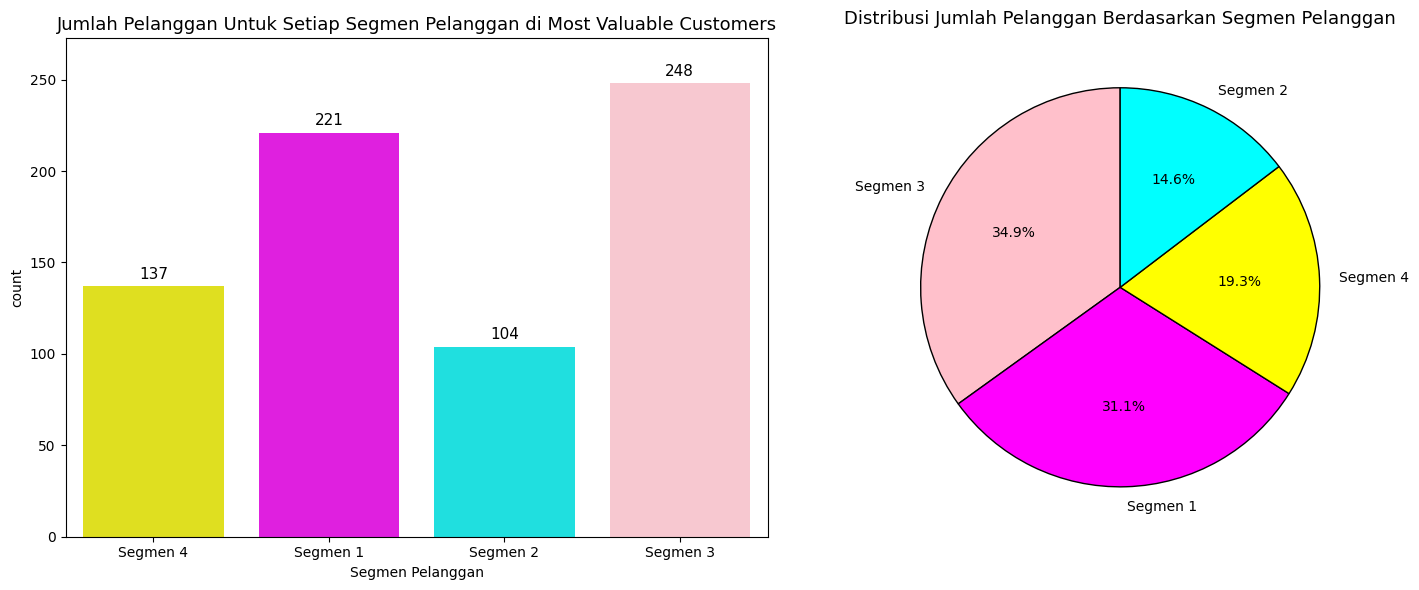

In [340]:
# Membuat dashboard dengan 1 baris dan 2 kolom
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

## --- PLOT 1: COUNTPLOT (Kiri) ---

# Membuat countplot
sns.countplot(
    data=df11, 
    x='Segmen Pelanggan', 
    palette={'Segmen 1': 'magenta', 'Segmen 2': 'cyan', 'Segmen 3': 'pink', 'Segmen 4': 'yellow'},
    ax=ax[0] # Menempatkan di posisi pertama
)

# Menampilkan angka di atas bar
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%d', label_type='edge', fontsize=11, padding=3)

ax[0].set_title("Jumlah Pelanggan Untuk Setiap Segmen Pelanggan di Most Valuable Customers", fontsize=13) # Menambahkan judul
ax[0].set_ylim(0, df11['Segmen Pelanggan'].value_counts().max() * 1.1) # Menyesuaikan batas atas sumbu y agar label tidak keluar dari grafik


## --- PLOT 2: PIE CHART (Kanan) ---

# Menghitung persentase setiap 'value' di kolom 'y'
y_percentage = df11['Segmen Pelanggan'].value_counts() / len(df11) * 100

# Membuat pie chart
# plt.figure(figsize=(7, 7)) jika diperlukan
y_percentage.plot.pie(
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['pink', 'magenta', 'yellow', 'cyan'], # 'Segmen 1' = magenta, 'Segmen 2' = cyan, 'Segmen 3' = pink, 'Segmen 4' = yellow
    wedgeprops={'edgecolor': 'black'},
    ax=ax[1] # Menempatkan di posisi kedua
)

ax[1].set_title('Distribusi Jumlah Pelanggan Berdasarkan Segmen Pelanggan', fontsize=13, pad=10)  # Menambahkan judul
ax[1].set_ylabel('') # Menghapus default label

# Mengatur tata letak agar tidak tumpang tindih
plt.tight_layout()

# Menampilkan plot
plt.show()

**📌 Total nilai transaksi yang dihasilkan setiap segmen pelanggan:**

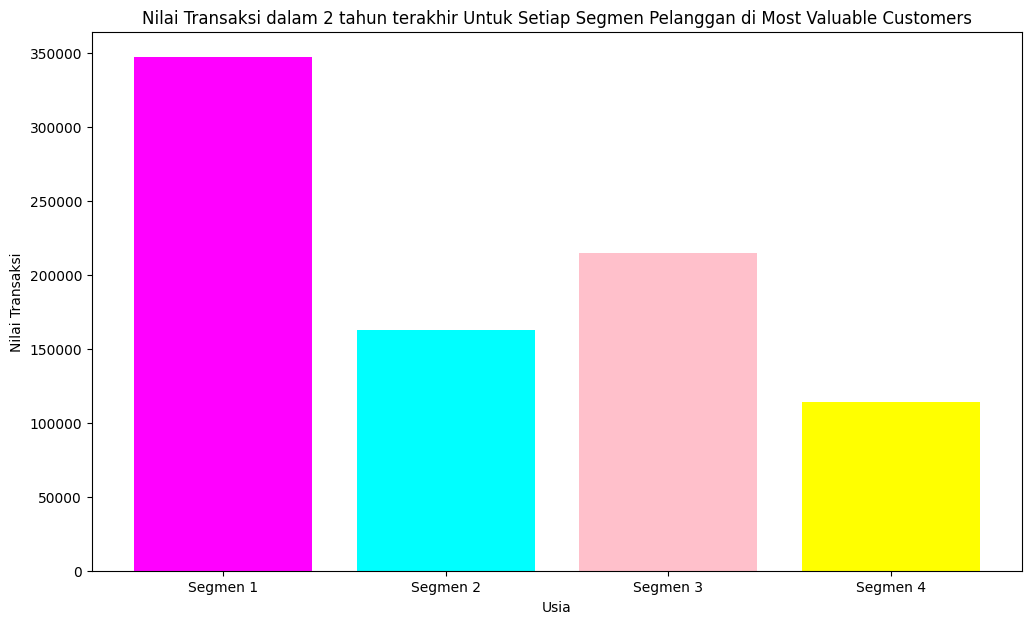

In [341]:

segmen_amount = df11[['Segmen Pelanggan', 'Total_Amount']].groupby('Segmen Pelanggan', as_index=False).sum()

plt.figure(figsize=(12,7))
plt.bar(segmen_amount['Segmen Pelanggan'], segmen_amount['Total_Amount'])
plt.bar(segmen_amount['Segmen Pelanggan'], segmen_amount['Total_Amount'], color=['magenta', 'cyan', 'pink', 'yellow'])
plt.title('Nilai Transaksi dalam 2 tahun terakhir Untuk Setiap Segmen Pelanggan di Most Valuable Customers')
plt.xlabel('Usia')
plt.ylabel('Nilai Transaksi')
plt.savefig('Nilai Transaksi dalam 2 tahun terakhir Untuk Setiap Segmen Pelanggan di Most Valuable Customers.png')
plt.show()

**📌 Rasio Transaksi untuk setiap segmen pelanggan:**

In [342]:
# Terhadap keseluruhan pelanggan supermarket

# Jumlah Pelanggan
df11_segmen_pelanggan_jumlah = pd.DataFrame(df11['Segmen Pelanggan'].value_counts()).reset_index()[['Segmen Pelanggan', 'count']]

# Nilai Transaksi
df11_segmen_pelanggan_nilai = df11[['Segmen Pelanggan', 'Total_Amount']].groupby('Segmen Pelanggan', as_index=False).sum()

dataDesc = []
for i in df11['Segmen Pelanggan'].unique():
    dataDesc.append([
        i,
        df11[df11['Segmen Pelanggan'] == i]['Total_Amount'].median(),
        df11_segmen_pelanggan_jumlah[(df11_segmen_pelanggan_jumlah['Segmen Pelanggan'] == i)]['count'].values[0],
        (100 * df11_segmen_pelanggan_jumlah[(df11_segmen_pelanggan_jumlah['Segmen Pelanggan'] == i)]['count'].values[0] / len(df)).round(2),
        df11_segmen_pelanggan_nilai[(df11_segmen_pelanggan_nilai['Segmen Pelanggan'] == i)]['Total_Amount'].values[0],
        (100 * df11_segmen_pelanggan_nilai[(df11_segmen_pelanggan_nilai['Segmen Pelanggan'] == i)]['Total_Amount'].values[0] / df['Total_Amount'].sum()).round(2),
    ])

df11_segmen_pelanggan = pd.DataFrame(dataDesc, columns=[
    "Segmen Pelanggan",
    "Nilai Transaksi per Pelanggan (Median)",
    "Jumlah Pelanggan",
    "% Jumlah Pelanggan",
    "Nilai Transaksi",
    "% Nilai Transaksi",
])

df11_segmen_pelanggan['Rasio Transaksi'] = (df11_segmen_pelanggan['% Nilai Transaksi'] / df11_segmen_pelanggan['% Jumlah Pelanggan']).round(2)
df11_segmen_pelanggan = df11_segmen_pelanggan.sort_values('Segmen Pelanggan').reset_index(drop=True)

print(f"Tabel rasio transaksi untuk setiap segmen pelanggan berdasarkan spending/income rate dan churn status:")
df11_segmen_pelanggan

Tabel rasio transaksi untuk setiap segmen pelanggan berdasarkan spending/income rate dan churn status:


,Segmen Pelanggan,Nilai Transaksi per Pelanggan (Median),Jumlah Pelanggan,% Jumlah Pelanggan,Nilai Transaksi,% Nilai Transaksi,Rasio Transaksi
0,Segmen 1,1536.0,221,11.23,347130,30.52,2.72
1,Segmen 2,1505.5,104,5.28,163032,14.33,2.71
2,Segmen 3,913.5,248,12.60,214734,18.88,1.50
3,Segmen 4,836.0,137,6.96,113884,10.01,1.44


*Notes:*
1. % Jumlah Pelanggan : persentase terhadap jumlah semua pelanggan supermarket.
2. % Nilai Transaksi : persentase terhadap total nilai transaksi semua pelanggan supermarket.
3. Rasio Transaksi : rasio persentase nilai transaksi terhadap persentase jumlah pelanggan.

**📌 Urutan Prioritas dari segmen pelanggan di "Most Valuable Customers"**

Strategi peningkatan penjualan yang paling efektif adalah memprioritaskan segmen yang memiliki daya beli tinggi (spending/income rate > median) namun memiliki risiko kehilangan nilai transaksi yang besar akibat status Churn. Maka, berdasarkan data 4 segmen di atas, berikut ini urutan prioritas segmen pelanggan:

*Rangkuman prioritas pelanggan berdasarkan kombinasi rasio transaksi, spending/income rate dan churn status pelanggan:*

| Prioritas No. | Level Prioritas | Segmen Pelanggan | Kontribusi Jumlah Pelanggan | Kontribusi Nilai Transaksi | Rasio Transaksi | Keterangan |
|-----|------------------|-------------|------------------|------------------|------------------|------------------|
| 1️⃣ | Highest | Segmen 1 <br> "High Spenders, <br> Churn" | 11.23 % | 30.52 % | 2.72 | ✅ Segmen paling krusial dan merupakan "raksasa yang tertidur". <br> ✅ Meskipun berstatus Churn,  pelanggan segmen ini memiliki dampak finansial paling besar bagi supermarket. <br> ✅ Menyumbang persentase nilai transaksi terbesar (30.52%) dengan rasio efisiensi yang sangat tinggi (2.72). <br> ✅ Mengeluarkan uang untuk mengejar mereka jauh lebih menguntungkan karena hasil penjualannya berlipat ganda. <br> ✅ 1 pelanggan di segmen ini menyumbang nilai transaksi yang lebih besar dari pelanggan di segmen 3 dan 4. |
| 2️⃣ | - | Segmen 2 <br> "High Spenders, <br> Loyal" | 5.28 % | 14.33 % | 2.71 | ✅ Segmen pelanggan "Sultan" yang masih setia. <br> ✅ Seperti segmen 1, memiliki spending/income rate yang tinggi dan rasio transaksi yang besar (2.70), namun saat ini mereka masih loyal (Non-Churn). <br> ✅ Walaupun jumlah mereka paling sedikit (5.28% dari total pelanggan), mereka adalah tulang punggung pendapatan yang stabil. |
| 3️⃣ | - | Segmen 3 <br> "Low Spenders, <br> Churn" | 12.60 % | 18.88 % | 1.50 | ✅ Memiliki jumlah massa terbesar (12.60% dari total pelanggan) dan nilai transaksi yang cukup signifikan (18.55%).  <br> ✅ Daya beli per individunya lebih rendah dibandingkan segmen 1 dan 2. | 
| 4️⃣ | Lowest | Segmen 4 <br> "Low Spenders, <br> Loyal" | 6.96 % | 10.01 % | 1.44 | ✅ Segmen yang stabil namun kontribusinya paling kecil, baik dari segi jumlah pelanggan (6.96%) maupun nilai transaksi (10.01%). <br> ✅ Daya beli per individunya juga paling rendah (1.44). |

*Kesimpulan:*
- Fokuskan sumber daya kita pada pelanggan dengan Spending/Income Rate > Median (segmen 1 dan 2) terlebih dahulu. 
- Secara kolektif, segmen 1 dan 2 hanya mewakili sekitar 16.51% pelanggan (lebih kecil dari gabungan segmen 3 dan 4), namun pelanggan di segmen 1 dan 2 sudah menjadikan supermarket kita sebagai bagian dari kebutuhan dan gaya hidup mereka. Itulah mengapa mereka memiliki kontribusi nilai transaksi yang masif (sekitar 44.85% dari total nilai transaksi). 
- Dampak finansial segmen 1 dan 2 terhadap total penjualan jauh lebih besar dari segmen 3 dan 4. Dari sisi Return of Investment, menaikkan angka penjualan dari segmen 1 dan 2 lebih efisien dibandingkan segmen 3 dan 4.

**📌 Menampilkan urutan prioritas pelanggan dalam dataset "Most Valuable Customers":**

In [343]:
def prioritas(x):
    if x == "Segmen 1":
        return "1"
    elif x == "Segmen 2":
        return "2"
    elif x == "Segmen 3":
        return "3"
    else:
        return "4"

df11['Prioritas No.'] = df11['Segmen Pelanggan'].apply(prioritas)
df11.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate,Spending/Income Rate (Median),Status Rate,Segmen Pelanggan,Prioritas No.
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801,0.829020,below median,Segmen 4,4
7446,1967,Master,Together,62513.0,2013-09-09,16,520,42,98,0,42,14,2,6,4,10,0,0,0,0,0,0,Gen X,48,Dewasa,125026.0,120k-140k,Non-Churn,Non-Single,716,20,18,35.80,0.572681,0.719561,below median,Segmen 4,4
2125,1959,Graduation,Divorced,63033.0,2013-11-15,82,194,61,480,225,112,30,1,3,4,8,0,0,0,0,0,0,Baby Boomer,56,Dewasa,126066.0,120k-140k,Churn,Single,1102,15,14,73.47,0.874145,0.719561,above median,Segmen 1,1
2114,1946,PhD,Single,82800.0,2012-11-24,23,1006,22,115,59,68,45,1,7,6,12,1,0,0,0,1,1,Baby Boomer,69,Lansia,165600.0,160k-180k,Non-Churn,Single,1315,25,24,52.60,0.794082,0.859810,below median,Segmen 4,4
6565,1949,Master,Married,76995.0,2013-03-28,91,1012,80,498,0,16,176,2,11,4,9,1,0,0,0,0,0,Baby Boomer,66,Lansia,153990.0,140k-160k,Churn,Non-Single,1782,24,22,74.25,1.157218,0.829020,above median,Segmen 1,1


### 📊🎯✅ **Business Question 11 : Bagaimana efektifitas discount terhadap "Most Valuable Customers" selama ini?**

In [344]:
print(f"Tabel berikut ini membandingkan jumlah transaksi dari pembelian dengan discount dan pembelian tanpa discount.")
print(f"Kolom Persentase menampilkan komposisi dari masing-masing pembelian dengan discount dan pembelian tanpa discount terhadap keseluruhan jumlah transaksi.")

data_discount = []
for col in df11.columns[[12,31,30]]:
    if df11[col].dtypes == 'int64':
        data_discount.append([
            col,
            df11[col].sum(),
            (df11[col].sum() / df11['Total_Quantity'].sum() * 100).round(2)
        ])

pd.DataFrame(data_discount, columns=[
    "Jenis Transaksi",
    "Jumlah Transaksi",
    "Persentase (%)"
])

Tabel berikut ini membandingkan jumlah transaksi dari pembelian dengan discount dan pembelian tanpa discount.
Kolom Persentase menampilkan komposisi dari masing-masing pembelian dengan discount dan pembelian tanpa discount terhadap keseluruhan jumlah transaksi.


,Jenis Transaksi,Jumlah Transaksi,Persentase (%)
0,NumDealsPurchases,1342,10.0
1,Purchases_without_discount,12072,90.0
2,Total_Quantity,13414,100.0


**📌 Insight:**
- Jumlah transaksi dengan harga discount hanya 10% dari keseluruhan jumlah transaksi. Berdasarkan data ini, program discount yang dilakukan selama ini relatif kurang efektif.

**📌 Jumlah transaksi dari "pembelian dengan discount" dan "pembelian tanpa discount" untuk setiap segmen pelanggan:**

In [345]:
df11.groupby(['Segmen Pelanggan'])[['Purchases_without_discount', 'NumDealsPurchases', 'Total_Quantity']].sum()

,Purchases_without_discount,NumDealsPurchases,Total_Quantity
Segmen Pelanggan,,,
Segmen 1,4041,385,4426
Segmen 2,1815,179,1994
Segmen 3,3927,504,4431
Segmen 4,2289,274,2563


### 📊🎯✅ **Business Question 12 : Bagaimana respon "Most Valuable Customers" terhadap kampanye promosi selama ini?**

In [346]:
print(f"Tabel berikut ini membandingkan jumlah transaksi dari setiap tahapan kampanye promosi yang dilakukan supermarket.")
print(f"Kolom Persentase menampilkan komposisi dari masing-masing tahapan kampanye promosi terhadap keseluruhan jumlah transaksi.")

jumlah_promosi = df11['AcceptedCmp1'].sum() + df11['AcceptedCmp2'].sum() + df11['AcceptedCmp3'].sum() + df11['AcceptedCmp4'].sum() + df11['AcceptedCmp5'].sum() + df11['Response'].sum() 

data_promosi = []
for col in df11.columns[16:22]:
    if df11[col].dtypes == 'int64':
        data_promosi.append([
            col,
            df11[col].sum(),
            (df11[col].sum() / jumlah_promosi * 100).round(2)
        ])

pd.DataFrame(data_promosi, columns=[
    "Kampanye Promosi",
    "Jumlah Transaksi",
    "Persentase (%)"
])

Tabel berikut ini membandingkan jumlah transaksi dari setiap tahapan kampanye promosi yang dilakukan supermarket.
Kolom Persentase menampilkan komposisi dari masing-masing tahapan kampanye promosi terhadap keseluruhan jumlah transaksi.


,Kampanye Promosi,Jumlah Transaksi,Persentase (%)
0,AcceptedCmp1,111,21.76
1,AcceptedCmp2,11,2.16
2,AcceptedCmp3,44,8.63
3,AcceptedCmp4,85,16.67
4,AcceptedCmp5,115,22.55
5,Response,144,28.24


**📌 Insight:**
- Respon terbanyak dari "Most Valuable Customers" terjadi saat kampanye promosi terakhir (kampanye ke-6) yaitu 28.13% dari keseluruhan jumlah transaksi.
- Namun, respon dari "Most Valuable Customers" saat kampanye pertama (21.76%) dan kampanye ke-5a (22.55%) tidak beda jauh dari respon saat kampanye terakhir.

**📌 Jumlah transaksi dari setiap tahapan kampanye promosi untuk setiap segmen pelanggan:**

In [347]:
df11.groupby(['Segmen Pelanggan'])[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum()

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
Segmen Pelanggan,,,,,,
Segmen 1,47,5,20,30,50,54
Segmen 2,24,3,10,15,31,46
Segmen 3,24,2,8,25,23,21
Segmen 4,16,1,6,15,11,23


### 📊🎯✅ **Business Question 13 : Apa produk yang diminati "Most Valuable Customers" selama ini?**

In [348]:
print(f"Tabel berikut ini membandingkan nilai transaksi dari setiap produk yang dijual oleh supermarket.")
print(f"Kolom Persentase menampilkan komposisi dari setiap produk terhadap total nilai transaksi seluruh Most Valuable Customers.")

data_product = []
for col in df11.columns[6:12]:
    if df11[col].dtypes == 'int64':
        data_product.append([
            col,
            df11[col].sum(),
            (df11[col].sum() / df11['Total_Amount'].sum() * 100).round(2),
            df11[col].median()
        ])

pd.DataFrame(data_product, columns=[
    "Jenis Produk",
    "Nilai Transaksi",
    "Persentase (%)",
    "Median Nilai Transaksi"
])

Tabel berikut ini membandingkan nilai transaksi dari setiap produk yang dijual oleh supermarket.
Kolom Persentase menampilkan komposisi dari setiap produk terhadap total nilai transaksi seluruh Most Valuable Customers.


,Jenis Produk,Nilai Transaksi,Persentase (%),Median Nilai Transaksi
0,MntWines,402356,47.97,532.5
1,MntFruits,39346,4.69,38.5
2,MntMeatProducts,251498,29.98,296.0
3,MntFishProducts,55850,6.66,61.5
4,MntSweetProducts,40308,4.81,40.0
5,MntGoldProds,49422,5.89,51.5


**📌 Insight:**
- Dalam 2 tahun terakhir, produk WINE adalah produk paling diminati.

**📌 Nilai transaksi dari masing-masing produk untuk setiap segmen pelanggan:**
- Berdasarkan tabel dan bar-plot di bawah ini, untuk masing-masing produk, Segmen 1 memiliki porsi nilai transaksi tertinggi, sedangkan Segmen 4 memiliki porsi nilai transaksi terendah. 
- Fakta ini didukung oleh data ratio transaksi yaitu ratio tertinggi dimiliki oleh Segmen 1 dan ratio terendah dimiliki oleh Segmen 4.

In [349]:
df11.groupby(['Segmen Pelanggan'])[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'Total_Amount']].sum()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Amount
Segmen Pelanggan,,,,,,,
Segmen 1,164522,14974,112360,21750,15574,17950,347130
Segmen 2,78111,7074,52251,9998,6551,9047,163032
Segmen 3,104634,11043,56088,15873,11733,15363,214734
Segmen 4,55089,6255,30799,8229,6450,7062,113884


In [350]:
segmen_product = df11[['Segmen Pelanggan', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'Total_Amount']].groupby('Segmen Pelanggan', as_index=False).sum()
segmen_product = segmen_product.rename(columns={'MntWines': 'Wine', 'MntFruits': 'Fruits', 'MntMeatProducts': 'Produk Meat', 'MntFishProducts': 'Produk Fish', 'MntSweetProducts': 'Produk Sweet', 'MntGoldProds': 'Produk Gold', 'Total_Amount' : 'Total Transaksi'})
segmen_product

,Segmen Pelanggan,Wine,Fruits,Produk Meat,Produk Fish,Produk Sweet,Produk Gold,Total Transaksi
0,Segmen 1,164522,14974,112360,21750,15574,17950,347130
1,Segmen 2,78111,7074,52251,9998,6551,9047,163032
2,Segmen 3,104634,11043,56088,15873,11733,15363,214734
3,Segmen 4,55089,6255,30799,8229,6450,7062,113884


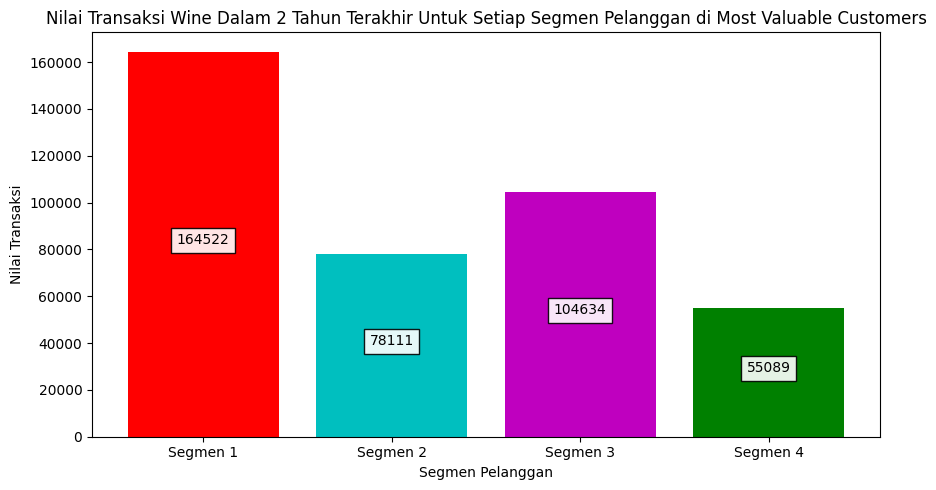

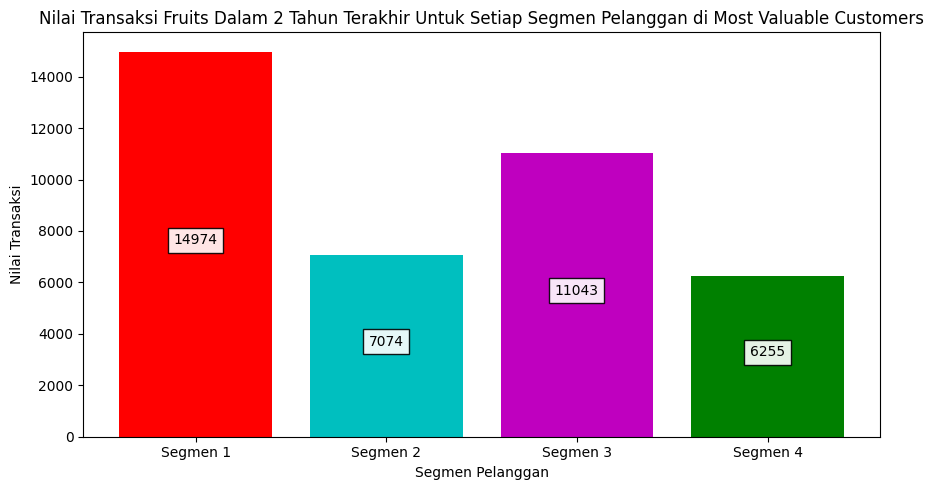

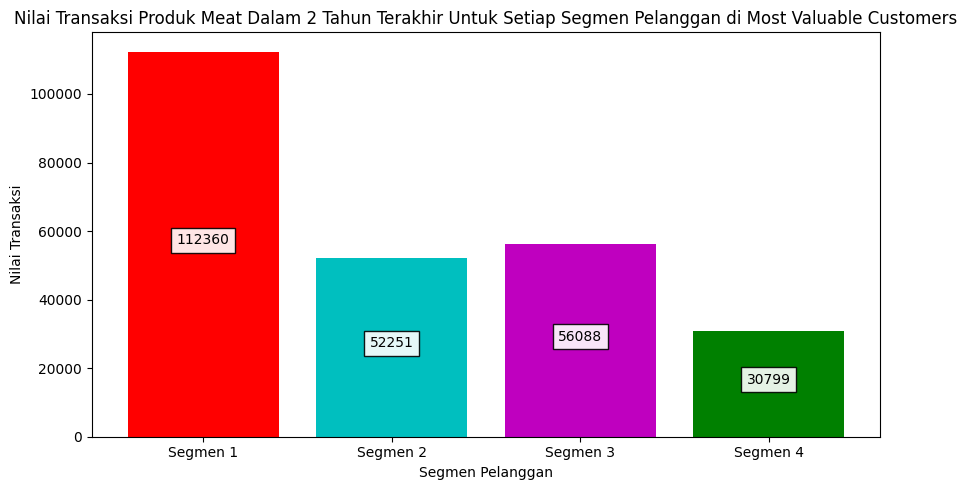

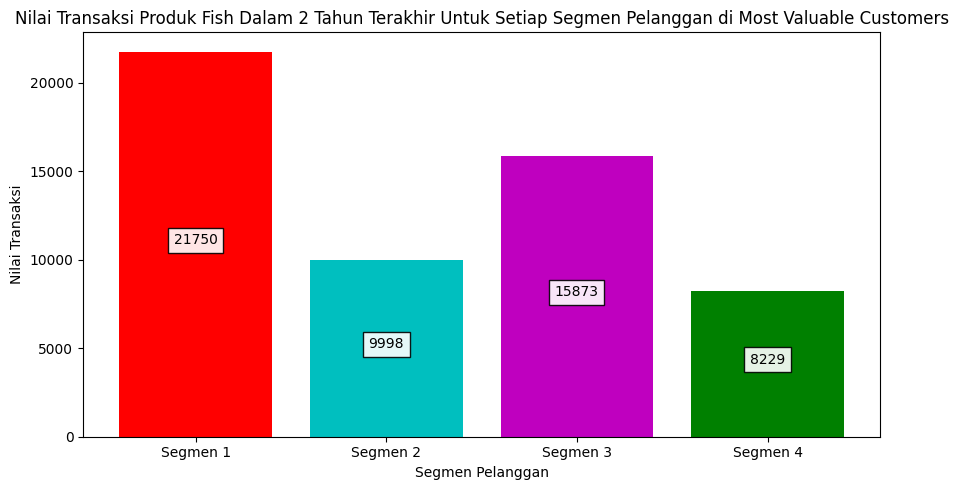

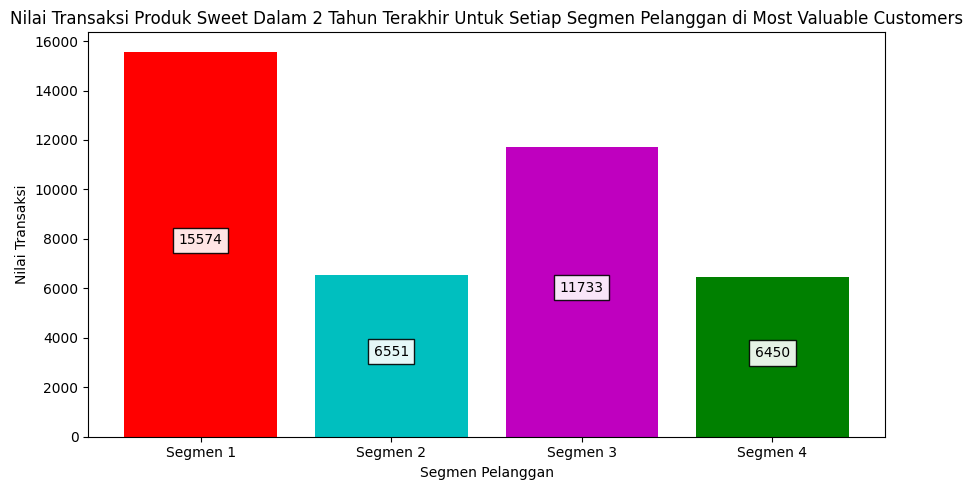

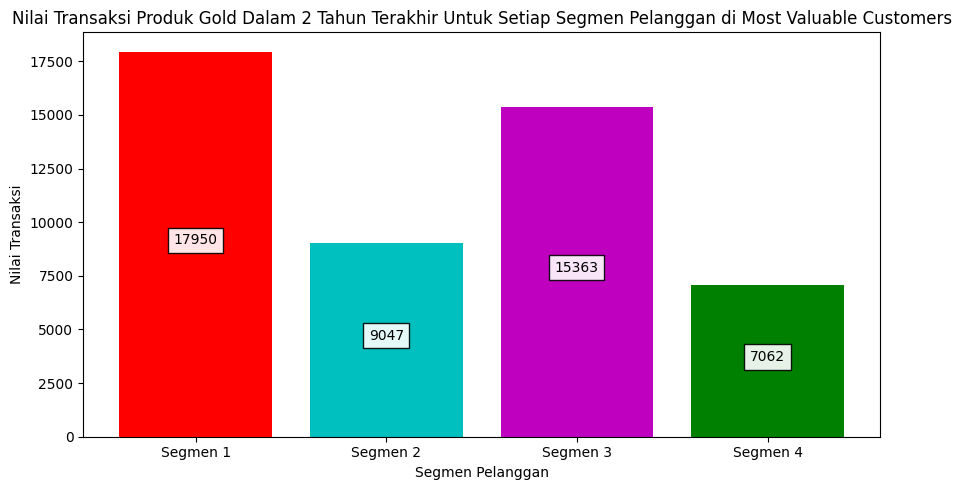

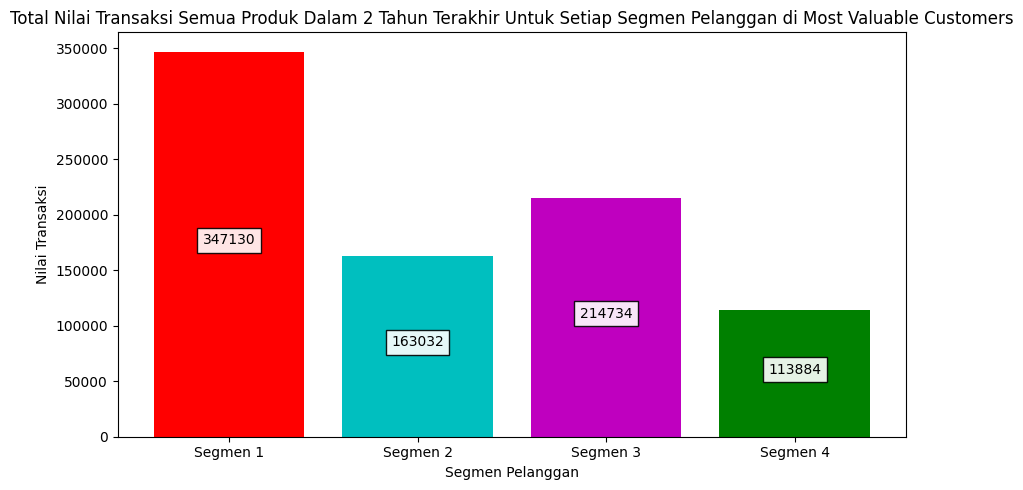

In [351]:
for col in segmen_product[1:6]:

    if segmen_product[col].dtypes == 'int64':
        plt.figure(figsize=(9,5))
        
        if col == 'Total Transaksi':
            plt.title(f"Total Nilai Transaksi Semua Produk Dalam 2 Tahun Terakhir Untuk Setiap Segmen Pelanggan di Most Valuable Customers")
        else:
            plt.title(f"Nilai Transaksi {col} Dalam 2 Tahun Terakhir Untuk Setiap Segmen Pelanggan di Most Valuable Customers")
    
        plt.bar(segmen_product['Segmen Pelanggan'], segmen_product[col], color=['r', 'c', 'm', 'g'])
        plt.xlabel('Segmen Pelanggan')
        plt.ylabel('Nilai Transaksi')

        for i in range(len(segmen_product['Segmen Pelanggan'])): 
            plt.text(i, segmen_product[col][i]//2, segmen_product[col][i], ha='center',
                bbox=dict(facecolor='white', alpha=0.9)) # White box with slight transparency (0.9)

        plt.tight_layout()
        plt.show()

### 📊🎯✅ **Business Question 14 : Bagaimana cara "Most Valuable Customers" melakukan transaksi selama ini?**

In [352]:
print(f"Tabel berikut ini membandingkan jumlah transaksi dari setiap metode/media yang dipilih pelanggan untuk melakukan transaksi di supermarket.")
print(f"Kolom Persentase menampilkan komposisi dari masing-masing metode/media terhadap keseluruhan jumlah transaksi.")

data_product = []
for col in df11.columns[13:16]:
    if df11[col].dtypes == 'int64':
        data_product.append([
            col,
            df11[col].sum(),
            (df11[col].sum() / df11['Total_Quantity'].sum() * 100).round(2)
        ])

pd.DataFrame(data_product, columns=[
    "Metode/Media Transaksi",
    "Jumlah Transaksi",
    "Persentase (%)"
])

Tabel berikut ini membandingkan jumlah transaksi dari setiap metode/media yang dipilih pelanggan untuk melakukan transaksi di supermarket.
Kolom Persentase menampilkan komposisi dari masing-masing metode/media terhadap keseluruhan jumlah transaksi.


,Metode/Media Transaksi,Jumlah Transaksi,Persentase (%)
0,NumWebPurchases,3921,29.23
1,NumCatalogPurchases,3482,25.96
2,NumStorePurchases,6011,44.81


**📌 Insight:**
- Transaksi paling banyak (44.81%) dilakukan secara offline langsung di supermarket.

**📌 Jumlah transaksi dari masing-masing metode/media untuk setiap segmen pelanggan:**

In [353]:
df11.groupby(['Segmen Pelanggan'])[['Total_Quantity', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum().round(2)

,Total_Quantity,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Segmen Pelanggan,,,,
Segmen 1,4426,1251,1291,1884
Segmen 2,1994,583,578,833
Segmen 3,4431,1330,1031,2070
Segmen 4,2563,757,582,1224


### 📊🎯✅ **Business Question 15 : Berapa potensi tambahan nilai transaksi dari "Most Valuable Customers" dalam 2 tahun ke depan?**

Kita akan menghitung potensi tambahan nilai transaksi **berdasarkan "churn rate" dan "spending/income rate" secara terpisah.** Kombinasi antara keduanya akan menghasilkan potensi peningkatan nilai transaksi yang lebih besar lagi.

#### 📌 **15.A. Berdasarkan Churn Rate**

Customer Churn (Customer Lost) akan merugikan supermarket karena menunjukkan supermarket tidak bisa mempertahankan pelanggan tapi telah kehilangan pelanggan. Alasannya:
- Lebih sedikit pelanggan berarti revenue yang lebih kecil
- Pelanggan yang tidak puas tidak akan merekomendasikan supermarket kita
- Mendapatkan pelanggan baru lebih mahal dari mempertahankan pelanggan saat ini (sekitar 5-25x lebih mahal). Mempertahankan pelanggan lebih hemat biaya.

**Kondisi churn rate saat ini:**

Berdasarkan data dari Business Question 8 (seperti ditunjukkan oleh tabel dibawah ini), churn rate di segmen "Most valuable customers" yaitu 23.83% dengan median dari nilai transaksi pelanggan churn (dalam 2 tahun terakhir) yaitu $1,165.

In [354]:
pelanggan_churn = df11_churn_status.loc[df11_churn_status['Status Churn'] == 'Churn'].index[0]
df11_churn_status.iloc[[pelanggan_churn]]

,Status Churn,Nilai Transaksi per Pelanggan (Median),Jumlah Pelanggan,% Jumlah Pelanggan,Nilai Transaksi,% Nilai Transaksi,Rasio Transaksi
1,Churn,1165.0,469,23.83,561864,49.4,2.07


**Target 2 tahun ke depan:**

- Churn rate tahunan yang dapat diterima dalam bisnis Consumer Goods & Retail (seperti supermarket) adalah 7.55% (atau churn rate bulanan <1%) ==> source : https://recurly.com/research/churn-rate-benchmarks/
- Jika supermarket bisa mengurangi churn rate bulanan (yang berasal dari "Most valuable customers") sampai 1% dari keseluruhan pelanggan (==> 1% x 1968 = 19 pelanggan), maka supermarket akan mendapatkan tambahan nilai transaksi sebagai berikut:
    - Pengurangan chun rate = 23.83% - 1% = 22.83% (==> pelanggan churn berkurang sebanyak 450 orang)
    - 450 pelanggan x $1,165 = $524,250 ==> tambahan nilai transaksi untuk 2 tahun ke depan.

**Estimasi potensi tambahan nilai transaksi dalam 2 tahun ke depan berdasarkan Churn Rate:**

Berikut ini adalah tabel estimasi potensi tambahan nilai transaksi untuk beberapa alternatif "target chun rate" yang bisa menjadi referensi bagi Board of Director. Tabel ini juga bisa membantu penghitungan alokasi budget promo, khususnya kepada "Most Valuable Customers", sehingga supermarket tetap mendapatkan profit meski memberikan diskon.

In [355]:
data_chun = []
for i in range(1, 25, 2):
        data_chun.append([
            i,
            int(i * len(df) / 100), # Mengubah hasil menjadi integer. Kemudian memotong angka di belakang koma (pembulatan ke bawah/truncation).
            round((23.83 - i) * len(df) * 1165 / 100) # round = pembulatan matematis (di atas 0.5 naik ke atas, di bawah 0.5 turun ke bawah).
        ])

pd.DataFrame(data_chun, columns=[
    "Target Churn Rate (%)",
    "Target Jumlah Pelanggan Churn",
    "Potensi Tambahan nilai transaksi dalam 2 tahun ke depan ($)"
])

,Target Churn Rate (%),Target Jumlah Pelanggan Churn,Potensi Tambahan nilai transaksi dalam 2 tahun ke depan ($)
0,1,19,523428
1,3,59,477574
2,5,98,431719
3,7,137,385865
4,9,177,340010
5,11,216,294156
6,13,255,248302
7,15,295,202447
8,17,334,156593
9,19,373,110738


#### 📌 **15.B. Berdasarkan Spending/Income Rate (Rasio Pengeluaran terhadap Pendapatan)**

**Perbandingan Sederhana:**

| Nama Pelanggan | Income | Nilai Transaksi | Spending/Income Rate | Hasil Perbandingan |
|-----|------------------|-------------|------------------|------------------|
| A | Rp 10 Juta | Rp 5 Juta | 50%  | ✅ Secara nominal, A dan B sama-sama menyumbang Rp 5 Juta ke supermarket. <br> ✅ Namun A lebih bernilai secara loyalitas karena sudah menjadikan supermarket kita sebagai bagian besar dari hidup mereka. |
| B | Rp 50 Juta | Rp 5 Juta | 10%  | ✅ **B adalah peluang besar yang belum tergarap maksimal karena baru mengambil 10% dari potensi daya beli mereka. <br> ✅ Maka perlu ambil potensi mereka lebih banyak lagi dengan cara meningkatkan spending mereka.** |

**Kondisi pelanggan yang memiliki "spending/incomer rate < median" saat ini:**


Berdasarkan data dari Business Question 9 (seperti ditunjukkan oleh tabel dibawah ini), terdapat 385 pelanggan dari kelompok "Most Valuable Customers" memiliki "spending/incomer rate < median" pada saat ini.

In [356]:
pelanggan_rate_below_median = df11_spending_income_rate.loc[df11_spending_income_rate['Status Spending/Income Rate'] == 'below median'].index[0]
df11_spending_income_rate.iloc[[pelanggan_rate_below_median]]

,Status Spending/Income Rate,Nilai Transaksi per Pelanggan (Median),Jumlah Pelanggan,% Jumlah Pelanggan,Nilai Transaksi,% Nilai Transaksi,Rasio Transaksi
0,below median,899.0,385,54.23,328618,39.18,0.72


**Target 2 tahun ke depan:**

Dalam 2 tahun ke depan, kita menargetkan pelanggan yang memiliki "spending/income rate < median" dapat melakukan lebih banyak transaksi di supermarket kita, sehingga spending/income rate mereka dapat meningkat sampai mencapai median dari masing-masing kelompok income.

**Estimasi potensi tambahan nilai transaksi dalam 2 tahun ke depan berdasarkan Spending/Income Rate::**

Untuk menghitung potensi tambahan nilai transaksi, kita melakukan beberapa penghitungan sebagai berikut:
1. Menghitung selisih antara **"spending/income rate pelanggan"** dengan **"median rate"** sesuai dengan kelompok income pelanggan.
2. Kemudian selisih rate tersebut dikalikan dengan income (dalam 2 tahun) saat ini, sehingga menghasilkan potensi tambahan nilai transaksi. Untuk kondisi pesimis/konservatif, kita berasumsi bahwa income pelanggan tidak berubah dalam 2 tahun ke depan.

*Menghitung potensi tambahan nilai transaksi untuk masing-masing pelanggan "Most Valuable Customers":*

In [357]:
df11_rate_below_median = df11[(df11['Status Rate'] == "below median")]

# 1. Menghitung selisih antara "spending/income rate pelanggan" dengan "median rate" sesuai dengan kelompok income pelanggan. 
# Kemudian, menambahkan kolom selisih rate dalam dataset.
df11_rate_below_median['Potensi Kenaikan Spending/Income Rate'] = (df11_rate_below_median['Spending/Income Rate (Median)'] - df11_rate_below_median['Spending/Income Rate']).round(2)

# 2. Menghitung "potensi tambahan nilai transaksi" dengan cara mengalikan selisih rate "dari nomor 1 di atas" dengan income (dalam 2 tahun) saat ini.
# Kemudian, menambahkan kolom potensi tambahan nilai transaksi dalam dataset.
df11_rate_below_median['Potensi Tambahan Nilai Transaksi'] = (df11_rate_below_median['Potensi Kenaikan Spending/Income Rate'] * df11_rate_below_median['Income 2 tahun']).round(2)

df11_rate_below_median.iloc[:, np.r_[22, 24, 28, 26, 27, 33:40]].head()

,Generation,Age_Category,Marital_Category,Kelompok Income 2 tahun_20k,Churn_Status,Spending/Income Rate,Spending/Income Rate (Median),Status Rate,Segmen Pelanggan,Prioritas No.,Potensi Kenaikan Spending/Income Rate,Potensi Tambahan Nilai Transaksi
ID,,,,,,,,,,,,
4141,Gen X,Dewasa,Non-Single,140k-160k,Non-Churn,0.541801,0.829020,below median,Segmen 4,4,0.29,41535.54
7446,Gen X,Dewasa,Non-Single,120k-140k,Non-Churn,0.572681,0.719561,below median,Segmen 4,4,0.15,18753.90
2114,Baby Boomer,Lansia,Single,160k-180k,Non-Churn,0.794082,0.859810,below median,Segmen 4,4,0.07,11592.00
4047,Baby Boomer,Lansia,Non-Single,120k-140k,Non-Churn,0.416386,0.719561,below median,Segmen 4,4,0.30,39194.40
4339,Gen X,Dewasa,Non-Single,120k-140k,Churn,0.677772,0.719561,below median,Segmen 3,3,0.04,5388.24


*Menghitung total potensi tambahan nilai transaksi untuk semua pelanggan "Most Valuable Customers":*

Berikut ini adalah tabel estimasi potensi tambahan nilai transaksi seandainya kita bisa meningkatkan spending/income rate sampai mencapai median dari masing-masing kelompok income. Tabel ini bisa menjadi referensi bagi Board of Director. Tabel ini juga bisa membantu penghitungan alokasi budget promo terhadap "Most Valuable Customers", sehingga supermarket tetap mendapatkan profit meski memberikan diskon.

In [358]:
data_rate = []
for i in df11_rate_below_median['Kelompok Income 2 tahun_20k'].unique():
    data_rate.append([
        i,
        df11_rate_below_median[df11_rate_below_median['Kelompok Income 2 tahun_20k'] == i]['Potensi Tambahan Nilai Transaksi'].sum(),
    ])

df11_potensi_transaksi = pd.DataFrame(data_rate, columns=[
    "Kelompok Income 2 tahun",
    "Potensi Tambahan nilai transaksi dalam 2 tahun ke depan ($)",
])

print(f"Dari {len(df11[(df11['Status Rate'] == "below median")])} pelanggan yang memiliki spending/income rate < median, kita punya potensi tambahan nilai transaksi sebesar {df11_potensi_transaksi['Potensi Tambahan nilai transaksi dalam 2 tahun ke depan ($)'].sum()} untuk 2 tahun ke depan.")
print(f"Berikut ini adalah rincian potensi tambahan nilai transaksi untuk setiap kategori income.")
 
df11_potensi_transaksi

Dari 385 pelanggan yang memiliki spending/income rate < median, kita punya potensi tambahan nilai transaksi sebesar 10614819.8 untuk 2 tahun ke depan.
Berikut ini adalah rincian potensi tambahan nilai transaksi untuk setiap kategori income.


,Kelompok Income 2 tahun,Potensi Tambahan nilai transaksi dalam 2 tahun ke depan ($)
0,140k-160k,3811533.18
1,120k-140k,4215886.46
2,160k-180k,2099779.54
3,>200k,14333.56
4,180k-200k,473287.06


In [359]:
# Simpan df11 ke dalam file CSV
df11.to_csv('df11.csv', index=False)

## 7. Actionable Recommendation Berdasarkan Analisa Data Historis Supermarket

Untuk memaksimalkan penjualan berdasarkan data tersebut, strategi marketing harus dibedakan antara Reaktivasi (untuk yang Churn) dan Retensi/Pengembangan (untuk yang Non-Churn). Berikut adalah langkah taktis untuk setiap segmen:

**📌 Rangkuman rekomendasi supaya omset penjualan meningkat untuk setiap segmen:**

| Prioritas No. | Segmen Pelanggan dan Katakteristik | Fokus Strategi | Contoh Implementasi |
|------------------|------------------|-------------------|------------------|
| 1️⃣ | **Segmen 1** - *"The Lost Giants"* <br> Nilai transaksi tinggi, tapi sudah berhenti belanja di supermarket. | ✅ *"Kembalilah, kami punya penawaran spesial untuk Anda."* <br> ✅ Re-activation (merebut kembali omzet besar) <br> ✅ Mengembalikan mereka akan memberikan lonjakan penjualan paling signifikan dibandingkan segmen lainnya. | ✅ **Investigasi penyebab:** Kirim survei untuk mengetahui alasan mereka berhenti belanja (apakah masalah layanan, harga, atau pindah ke kompetitor) <br> ✅ **Penawaran Re-aktivasi Eksklusif:** Ajak mereka untuk bertransaksi lagi dengan memberikan diskon besar atau paket bundling premium untuk transaksi pertama setelah kembali belanja. <br> ✅ **Personal Service:** Dengan rasio transaksi yang tinggi (2.72), pertimbangkan layanan khusus atau akses prioritas jika mereka kembali belanja. |
| 2️⃣ | **Segmen 2** - *"The Platinum Loyalists"* <br> Aset paling berharga yang masih aktif belanja di supermarket. | ✅ *"Terima kasih atas kesetiaan Anda, ini keistimewaan untuk Anda."* <br> ✅ Retention (mempertahankan loyalitas aset terbaik) <br> ✅ Untuk mengamankan nilai transaksi yang sudah ada, mereka perlu dijaga supaya tidak berpindah ke kompetitor dan menjadi pelanggan churn. | ✅ **VIP Loyalty Program:** berikan reward eksklusif yang lebih tinggi dari segmen lain atau "early access" ke produk baru. <br> ✅ **Upselling:** Tawarkan produk/layanan di level yang lebih tinggi lagi, sehingga frekuensi belanja mereka meningkat. <br> ✅ **Referral Program:** berikan insentif atau diskon jika mereka berhasil membawa pelanggan baru. |
| 3️⃣ | **Segmen 3** <br> Jumlahnya banyak, namun daya belinya rendah dan sudah berhenti belanja di supermarket. | ✅ Mencari kuantitas <br> ✅ Mengajak mereka kembali belanja dalam jumlah besar dengan promo yang sesuai dengan budget mereka (karena spending/income rate < median). | ✅ Berikan promo yang menekankan pada "Harga Termurah" atau "Gratis Ongkir", karena mereka cenderung sensitif terhadap harga. <br> ✅ Fokuskan konten marketing untuk mengingatkan mereka kembali pada manfaat produk yang pernah mereka beli sebelumnya. | 
| 4️⃣ | **Segmen 4** - *"The Steady Supporters"* <br> Setia belanja di supermarket, namun hemat. | ✅ Menaikkan nilai transaksi sehingga spending/income rate bisa perlahan naik melewati batas median. | ✅ Berikan loyalty program agar mereka tetap bertahan, namun jangan alokasikan anggaran marketing yang besar di segmen ini. <br> ✅ Rekomendasikan produk pelengkap yang murah untuk meningkatkan jumlah item dalam satu keranjang belanja. <br> ✅ Berikan diskon dengan nominal minimum belanja tertentu untuk mendorong mereka berbelanja sedikit di atas kebiasaan biasanya. |

*Kesimpulan:*
1.	**Pelanggan prioritas 1 dan 2 (Spending/Income Rate > Median)** – Mereka adalah kelompok yang tidak ragu mengeluarkan uang. Kehilangan 1 pelanggan di segmen 1 dan 2 sama sakitnya dengan kehilangan hampir 2 orang di segmen 3 dan 4. Fokus pada kualitas layanan. Tawarkan produk Premium atau High-End tanpa terlalu khawatir dengan sensitivitas harga. 
2.	**Pelanggan prioritas 3 dan 4 (Spending/Income Rate < Median)** – Mereka adalah kelompok yang berhati-hati karena memiliki anggaran terbatas. Tawarkan produk yang bersifat “Value-for-Money” atau berikan diskon agar mereka mendapatkan keuntungan maksimal.

**📌 Rekomendasi tambahan:**

| No. | Fokus Strategi | Contoh Implementasi |
|-------|------------------|------------------|
| 1 | Kampanye promosi | ✅ Optimalkan promo/discount langsung di kampanye pertama, supaya lebih banyak pelanggan yang langsung membeli produk diskon tanpa menunggu tahapan kampanye berikutnya. |
| 2 | Jenis produk | ✅ Tingkatkan promo dan beri tawaran khusus bagi pelanggan yang membeli produk FRUITS, SWEET, FISH dan GOLD. Kampanye marketing ini bisa berupa paket pembelian bundling. <br> ✅ Tambah variasi sub-produk untuk masing-masing produk, sehingga pelanggan tidak perlu pergi ke supermarket kompetitor. |
| 3 | Metode/media transaksi | ✅ Kurangi biaya tambahan (seperti admin fee, service charge dll) yang terdapat di transaksi online melalui website supermarket. Biaya tambahan ini mungkin juga menjadi penyebab churn. |

> Lakukan juga **penambahan data pelanggan terbaru**, dan diikuti dengan **analisa ulang secara rutin** berdasarkan data terbaru untuk meningkatkan akurasi penentuan ”most valuable customer”.

# **======= Machine Learning Modelling =======**

Untuk melakukan machine learning modelling, kita akan lakukan Feature Engineering (Data Conversion) dan Feature Selection terlebih dahulu. Feature selection untuk melihat fitur mana yang bisa di-drop, dipertahankan maupun dikonversi supaya hasil Feature Importances bisa lebih akurat. Hasil Feature Engineering (Data Conversion) dan Feature Selection disimpan dalam **Dataset df2**.

In [360]:
# Salin df ke df2
df2 = df.copy()

## 8. Feature Engineering (Data Conversion) untuk Machine Learning

### 8.1 Label Encoding - Ordinal Encoding

📌 **A. Kolom Generation**

Data Generation (Kolom Kategorikal - Ordinal) dirubah menjadi Kolom Numerikal dengan pembobotan sesuai tingkat usia pelanggan, yaitu:

| Generasi         | Tahun Lahir   | Usia di 2015   | Skor Generasi     |
|-----------------|--------------|------------------|------------------|
| Silent         | 1928 - 1945   | 70 - 87 tahun   | 5 |
| Baby Boomer    | 1946 - 1964   | 51 - 69 tahun   | 4 |
| Gen X          | 1965 - 1980   | 35 - 50 tahun   | 3 |
| Milenial       | 1981 - 1996   | 19 - 34 tahun   | 2 |
| Gen Z          | 1997 - 2012   | 3 - 18 tahun   | 1 |

In [361]:
df2['Generation_Score'] = df2['Generation'].map({'Gen Z' : 1, 'Milenial' : 2, 'Gen X' : 3, 'Baby Boomer' : 4, 'Silent' : 5}).astype('int64')
df2.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate,Generation_Score
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58,Dewasa,116276.0,100k-120k,Churn,Single,1617,22,19,73.50,1.390657,4
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61,Lansia,92688.0,80k-100k,Churn,Single,27,4,2,6.75,0.029130,4
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801,3
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0,Milenial,31,Dewasa,53292.0,40k-60k,Non-Churn,Non-Single,53,6,4,8.83,0.099452,2
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0,Milenial,34,Dewasa,116586.0,100k-120k,Churn,Non-Single,422,14,9,30.14,0.361965,2


📌 **B. Kolom Age_Category**

Data Age_Category (Kolom Kategorikal - Ordinal) dirubah menjadi Kolom Numerikal dengan pembobotan sesuai tingkat usia pelanggan, yaitu:

| Kategori     | Rentang Usia      | Skor Usia      |
|-------------|------------------|------------------|
| Balita   | 0-4 tahun     | 1 |
| Anak-anak  | 5-9 tahun  | 2 |
| Remaja | 10-17 tahun  | 3 |
| Dewasa  | 18-59 tahun | 4 |
| Lansia  | 60 tahun ke atas | 5 |

In [362]:
df2['Age_Score'] = df2['Age_Category'].map({'Balita' : 1, 'Anak-anak' : 2, 'Remaja' : 3, 'Dewasa' : 4, 'Lansia' : 5})
df2.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate,Generation_Score,Age_Score
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58,Dewasa,116276.0,100k-120k,Churn,Single,1617,22,19,73.50,1.390657,4,4
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61,Lansia,92688.0,80k-100k,Churn,Single,27,4,2,6.75,0.029130,4,5
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801,3,4
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0,Milenial,31,Dewasa,53292.0,40k-60k,Non-Churn,Non-Single,53,6,4,8.83,0.099452,2,4
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0,Milenial,34,Dewasa,116586.0,100k-120k,Churn,Non-Single,422,14,9,30.14,0.361965,2,4


📌 **C. Kolom Education**

Data Education (Kolom Kategorikal - Ordinal) dirubah menjadi Kolom Numerikal dengan pembobotan sesuai tingkat pendidikan customer, yaitu:

| Kategori     | Skor Usia      |
|-------------|-----------------|
| Basic | 1 |
| 2n Cycle  | 2 |
| Graduation | 3 |
| Master | 4 |
| PhD | 5 |

In [363]:
df2['Education_Score'] = df2['Education'].map({'Basic' : 1, '2n Cycle' : 2, 'Graduation' : 3, 'Master' : 4, 'PhD' : 5})
df2.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate,Generation_Score,Age_Score,Education_Score
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58,Dewasa,116276.0,100k-120k,Churn,Single,1617,22,19,73.50,1.390657,4,4,3
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61,Lansia,92688.0,80k-100k,Churn,Single,27,4,2,6.75,0.029130,4,5,3
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801,3,4,3
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0,Milenial,31,Dewasa,53292.0,40k-60k,Non-Churn,Non-Single,53,6,4,8.83,0.099452,2,4,3
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0,Milenial,34,Dewasa,116586.0,100k-120k,Churn,Non-Single,422,14,9,30.14,0.361965,2,4,5


### 8.2 Label Encoding - Binary Encoding

📌 **A. Kolom Marital_Category** 

Kolom Marital_Category (Kolom Kategorikal - Binary) dirubah menjadi Kolom Numerikal sesuai status pernikahan pelanggan seperti di bawah ini:

| Marital_Category     | Status Pernikahan Dalam df           | Skor Pernikahan      |
|-------------|-----------------------|-----------------------|
| Single     | Alone, Single, Divorced, Widow   | 0 |
| Non-Single | Married, Together, Absurd, YOLO | 1 |

In [364]:
df2['Marital_Score'] = df2['Marital_Category'].map({'Single' : 0, 'Non-Single' : 1})
df2.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate,Generation_Score,Age_Score,Education_Score,Marital_Score
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58,Dewasa,116276.0,100k-120k,Churn,Single,1617,22,19,73.50,1.390657,4,4,3,0
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61,Lansia,92688.0,80k-100k,Churn,Single,27,4,2,6.75,0.029130,4,5,3,0
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801,3,4,3,1
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0,Milenial,31,Dewasa,53292.0,40k-60k,Non-Churn,Non-Single,53,6,4,8.83,0.099452,2,4,3,1
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0,Milenial,34,Dewasa,116586.0,100k-120k,Churn,Non-Single,422,14,9,30.14,0.361965,2,4,5,1


📌 **B. Kolom Churn_Status** 

Kolom Marital_Category (Kolom Kategorikal - Binary) dirubah menjadi Kolom Numerikal sesuai status pernikahan pelanggan seperti di bawah ini:

| Recency  | Status Churn  | Skor Churn   |
|-------------|-----------------------|---------|
| 30 hari | Non-churn (pelanggan loyal)   | 0 |
| >30 hari  | Churn (pelanggan tidak loyal) | 1 |


In [365]:
df2['Churn_Score'] = df2['Churn_Status'].map({'Non-Churn' : 0, 'Churn' : 1})
df2.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate,Generation_Score,Age_Score,Education_Score,Marital_Score,Churn_Score
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58,Dewasa,116276.0,100k-120k,Churn,Single,1617,22,19,73.50,1.390657,4,4,3,0,1
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61,Lansia,92688.0,80k-100k,Churn,Single,27,4,2,6.75,0.029130,4,5,3,0,1
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801,3,4,3,1,0
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0,Milenial,31,Dewasa,53292.0,40k-60k,Non-Churn,Non-Single,53,6,4,8.83,0.099452,2,4,3,1,0
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0,Milenial,34,Dewasa,116586.0,100k-120k,Churn,Non-Single,422,14,9,30.14,0.361965,2,4,5,1,1


### 8.3 Cross Features - Penambahan Kolom Baru

📌 **A. Kolom Membership_Duration** 

Kolom `Membership_Duration` = Sudah berapa hari pelanggan menjadi member supermarket, terhitung sejak enrolment. 

Dataset tidak menunjukkan kapan terjadinya transaksi. Tapi Kolom 'Dt_Customer' menunjukkan enrolment pelanggan mulai 8-Januari-2012 s/d 6-Desember-2014. Tahun 2015 adalah tahun terdekat dengan enrolment pelanggan terakhir. Maka untuk analisa data, kita gunakan tahun 2015 (yaitu 31-Desember-2015) sebagai dasar penentuan sudah berapa lama pelanggan menjadi member supermarket.

In [366]:
# Pastikan kolom Dt_Customer sudah bertipe datetime
df2['Dt_Customer'] = pd.to_datetime(df2['Dt_Customer'])

# Hitung berapa lama (dalam hari) pelanggan menjadi member supermarket. Ambil angka harinya saja
df2['Membership_Duration'] = (pd.to_datetime('2015-12-31') - df2['Dt_Customer']).dt.days

df2.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate,Generation_Score,Age_Score,Education_Score,Marital_Score,Churn_Score,Membership_Duration
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58,Dewasa,116276.0,100k-120k,Churn,Single,1617,22,19,73.50,1.390657,4,4,3,0,1,1361
2174,1954,Graduation,Single,46344.0,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61,Lansia,92688.0,80k-100k,Churn,Single,27,4,2,6.75,0.029130,4,5,3,0,1,515
4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801,3,4,3,1,0,862
6182,1984,Graduation,Together,26646.0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,0,0,0,0,0,0,Milenial,31,Dewasa,53292.0,40k-60k,Non-Churn,Non-Single,53,6,4,8.83,0.099452,2,4,3,1,0,455
5324,1981,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,0,0,0,0,0,0,Milenial,34,Dewasa,116586.0,100k-120k,Churn,Non-Single,422,14,9,30.14,0.361965,2,4,5,1,1,711


## 9. Feature selection

### 9.1 Tahap 1: Cek Data Leakage

Fitur `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts` dan `MntGoldProds` **bisa menyebabkan leakage** karena:
1. Fitur `Total_Amount` (Target)) adalah hasil dari penjumlahan fitur `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts` dan `MntGoldProds`.
2. Ini menciptakan hubungan langsung antara target (Total_Amount) dengan fitur MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts dan MntGoldProds. 
3. Keenam fitur tersebut memiliki pengaruh yang terlalu pasti terhadap target (Total_Amount), tanpa benar-benar memahami faktor yang mempengaruhi keputusan pelanggan untuk melakukan transaksi.
4. Dalam skenario nyata, spending pelanggan sangat dipengaruhi oleh kemampuan finansial pelanggan dan profil demografi nasabah.

> **Solusi: Drop `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts` dan `MntGoldProds`**

📌 Drop fitur `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts` dan `MntGoldProds`

In [367]:
# Drop kolom
df2.drop(columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'], inplace=True)
df2.head()

,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Generation,Age,Age_Category,Income 2 tahun,Kelompok Income 2 tahun_20k,Churn_Status,Marital_Category,Total_Amount,Total_Quantity,Purchases_without_discount,Amount_per_Quantity,Spending/Income Rate,Generation_Score,Age_Score,Education_Score,Marital_Score,Churn_Score,Membership_Duration
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,2012-04-09,58,3,8,10,4,0,0,0,0,0,1,Baby Boomer,58,Dewasa,116276.0,100k-120k,Churn,Single,1617,22,19,73.50,1.390657,4,4,3,0,1,1361
2174,1954,Graduation,Single,46344.0,2014-08-03,38,2,1,1,2,0,0,0,0,0,0,Baby Boomer,61,Lansia,92688.0,80k-100k,Churn,Single,27,4,2,6.75,0.029130,4,5,3,0,1,515
4141,1965,Graduation,Together,71613.0,2013-08-21,26,1,8,2,10,0,0,0,0,0,0,Gen X,50,Dewasa,143226.0,140k-160k,Non-Churn,Non-Single,776,20,19,38.80,0.541801,3,4,3,1,0,862
6182,1984,Graduation,Together,26646.0,2014-10-02,26,2,2,0,4,0,0,0,0,0,0,Milenial,31,Dewasa,53292.0,40k-60k,Non-Churn,Non-Single,53,6,4,8.83,0.099452,2,4,3,1,0,455
5324,1981,PhD,Married,58293.0,2014-01-19,94,5,5,3,6,0,0,0,0,0,0,Milenial,34,Dewasa,116586.0,100k-120k,Churn,Non-Single,422,14,9,30.14,0.361965,2,4,5,1,1,711


### 9.2 Tahap 2: Cek Data Redundan

Berikut ini adalah fitur-fitur yang redundan. Fitur tersebut juga tidak digunakan dalam modelling sehingga perlu dihapus (drop):

| No.  | Fitur 1      | Fitur 2     | Keterangan     |💡 Solusi |
|----|-------------------|---------------|------------|----------------|
| 1  | Dt_Customer | Membership_Duration | - | Drop `Dt_Customer` |
| 2  | Year_Birth | Age_Score | - | Drop `Year_Birth` |
| 3  | Age | Age_Score | - | Drop `Age` |
| 4  | Age_Category | Age_Score | - | Drop `Age_Category` |
| 5  | Education | Education_Score | - | Drop `Education` |
| 6  | Marital_Status | Marital_Score | - | Drop `Marital_Status` |
| 7  | Marital_Category | Marital_Score | - | Drop `Marital_Category` |
| 8  | Income | Income 2 tahun | - | Drop `Income` |
| 9  | Kelompok Income 2 tahun_20k | Income 2 tahun | - | Drop `Kelompok Income 2 tahun_20k` |
| 10  | Generation | Generation_Score | - | Drop `Generation` |
| 11  | Recency | Churn_Score | - | Drop `Recency` |
| 12  | Churn_Status | Churn_Score | - | Drop `Churn_Status` |
| 13  | Total_Quantity | NumWebPurchases, NumCatalogPurchases, NumStorePurchases | Total_Quantity = NumWebPurchases + NumCatalogPurchases + NumStorePurchases | Drop `Total_Quantity` |
| 14  | Purchases_without_discount | Total_Quantity, NumDealsPurchases | Purchases_without_discount = Total_Quantity - NumDealsPurchases | Drop `Purchases_without_discount` |
| 15  | Amount_per_Quantity | Total_Amount, Total_Quantity | Amount_per_Quantity = Total_Amount / Total_Quantity | Drop `Amount_per_Quantity` |
| 16  | Spending/Income Rate | Total_Amount, Income 2 tahun | Spending/Income Rate = 100 x Total_Amount / Income 2 tahun | Drop `Spending/Income Rate` |

📌 Drop fitur `Dt_Customer`, `Year_Birth`, `Age`, `Age_Category`, `Education`, `Marital_Status`, `Marital_Category`, `Income`, `Kelompok Income 2 tahun_20k`, `Generation`, `Recency`, `Churn_Status`, `Total_Quantity`, `Purchases_without_discount`, `Amount_per_Quantity` dan `Spending/Income Rate`

In [368]:
# Drop kolom
df2.drop(columns = ['Dt_Customer', 'Year_Birth', 'Age', 'Age_Category', 'Education', 'Marital_Status', 'Marital_Category', 
                    'Income', 'Kelompok Income 2 tahun_20k', 'Generation', 'Recency', 'Churn_Status', 
                    'Total_Quantity', 'Purchases_without_discount', 'Amount_per_Quantity', 'Spending/Income Rate'], inplace=True)
df2.head()

,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Income 2 tahun,Total_Amount,Generation_Score,Age_Score,Education_Score,Marital_Score,Churn_Score,Membership_Duration
ID,,,,,,,,,,,,,,,,,,
5524,3,8,10,4,0,0,0,0,0,1,116276.0,1617,4,4,3,0,1,1361
2174,2,1,1,2,0,0,0,0,0,0,92688.0,27,4,5,3,0,1,515
4141,1,8,2,10,0,0,0,0,0,0,143226.0,776,3,4,3,1,0,862
6182,2,2,0,4,0,0,0,0,0,0,53292.0,53,2,4,3,1,0,455
5324,5,5,3,6,0,0,0,0,0,0,116586.0,422,2,4,5,1,1,711


In [369]:
# Simpan df2 ke dalam file CSV
df2.to_csv('df2.csv', index=False)

## **====== Quick Evaluation Metrics Berdasarkan Analisa Korelasi dan Analisa Koefisien ======**

## 10. Analisa Korelasi

> Korelasi dihitung menggunakan **Spearman correlation**, yang lebih cocok untuk hubungan non-linear dan ordinal.

In [370]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1968 entries, 5524 to 9405
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   NumDealsPurchases    1968 non-null   int64  
 1   NumWebPurchases      1968 non-null   int64  
 2   NumCatalogPurchases  1968 non-null   int64  
 3   NumStorePurchases    1968 non-null   int64  
 4   AcceptedCmp1         1968 non-null   int64  
 5   AcceptedCmp2         1968 non-null   int64  
 6   AcceptedCmp3         1968 non-null   int64  
 7   AcceptedCmp4         1968 non-null   int64  
 8   AcceptedCmp5         1968 non-null   int64  
 9   Response             1968 non-null   int64  
 10  Income 2 tahun       1968 non-null   float64
 11  Total_Amount         1968 non-null   int64  
 12  Generation_Score     1968 non-null   int64  
 13  Age_Score            1968 non-null   int64  
 14  Education_Score      1968 non-null   int64  
 15  Marital_Score        1968 non-null   int

*Menampilkan fitur numerik dan fitur kategorikal*

In [371]:
# Memisahkan fitur numerik
numerical_features = df2.select_dtypes(include=['number']).columns.tolist()

# Memisahkan fitur kategorikal
categorical_features = df2.select_dtypes(include=['object', 'category']).columns.tolist()

# Menampilkan hasil
print("Fitur numerik:", numerical_features)
print("Fitur kategorikal:", categorical_features)

Fitur numerik: ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Income 2 tahun', 'Total_Amount', 'Generation_Score', 'Age_Score', 'Education_Score', 'Marital_Score', 'Churn_Score', 'Membership_Duration']
Fitur kategorikal: []


### 10.1 Correlation Matrix

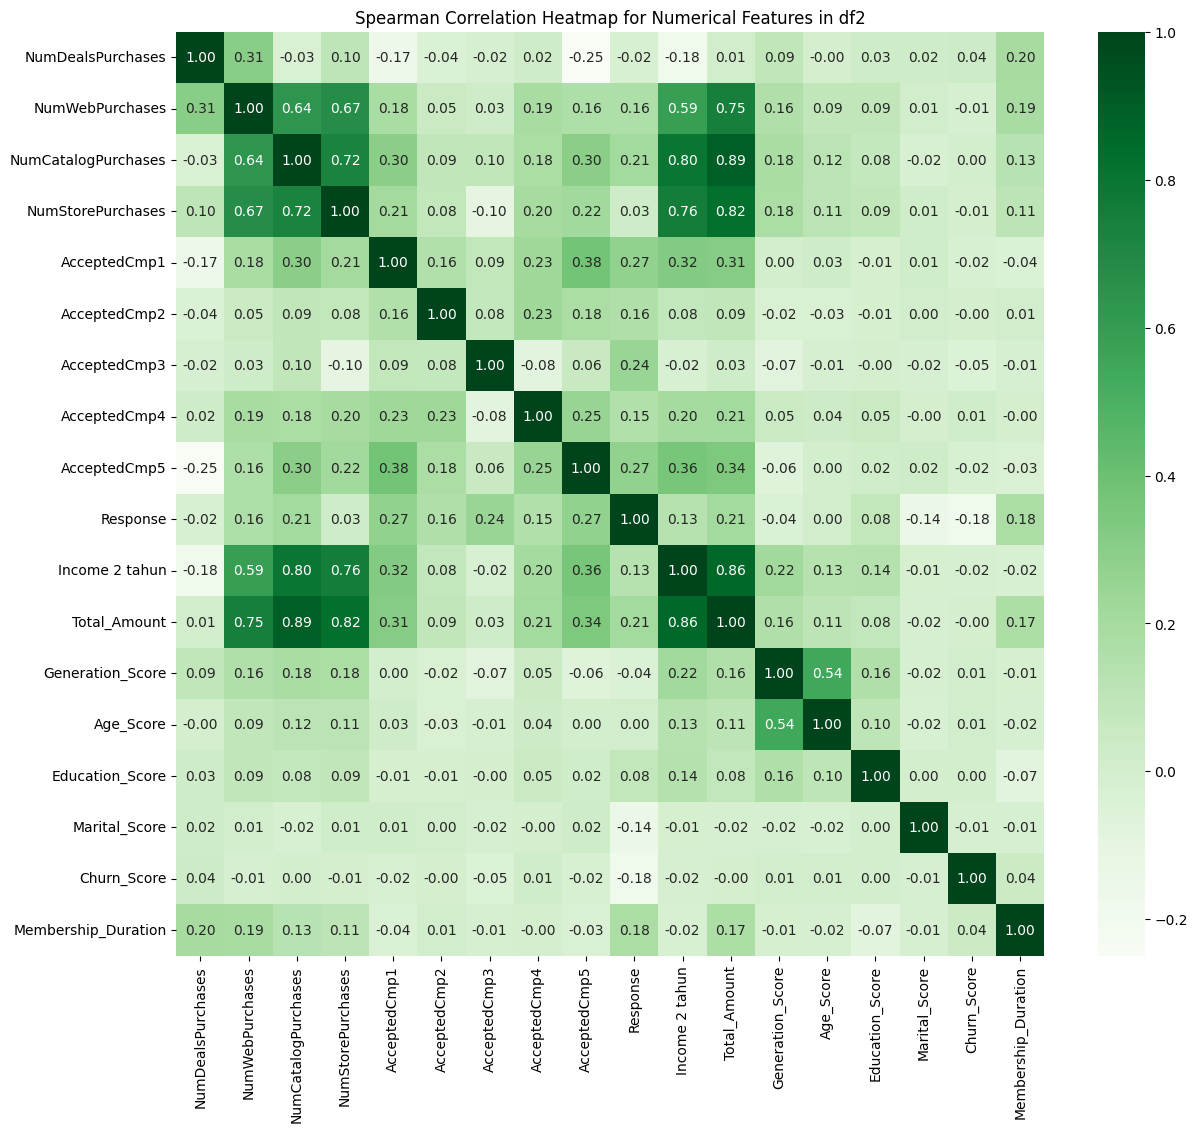

In [372]:
# Hitung korelasi Spearman untuk fitur numerik di df2
corr = df2.dropna().corr(method='spearman')

# Visualisasi heatmap untuk korelasi Spearman
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, cmap='Greens', fmt=".2f")
plt.title('Spearman Correlation Heatmap for Numerical Features in df2')
plt.show()

*Hasil Correlation Matrix*

In [373]:
print("Korelasi Spearman antara fitur numerik dengan target 'Total_Amount':")

# Menampilkan Korelasi Spearman setiap fitur numerik dengan 'Total_Amount'
df2.corr(method='spearman').loc[['Total_Amount']].T.drop('Total_Amount').round(2)

Korelasi Spearman antara fitur numerik dengan target 'Total_Amount':


,Total_Amount
NumDealsPurchases,0.01
NumWebPurchases,0.75
NumCatalogPurchases,0.89
NumStorePurchases,0.82
AcceptedCmp1,0.31
AcceptedCmp2,0.09
AcceptedCmp3,0.03
AcceptedCmp4,0.21
AcceptedCmp5,0.34
Response,0.21


In [374]:
print("Korelasi Spearman antara fitur numerik dengan target 'Total_Amount':")

# Menampilkan Korelasi Spearman setiap fitur numerik dengan 'Total_Amount'
corr_Total_Amount = df2.corr(method='spearman').loc['Total_Amount'].T.drop('Total_Amount').round(2)
corr_Total_Amount

Korelasi Spearman antara fitur numerik dengan target 'Total_Amount':


NumDealsPurchases      0.01
NumWebPurchases        0.75
NumCatalogPurchases    0.89
NumStorePurchases      0.82
AcceptedCmp1           0.31
AcceptedCmp2           0.09
AcceptedCmp3           0.03
AcceptedCmp4           0.21
AcceptedCmp5           0.34
Response               0.21
Income 2 tahun         0.86
Generation_Score       0.16
Age_Score              0.11
Education_Score        0.08
Marital_Score         -0.02
Churn_Score           -0.00
Membership_Duration    0.17
Name: Total_Amount, dtype: float64

*Interpretasi hasil Correlation Matrix*

In [375]:
# Interpretasi korelasi
print("Interpretasi terhadap hasil Correlation Matrix:\n")
for feature, correlation in corr_Total_Amount.items():
    if abs(correlation) > 0.7:
        print(f"{feature}: Korelasi kuat dengan target 'Total_Amount'")
    elif abs(correlation) > 0.3:
        print(f"{feature}: Korelasi sedang dengan target 'Total_Amount'")
    elif abs(correlation) > 0.05:
        print(f"{feature}: Korelasi lemah dengan target 'Total_Amount'")
    else:
        print(f"{feature}: Korelasi sangat lemah dengan target 'Total_Amount'")

Interpretasi terhadap hasil Correlation Matrix:

NumDealsPurchases: Korelasi sangat lemah dengan target 'Total_Amount'
NumWebPurchases: Korelasi kuat dengan target 'Total_Amount'
NumCatalogPurchases: Korelasi kuat dengan target 'Total_Amount'
NumStorePurchases: Korelasi kuat dengan target 'Total_Amount'
AcceptedCmp1: Korelasi sedang dengan target 'Total_Amount'
AcceptedCmp2: Korelasi lemah dengan target 'Total_Amount'
AcceptedCmp3: Korelasi sangat lemah dengan target 'Total_Amount'
AcceptedCmp4: Korelasi lemah dengan target 'Total_Amount'
AcceptedCmp5: Korelasi sedang dengan target 'Total_Amount'
Response: Korelasi lemah dengan target 'Total_Amount'
Income 2 tahun: Korelasi kuat dengan target 'Total_Amount'
Generation_Score: Korelasi lemah dengan target 'Total_Amount'
Age_Score: Korelasi lemah dengan target 'Total_Amount'
Education_Score: Korelasi lemah dengan target 'Total_Amount'
Marital_Score: Korelasi sangat lemah dengan target 'Total_Amount'
Churn_Score: Korelasi sangat lemah deng

*Cek fitur yang memiliki korelasi lemah*

In [376]:
# Menentukan fitur dengan korelasi sangat lemah terhadap target y (|correlation| < 0.05)
if 'Total_Amount' in corr:
    low_corr_features = corr['Total_Amount'].drop('Total_Amount', errors='ignore').abs()
    features_to_drop = low_corr_features[low_corr_features < 0.05].index.tolist()

    # Menampilkan fitur yang bisa di-drop karena korelasi sangat lemah dengan target
    if features_to_drop:
        print("Fitur yang memiliki korelasi sangat lemah dengan target 'Total_Amount' (< 0.05) yaitu:\n")
        print(features_to_drop)
        print("\nPerlu di cek lebih lanjut apakah fitur di atas perlu di-drop.")
    else:
        print("Tidak ada fitur dengan korelasi sangat lemah terhadap target 'Total_Amount'. Semua fitur masih cukup relevan.")
else:
    print("Fitur 'Total_Amount' tidak ditemukan dalam dataset. Tidak bisa menghitung korelasi terhadap target.")

Fitur yang memiliki korelasi sangat lemah dengan target 'Total_Amount' (< 0.05) yaitu:

['NumDealsPurchases', 'AcceptedCmp3', 'Marital_Score', 'Churn_Score']

Perlu di cek lebih lanjut apakah fitur di atas perlu di-drop.


> **Hasil korelasi ini perlu kita cek lagi melalui Quick Evaluation Metrics (menggunakan Model Liner Regression) untuk mengetahui apakah perlu DROP fitur `NumDealsPurchases`, `AcceptedCmp3`, `Marital_Score` dan `Churn_Score`.**

### 10.2 Quick Evaluation Metrics (Tahap 1)

Quick Evaluation Metrics (Tahap 1) dilakukan menggunakan model **Multiple Linear Regression** terhadap 2 skenario, yaitu:
1. **Skenario 1 ==> Menggunakan semua features** (termasuk fitur `NumDealsPurchases`, `AcceptedCmp3`, `Marital_Score` dan `Churn_Score`).
2. **Skenario 2 ==> DROP fitur `NumDealsPurchases`, `AcceptedCmp3`, `Marital_Score` dan `Churn_Score`**. Menggunakan semua fitur yang tersisa.

#### 10.2.1 Skenario 1: Menggunakan semua fitur

In [377]:
# Independent variable
X = df2.drop(columns= 'Total_Amount')

# Dependent variable
y = df2['Total_Amount']

# Splitting Dataset ==> dengan proporsi 80:20 dan random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= .80, random_state = 42)

# Menggunakan Model Linear Regression
model1_LR = LinearRegression()
model1_LR.fit(X_train, y_train)

LinearRegression()

*Quick Evaluation Metrics*

In [378]:
## Data Training
r2_train1 = model1_LR.score(X_train, y_train)

## Data Testing
r2_test1 = model1_LR.score(X_test, y_test)

#### 10.2.2 Skenario 2: Drop fitur `NumDealsPurchases`, `AcceptedCmp3`, `Marital_Score` dan `Churn_Score` dan data disimpan dalam **Dataset df3**.

In [379]:
# Salin df2 ke df3
df3 = df2.copy()

In [380]:
# Drop kolom
df3.drop(columns = ['NumDealsPurchases', 'AcceptedCmp3', 'Marital_Score', 'Churn_Score'], inplace=True)
df3.head()

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp4,AcceptedCmp5,Response,Income 2 tahun,Total_Amount,Generation_Score,Age_Score,Education_Score,Membership_Duration
ID,,,,,,,,,,,,,,
5524,8,10,4,0,0,0,0,1,116276.0,1617,4,4,3,1361
2174,1,1,2,0,0,0,0,0,92688.0,27,4,5,3,515
4141,8,2,10,0,0,0,0,0,143226.0,776,3,4,3,862
6182,2,0,4,0,0,0,0,0,53292.0,53,2,4,3,455
5324,5,3,6,0,0,0,0,0,116586.0,422,2,4,5,711


In [381]:
# Simpan df3 ke dalam file CSV
df3.to_csv('df3.csv', index=False)

In [382]:
# Independent variable
X = df3.drop(columns= 'Total_Amount')

# Dependent variable
y = df3['Total_Amount']

# Splitting Dataset ==> dengan proporsi 80:20 dan random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= .80, random_state = 42)

# Menggunakan Model Linear Regression
model2_LR = LinearRegression()
model2_LR.fit(X_train, y_train)

LinearRegression()

*Quick Evaluation Metrics*

In [383]:
## Data Training
r2_train2 = model2_LR.score(X_train, y_train)

## Data Testing
r2_test2 = model2_LR.score(X_test, y_test)

#### 10.2.3 Perbandingan Hasil Quick Evaluation Metrics antara Skenario 1 dan Skenario 2

In [384]:
data_LR_quick = {
    "Skenario 1 Training" : [r2_train1],
    "Skenario 1 Testing" : [r2_test1],
    "Skenario 2 Training" : [r2_train2],
    "Skenario 2 Testing" : [r2_test2], 
}

pd.DataFrame(data_LR_quick, index=['R squared'])

,Skenario 1 Training,Skenario 1 Testing,Skenario 2 Training,Skenario 2 Testing
R squared,0.823565,0.789602,0.821697,0.791864


**Kesimpulan:**

1. Untuk Skenario 1 ==> nilai R squared training dan testing tidak beda jauh (hanya berbeda 3.4 poin) ==> **Hasilnya Fit dan stabil**

2. Untuk Skenario 2 ==> nilai R squared training dan testing tidak beda jauh (hanya berbeda 3.0 poin) ==> **Hasilnya sedikit lebih Fit dan lebih stabil dari Skenario 1**

3. Nilai R squared testing Skenario 2 sedikit lebih besar dari Skenario 1, meskipun tidak ada perbedaan yang signifikan (hanya berbeda 0.2 poin) ==> **Performa Skenario 2 lebih baik dari Skenario 1**

4. **Selanjutnya, kita gunakan dataset Skenario 2 (Dataset Df3) untuk cek Intercept dan Koefisien masing-masing features.**

## 11. Analisa Intercept dan Koefisien

### 11.1 Cek Intercept dan Koefisien masing-masing features (menggunakan dataset Skenario 2)

**Intercept**

In [385]:
model2_LR.intercept_

np.float64(-490.85430145976636)

**Koefisien untuk setiap features**

In [386]:
pd.DataFrame(data = model2_LR.coef_, index = X_train.columns, columns= ['Coef'])

,Coef
NumWebPurchases,20.710354
NumCatalogPurchases,77.750654
NumStorePurchases,28.256079
AcceptedCmp1,117.129914
AcceptedCmp2,-20.791408
AcceptedCmp4,14.982956
AcceptedCmp5,202.294708
Response,59.137760
Income 2 tahun,0.005171
Generation_Score,-31.646661


**Hasil cek koefisien:**

1. Fitur Income 2 tahun	(koefisien = 0.005) dan Membership_Duration (koefisien = 0.196) memiliki nilai koefisien yang sangat kecil dibandingkan dengan fitur yang lain.

2. Kita bisa drop kolom yang koefisiennya sangat kecil yaitu Income 2 tahun dan Membership_Duration ==> **Skenario 3 (DROP kolom `Income 2 tahun` dan `Membership_Duration`)**

3. Kemudian kita hitung performa Skenario 3 melalui Quick Evaluation Metrics.

### 11.2 Quick Evaluation Metrics (Tahap 2)

#### 11.2.1 Skenario 3: Drop fitur `Income 2 tahun` dan `Membership_Duration` dan data disimpan dalam **Dataset df4**.

In [387]:
# Salin df3 ke df4
df4 = df3.copy()

In [388]:
# Drop kolom
df4.drop(columns = ['Income 2 tahun', 'Membership_Duration'], inplace=True)
df4.head()

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,AcceptedCmp1,AcceptedCmp2,AcceptedCmp4,AcceptedCmp5,Response,Total_Amount,Generation_Score,Age_Score,Education_Score
ID,,,,,,,,,,,,
5524,8,10,4,0,0,0,0,1,1617,4,4,3
2174,1,1,2,0,0,0,0,0,27,4,5,3
4141,8,2,10,0,0,0,0,0,776,3,4,3
6182,2,0,4,0,0,0,0,0,53,2,4,3
5324,5,3,6,0,0,0,0,0,422,2,4,5


In [389]:
# Simpan df4 ke dalam file CSV
df4.to_csv('df4.csv', index=False)

In [390]:
# Independent variable
X = df4.drop(columns= 'Total_Amount')

# Dependent variable
y = df4['Total_Amount']

# Splitting Dataset ==> dengan proporsi 80:20 dan random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= .80, random_state = 42)

model3_LR = LinearRegression()
model3_LR.fit(X_train, y_train)

LinearRegression()

*Quick Evaluation Metrics*

In [391]:
## Data Training
r3_train3 = model3_LR.score(X_train, y_train)

## Data Testing
r3_test3 = model3_LR.score(X_test, y_test)

#### 11.2.2 Perbandingan Hasil Quick Evaluation Metrics antara Skenario 1 dan Skenario 2

In [392]:
data_LR_quick = {
    "Skenario 2 Training" : [r2_train2],
    "Skenario 2 Testing" : [r2_test2],
    "Skenario 3 Training" : [r3_train3],
    "Skenario 3 Testing" : [r3_test3], 
}

pd.DataFrame(data_LR_quick, index=['R squared'])

,Skenario 2 Training,Skenario 2 Testing,Skenario 3 Training,Skenario 3 Testing
R squared,0.821697,0.791864,0.780703,0.744588


**Kesimpulan:**
1. Untuk Skenario 3 ==> nilai R squared metrics training dan testing tidak beda jauh (hanya berbeda 3.6 poin) ==> **Hasilnya Fit dan stabil**

2. Namun, skenario 3 malah membuat nilai R squared turun signifikan (4-5 poin) ==> **Performa Skenario 2 lebih baik dari Skenario 3.**

4. **Selanjutnya, kita tetap gunakan dataset Skenario 2 (Dataset Df3) sebagai BASE MODEL.**

## 12. Cross Validation

Untuk Machine Learning modelling, kita memiliki 4 kandidat algoritma, yaitu:
1. Model Linear Regression
2. Model KNN Regressor
3. Model DecisionTree Regressor
4. Model RandomForest Regressor

Sebelum melakukan prediksi pada test dataset, **kita melakukan cross validation untuk menentukan benchmark model terbaik.**

In [393]:
# Independent variable
X = df3.drop(columns= 'Total_Amount')

# Dependent variable
y = df3['Total_Amount']

# Spllting Data dengan proporsi 80:20 dan random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= .80, random_state = 42)

In [394]:
LR = LinearRegression()
KNN = KNeighborsRegressor()
DT = DecisionTreeRegressor()
RF = RandomForestRegressor()
Model = [LR, KNN, DT, RF]

In [395]:
## Cek scoring R squared
Mean_r2 = []
Std_r2 =[]

for i in Model:
    skf = KFold(n_splits=5)
    model = i
    model_cv = cross_val_score(model, X_train, y_train, cv=skf, scoring='r2')
    Mean_r2.append(model_cv.mean())
    Std_r2.append(model_cv.std())

In [396]:
## Cek scoring MSE
Mean_MSE = []
Std_MSE =[]

for i in Model:
    skf = KFold(n_splits=5)
    model = i
    model_cv = cross_val_score(model, X_train, y_train, cv=skf, scoring='neg_mean_absolute_error')
    Mean_MSE.append(model_cv.mean())
    Std_MSE.append(model_cv.std())

**Perbandingan hasil evaluasi dari 4 kandidat algoritma yang akan digunakan:**

In [397]:
pd.DataFrame({'Model' : ['Linear Regression', 'KNN Regressor', 'DecisionTree Regressor', 'RandomForest Regressor'],
              'Mean R squared' : Mean_r2,
              'StdDev R squared' : Std_r2,
              'Mean MAE' : Mean_MSE,
              'StdDev MAE' : Std_MSE})

,Model,Mean R squared,StdDev R squared,Mean MAE,StdDev MAE
0,Linear Regression,0.813136,0.020109,-172.638437,12.406426
1,KNN Regressor,0.715882,0.018313,-212.182638,13.187531
2,DecisionTree Regressor,0.740497,0.022360,-162.537507,6.562242
3,RandomForest Regressor,0.870403,0.016083,-112.787008,10.663680


**Kesimpulan:**

DecisionTree Regressor dan RandomForest Regressor
Linear Regression dan KNN Regressor

1. Dari sisi R squared:
    - Nilai R squared:
        - R squared dari RandomForest Regressor jauh di atas model lainnya. Algoritma RandomForest Regressor lebih baik.
    - Standar Deviasi R squared:
        - Standar Deviasi R squared dari RandomForest Regressor jauh di bawah model lainnya. Data Algoritma RandomForest Regressor lebih stabil.

2. Dari sisi MAE:
    - Nilai MAE:
        - MAE RandomForest Regressor jauh lebih kecil dari model lainnya. Algoritma RandomForest Regressor lebih baik.
    - Standar Deviasi MAE:
        - Standar Deviasi MAE dari DecisionTree Regressor dan RandomForest Regressor lebih kecil dari Linear Regression dan KNN Regressor. Namun, standar Deviasi MAE dari RandomForest Regressor lebih tinggi dari DecisionTree (selisih 5.8).
        - Data Algoritma DecisionTree Regressor dan RandomForest Regressor sama-sama lebih stabil.

3. Dari kedua fakta di atas, Algoritma RandomForest Regressor lebih baik dari Algoritma Linear Regression, KNN Regressor dan DecisionTree Regressor.

4. **Selanjutnya, kita gunakan model RandomForest Regressor sebagai benchmark model untuk prediksi testing data**

## 13. Machine Learning menggunakan Benchmark Model

In [398]:
# Independent variable
X = df3.drop(columns= 'Total_Amount')

# Dependent variable
y = df3['Total_Amount']

# Spllting Data dengan proporsi 80:20 dan random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= .80, random_state = 42)

### 13.1 Random Forest Regressor

In [399]:
model_RF = RandomForestRegressor()
model_RF.fit(X_train, y_train)

RandomForestRegressor()

*Evaluation Metrics Data Testing*

In [400]:
pred_test_RF = model_RF.predict(X_test)

## R squared
RF_r2_test = r2_score(y_test, pred_test_RF)

## MAE 
RF_MAE_test = mean_absolute_error(y_test, pred_test_RF)

## MSE
RF_MSE_test = mean_squared_error(y_test, pred_test_RF)

## RMSE
RF_RMSE_test = np.sqrt(RF_MSE_test)

In [401]:
data_DT_RF = {
    "RandomForest Regressor Testing" : [RF_r2_test, RF_MAE_test, RF_MSE_test, RF_RMSE_test]
}

pd.DataFrame(data_DT_RF, index=['R squared', 'MAE', 'MSE', 'RMSE']).T

,R squared,MAE,MSE,RMSE
RandomForest Regressor Testing,0.867921,109.355025,45490.388534,213.284759


## 14. Improvement Machine Learning

### 14.1 Tuning Menggunakan GridSearchCV atau RandomizedSearchCV (untuk memilih parameter terbaik)

In [402]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Variasi parameter yang ingin diuji
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10]
}

rf = RandomForestRegressor(random_state=42) # Inisialisasi model dasar Random Forest

# Perbaikan: Memanggil fungsi RandomizedSearchCV dan menambahkan n_iter
rf_random = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=15,            # Untuk menghemat waktu, Python hanya akan memilih 15 kombinasi acak yang ingin dicoba 
    cv=5,                 # Menggunakan 5-Fold Cross Validation
    scoring='neg_mean_absolute_error',         # Fokus optimasi pada MAE
    random_state=42,      # Diperlukan untuk mengunci keacakan n_iter
    n_jobs=-1             # Menggunakan semua core prosesor agar lebih cepat
)

rf_random.fit(X_train, y_train)
print("Parameter Terbaik:", rf_random.best_params_) # Parameter terbaik
print("Skor MAE Terbaik:", -rf_random.best_score_) # Skor MAE terbaik yang berhasil dicapai selama CV

Parameter Terbaik: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Skor MAE Terbaik: 113.74030828671559


### 14.2 Evaluation Metrics menggunakan parameter terbaik

In [403]:
model_RFT = RandomForestRegressor(n_estimators = 300, min_samples_split = 2, min_samples_leaf = 2, max_depth = None, random_state=42)
model_RFT.fit(X_train, y_train)

pred_test_RFT = model_RFT.predict(X_test)
RFT_r2_test = r2_score(y_test, pred_test_RFT)
RFT_MAE_test = mean_absolute_error(y_test, pred_test_RFT)
RFT_MSE_test = mean_squared_error(y_test, pred_test_RFT)
RFT_RMSE_test = np.sqrt(RF_MSE_test)

### 14.3 Perbandingan Evaluation Metrics (sebelum Tuning dan setelah Tuning)

In [404]:
data = {
    "RandomForest Regressor Testing" : [RF_r2_test, RF_MAE_test, RF_MSE_test, RF_RMSE_test],
    "Tuning RandomForest Regressor Testing" : [RFT_r2_test, RFT_MAE_test, RFT_MSE_test, RFT_RMSE_test]
}

pd.DataFrame(data, index=['R squared', 'MAE', 'MSE', 'RMSE']).T

,R squared,MAE,MSE,RMSE
RandomForest Regressor Testing,0.867921,109.355025,45490.388534,213.284759
Tuning RandomForest Regressor Testing,0.867662,110.198016,45579.704465,213.284759


**Hasil Perbandingan:**

1. Performa Random Forest Regressor sebelum Tuning relatif sama dengan setelah Tuning (menggunakan parameter terbaik).

2. **Selanjutnya, untuk conclusion, kita gunakan Algoritma Tuning Random Forest Regressor sebagai algoritma terbaik di Project ini.** 

In [405]:
data = {
    "Tuning RandomForest Regressor Testing" : [RFT_r2_test, RFT_MAE_test, RFT_MSE_test, RFT_RMSE_test]
}

pd.DataFrame(data, index=['R squared', 'MAE', 'MSE', 'RMSE']).T

,R squared,MAE,MSE,RMSE
Tuning RandomForest Regressor Testing,0.867662,110.198016,45579.704465,213.284759


## 15. Implementasi Model Terbaik (Tuning Random Forest Regressor) Terhadap Prediksi Total Transaksi Pelanggan 

#### 15.1 Hasil prediksi Total Transaksi pelanggan (menggunakan model Tuning RandomForest Regressor)

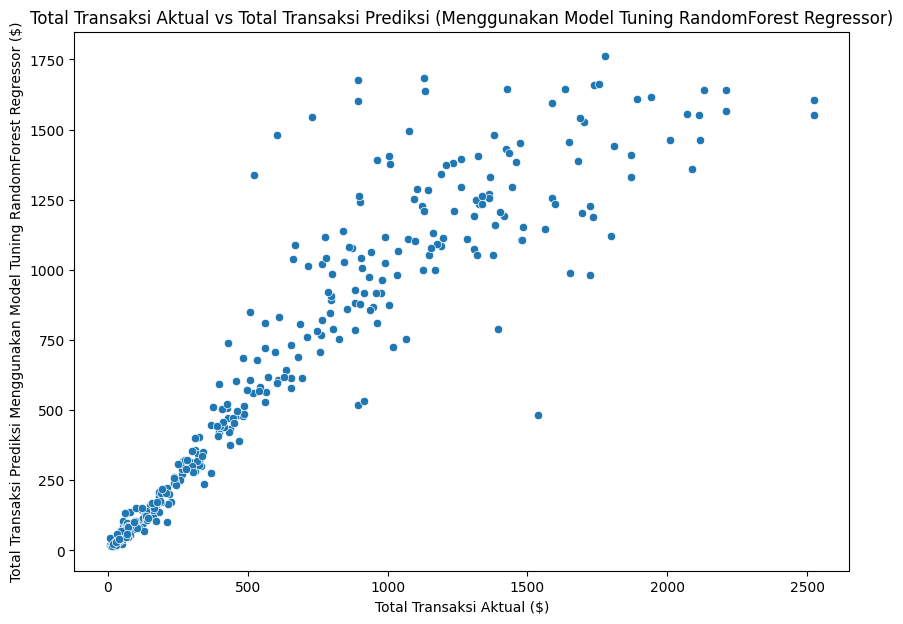

In [406]:
plt.figure(figsize=(10, 7))
plot = sns.scatterplot(x=y_test, y=pred_test_RFT).set(title='Total Transaksi Aktual vs Total Transaksi Prediksi (Menggunakan Model Tuning RandomForest Regressor)', 
                                               xlabel='Total Transaksi Aktual ($)', 
                                               ylabel='Total Transaksi Prediksi Menggunakan Model Tuning RandomForest Regressor ($)');

#### 15.2 Hasil evaluasi terhadap model

In [407]:
print(f"Nilai tengah total transaksi aktual pelanggan = ${round(df3['Total_Amount'].median(), 2)}")
print(f"Nilai error (MSE) = ${round((RFT_MAE_test), 2)}")
print(f"Persentase error terhadap nilai tengah total transaksi aktual pelanggan = {round((100 * RFT_MAE_test / df3['Total_Amount'].median()), 2)}%")

Nilai tengah total transaksi aktual pelanggan = $369.0
Nilai error (MSE) = $110.2
Persentase error terhadap nilai tengah total transaksi aktual pelanggan = 29.86%


- Berdasarkan R squared – Nilai 0.87 sangat bagus. **Fitur di dataset mampu menjelaskan sekitar 87% variasi dari total transaksi pelanggan.** Hanya sekitar 13% faktor lain yang belum terbaca oleh model. **Perlu tambahan fitur baru yang relevan untuk meningkatkan akurasi model.**

- Berdasarkan MAE – Rata-rata prediksi model meleset sekitar $110 per orang. Jika dibandingkan dengan nilai tengah total transaksi aktual ($369), **rata-rata meleset sekitar 30%. Ini error yang besar** seperti tergambar dalam plot di atas. 

- Berdasarkan RMSE – RMSE hampir 2x lipat MAE. Selisihnya terlalu jauh (sekitar $100). Artinya, model bisa salah prediksi sampai sekitar $212 (error ekstrem). Ini menandakan variasi kesalahan model tidak stabil seperti tergambar dalam plot di atas. **Model relatif tidak konsisten dan bisa melakukan kesalahan prediksi yang luar biasa fatal** karena nilai ektrem errornya tidak terkontrol.

#### 15.3 Kapan model bisa dipakai?

- Secara umum, sebuah model siap digunakan ketika metrik kesalahan (error) tersebut dinilai relatif kecil terhadap nilai total transaksi aktual pelanggan.

- Untuk total transaksi pelanggan > $1,500, error sebesar $110 s/d $212 tergolong kecil (< 7%-15%). Namun, jika total transaksi < $1,500, error ini terlalu besar. Artinya **model hanya bisa dipakai untuk total transaksi > $1,500. Model belum sepenuhnya siap untuk transaksi < $1,500 sehingga perlu dioptimalkan lagi**.

- Kondisi Tambahan: Pola belanja pelanggan dalam kondisi stabil. Tidak terjadi perubahan tren belanja yang ekstrem, seperti inflasi tinggi atau pandemi.

#### 15.4 Manfaat Penggunaan Model bagi Supermarket

1. **Data-driven Strategy** - Ketika model ini diimplementasikan, supermarket dapat beralih dari strategi bisnis yang bersifat tebakan (instinct-driven) menjadi berbasis data (data-driven).

2. **Personalized promotion** - Ketika model memprediksi seorang pelanggan memiliki potensi transaksi yang tinggi, tetapi belakangan ini total transaksinya menurun, sistem bisa otomatis mengirimkan voucher atau promo khusus yang dipersonalisasi untuk menarik mereka kembali. Model bisa meningkatkan efisiensi biaya pemasaran karena promo hanya dikirimkan kepada target yang tepat.

3. **Optimalisasi Supply Chain** - Prediksi total transaksi gabungan seluruh pelanggan membantu manajemen mengetahui berapa perkiraan perputaran uang dan volume barang yang akan terjual pada periode berikutnya. Hal ini mengurangi risiko penumpukan barang di gudang (overstock) yang bisa kedaluwarsa, sekaligus mencegah kelangkaan barang di rak (stockout) saat permintaan tinggi.

4. **Perencanaan Target Penjualan** - Manajemen bisa proyeksi pendapatan bulanan atau kuartal dengan tingkat akurasi mendekati 87% (berdasarkan R squared). Penentuan target penjualan menjadi lebih realistis dan membantu alokasi anggaran operasional (seperti penambahan staf kasir pada jam/hari yang diprediksi padat transaksi).

## 16. Feature Importances

Untuk model Tuning RandomForest Regressor, mari kita lihat fitur apa saja yang paling penting dan sangat mempengaruhi target (total transaksi):

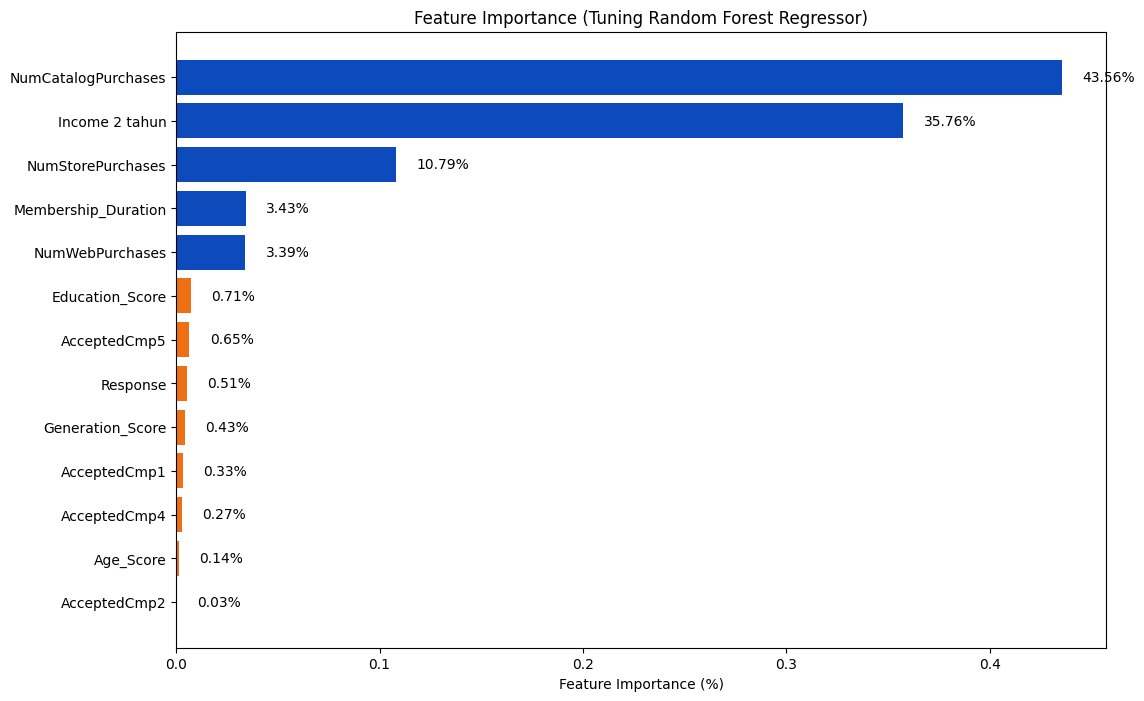

In [408]:
# Plot Feature Importance
importances = model_RFT.feature_importances_
indices = importances.argsort()[::-1]

# Semua fitur diurutkan berdasarkan pentingnya
features = X.columns[indices]
importances_sorted = importances[indices]

# Menentukan warna untuk top 5 dan sisanya
colors = ['#0D4ABC' if i < 5 else '#ED7014' for i in range(len(features))]

# Membuat plot dengan menambahkan angka persentase
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(features)), importances_sorted, align='center', color=colors)

# Menambahkan angka persentase di samping bar
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, 
             f'{importances_sorted[i]*100:.2f}%', va='center')

# Menambahkan label dan title
plt.yticks(range(len(features)), features)
plt.title('Feature Importance (Tuning Random Forest Regressor)')
plt.xlabel('Feature Importance (%)')

# Membalik urutan batang agar yang lebih besar di atas
plt.gca().invert_yaxis()

plt.show()

# Lepaskan semua variabel
del X, y, X_train, X_test, y_train, y_test, model_RFT, importances, indices, features, importances_sorted, colors

💡 **Insight:**

`NumCatalogPurchases` adalah fitur yang paling penting, kemudian diikuti dengan `income 2 tahun`, `NumStorePurchases`, `Membership_Duration` dan `NumWebPurchases`. Berdasarkan Rule of Thumb 90-95%, Persentase kumulatif dari keempat fitur ini sudah berkontribusi terhadap 95% dari total importance. Sedangkan fitur lainnya memiliki persentase yang sangat rendah (masing-masing < 0.8%).

## 17. Kesimpulan Machine Learning dan Rekomendasi

### 17.1 Kesimpulan

1. Metrik evaluasi yang digunakan pada pemilihan model adalah nilai R squared, MAE, MSE dan RMSE.

2. Model terbaik adalah Tuning RandomForest Regressor.

3. Berdasarkan model ini, fitur yang paling penting dan sangat mempengaruhi target (price) yaitu `NumCatalogPurchases`, `income 2 tahun`, `NumStorePurchases`, `Membership_Duration` dan `NumWebPurchases`.

4. Model hanya bisa dipakai untuk total transaksi pelanggan > $1,500. Model belum sepenuhnya siap untuk transaksi < $1,500 sehingga perlu dioptimalkan lagi.

5. Jika model digunakan untuk prediksi total transaksi pelanggan pada rentang nilai seperti yang dilatih terhadap model, maka total transaksi bisa meleset sekitar $110 s/d $212 per orangnya.
 
6. Model membantu supermarket beralih dari strategi bisnis yang bersifat tebakan (instinct-driven) menjadi berbasis data (data-driven).

7. Model bisa membantu supermarket dalam personalized promotion, optimalisasi supply chain dan perencanaan target penjualan.

8. **Jika supermarket melakukan personalized promotion kepada most valuable customers (mulai dari pelanggan yang memiiki spending/income rate > median terlebih dahulu) serta menerapkan model Tuning RandomForest Regressor, maka churn rate bisa menurun dan laba supermarket bisa meningkat.**

### 17.2 Rekomendasi

1. **Model Improvement** – Dataset dan model algoritma bisa dikembangkan (khususnya untuk total transaksi pelanggan < $1,500) dengan cara sebagai berikut:
    - Test Alternative Models – Scaler (Standard, Robust), Regularization (Ridge, Lasso, ElasticNet), Polynomial Features dan hyperparameter tuning.
    - Add New Data & Re-training Data – Perbanyak data baru yang bukan duplikat. Kemudian lakukan training data secara rutin untuk meningkatkan akurasi model terhadap data terbaru.

2. **Add New Features**:
    - Waktu tempuh dari tempat tinggal menuju supermarket, 
    - Metode pembayaran (tunai, kartu kredit, cicilan/paylater)